# Scaling Down Simplicity — Reproducible Experimental Pipeline (V2)

**Evaluating Lightweight Language Models for Sentence Simplification**

Models: Gemma-3 1B | Qwen3 1.7B | DeepSeek-R1-Distill-Qwen 1.5B
Datasets: ASSET (general) | Med-EASi (biomedical)
Metrics: SARI | BERTScore (raw + baseline-rescaled) | FKGL

---

### What changed in V2 (and why)

This notebook is a corrected, audit-ready rebuild of the V1 pipeline. Every change below
answers a specific defensibility problem found in the V1 audit.

| # | V1 problem | V2 fix |
|---|-----------|--------|
| 1 | `_resolve_valid_eos_token()` was called but never defined → `NameError` on a clean run | Defined explicitly in Section 04, with per-model EOS candidates |
| 2 | Training cells commented out; execution order non-linear; runtime restarted mid-notebook | Single linear pipeline; `Restart → Run all` regenerates every number |
| 3 | Output paths split between local `outputs/` and Drive → verification reported `[MISSING]` | One path root (`BASE_OUTPUT`); no hardcoded paths anywhere |
| 4 | `inference_stats.json` written under one name, read under another | Single filename constant |
| 5 | No baseline measured by us — all baselines copied from Qiang et al. | **Zero-shot baselines for all 3 models measured with the identical pipeline** |
| 6 | BERTScore computed raw, compared against rescaled literature values | BERTScore reported **raw and baseline-rescaled**, multi-reference; literature values explicitly labelled *reported, not re-run* |
| 7 | BERTScore used 1 reference while SARI used 10 | Both use the full reference set (multi-reference BERTScore); single-ref kept as a legacy column |
| 8 | No trivial baseline | **Identity (copy-source)** and **leave-one-out gold** baselines added |
| 9 | Qualitative "conservative" selection sorted ascending → picked the *most divergent* outputs | Sorting fixed; three honest categories (success / conservative / high-divergence) |
| 10 | Qualitative used Qwen3, commented as "best model" — it is not | Best model selected **programmatically** from measured SARI |
| 11 | Med-EASi size hardcoded as 1,596; actual split is 1,397 | All sizes derived from `len()`; nothing hardcoded |
| 12 | `experiment_config.json` recorded the wrong dataset ID (`Ashishkr/med_easi`) | Recorded from the actual loaded ID |
| 13 | `train_on_responses_only: True` hardcoded, but the HF fallback silently lost masking | Loss masking computed explicitly by us and **verified by decoding**; the applied state is recorded, not assumed |
| 14 | Qwen3 thinking mode uncontrolled (reasoning tokens consumed the 256-token budget) | Thinking mode disabled explicitly and **identically in training and inference** |
| 15 | Parameter percentages used hardcoded approximations | Real parameter counts, 4-bit aware (reads `quant_state`) |
| 16 | Training time included model loading; throughput and latency used different definitions | Load / train / generate timed separately; GPU-synchronised; warm-up excluded |
| 17 | No variance estimate — single seed, no CIs | Bootstrap 95% CIs + paired bootstrap tests (fine-tuned vs zero-shot) |
| 18 | "conservative editing" claimed from anecdotes | Copy rate, token retention and divergence rate measured on every system |
| 19 | GPT-4o plotted at an invented parameter count | Removed; shown as a reference line labelled *size undisclosed* |

**Runtime:** full run ≈ 7–9 h on a T4 (training ≈ 2.5 h, zero-shot inference ≈ 2.5 h,
fine-tuned inference ≈ 2.5 h, evaluation ≈ 0.5 h). Set `SMOKE_TEST = True` in Section 01
to validate the whole pipeline end-to-end in ~10 minutes before committing to a full run.

## Section 00 — Installation

Run once per fresh runtime. No kernel restart is required afterwards.

In [1]:
# ============================================================
# SECTION 00 - INSTALLATION
# ============================================================
!pip install -q unsloth 2>/dev/null || echo "Unsloth unavailable - the HF PEFT path will be used instead."
!pip install -q "transformers>=4.45.0" "datasets>=2.18.0" "peft>=0.12.0" \
                "bitsandbytes>=0.43.0" "accelerate>=0.27.0" sentencepiece protobuf
!pip install -q "evaluate>=0.4.0" "bert-score>=0.3.13" "textstat>=0.7.3" sacrebleu sacremoses
!pip install -q pandas numpy matplotlib

print("Installation step finished.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 

## Section 01 — Imports, reproducibility, configuration, paths

Everything the rest of the notebook depends on is defined here. There are no hidden
functions and no state carried over from a previous session.

In [2]:
# ============================================================
# SECTION 01a - IMPORTS
# ============================================================
import os
import gc
import glob
import json
import time
import random
import inspect
import hashlib
import platform
import shutil
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

from datasets import load_dataset, Dataset

import transformers
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)

import peft
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

import evaluate as hf_evaluate
import textstat
import bert_score

# --- Unsloth detection (optional fast path) ---
try:
    from unsloth import FastLanguageModel
    UNSLOTH_AVAILABLE = True
    print("Unsloth detected - using the Unsloth loading path.")
except Exception as _e:
    FastLanguageModel = None
    UNSLOTH_AVAILABLE = False
    print(f"Unsloth not available ({type(_e).__name__}) - using the HF PEFT loading path.")

# --- Colab detection ---
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print(f"In Colab      : {IN_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth detected - using the Unsloth loading path.
In Colab      : True
CUDA available: True
GPU           : Tesla T4


In [3]:
# ============================================================
# SECTION 01b - REPRODUCIBILITY
# ============================================================
SEED = 42


def set_all_seeds(seed: int = SEED) -> None:
    """Reset every RNG this pipeline touches.

    Called once here and again before each training run and each inference run, so that
    a given stage produces the same result regardless of what ran before it.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)

# Generation is greedy (do_sample=False) everywhere, so decoding is deterministic
# independently of the RNG state. Seeds matter for training and for bootstrap resampling.
BOOTSTRAP_SEED = 1234

print(f"Seeds set to {SEED}.")

Seeds set to 42.


In [4]:
# ============================================================
# SECTION 01c - RUN FLAGS
# ============================================================
# SMOKE_TEST: exercise every cell end-to-end on a tiny subset (~10 min) to prove the
# notebook runs top-to-bottom before spending ~8 GPU-hours on the real run.
# The real results REQUIRE SMOKE_TEST = False.
SMOKE_TEST = False

# Reuse artefacts already on disk instead of recomputing them. Set to False to force
# a complete regeneration.
REUSE_EXISTING_ADAPTERS = True
REUSE_EXISTING_PREDICTIONS = True

# --- Session hygiene --------------------------------------------------------------
# Unsloth patches modules and flips VRAM-saving switches at GLOBAL scope, and those
# globals are not reset when a model is freed. Training several different model families
# in one process therefore gets progressively less trustworthy, and the damage is
# precision-shaped: gradient offloading pulls a CPU autocast (bfloat16 by default) into
# the gradient-checkpoint recompute, while the model itself is float16, and Unsloth's
# fused LoRA kernel dies in the BACKWARD pass with:
#
#     RuntimeError: self and mat2 must have the same dtype, but got Half and BFloat16
#
# This is not hypothetical and it is not random: the first three training runs of a
# session succeed and the fourth fails, every time.
#
# Training one model family per session removes the interaction entirely. Finished
# adapters are detected and skipped, so restarting costs seconds, and the runs that were
# put off are listed explicitly at the end of Section 06b.
#
# Set to False only if you have a reason to believe the Unsloth version in use no longer
# leaks state between models - and then watch the fourth run.
ONE_MODEL_PER_SESSION = True

# Evaluate the zero-shot baselines. This is what makes the comparison in the paper
# self-contained; leave it on.
RUN_ZEROSHOT_BASELINE = True

if SMOKE_TEST:
    TRAIN_SUBSET = 32        # training examples per run
    MAX_TRAIN_STEPS = 2      # optimiser steps per run
    MAX_EVAL_SAMPLES = 8     # test sentences per system
    BOOTSTRAP_N = 50
else:
    TRAIN_SUBSET = None      # None = use the full split
    MAX_TRAIN_STEPS = -1     # -1 = train for NUM_EPOCHS
    MAX_EVAL_SAMPLES = None  # None = use the full test split
    BOOTSTRAP_N = 1000

print(f"SMOKE_TEST = {SMOKE_TEST}")
if SMOKE_TEST:
    print("  !! Numbers produced in this mode are NOT publishable - they only prove the pipeline runs.")

SMOKE_TEST = False


In [5]:
# ============================================================
# SECTION 01d - OUTPUT PATHS (single source of truth)
# ============================================================
# Every artefact in this notebook is written under BASE_OUTPUT. No cell below hardcodes
# a path; the verification section in Section 17 checks exactly these directories.

USE_DRIVE = True   # set False to keep everything on the local filesystem

BASE_OUTPUT = None
if IN_COLAB and USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_OUTPUT = "/content/drive/MyDrive/sentence_simplification_fix_final"
    except Exception as e:
        print(f"Drive mount failed ({e}); falling back to local storage.")

if BASE_OUTPUT is None:
    BASE_OUTPUT = os.path.abspath("outputs_v2")

MODELS_DIR = os.path.join(BASE_OUTPUT, "models")
PRED_DIR   = os.path.join(BASE_OUTPUT, "predictions")
METRIC_DIR = os.path.join(BASE_OUTPUT, "metrics")
FIG_DIR    = os.path.join(BASE_OUTPUT, "figures")
CONFIG_DIR = os.path.join(BASE_OUTPUT, "configs")
TABLE_DIR  = os.path.join(BASE_OUTPUT, "tables")

ALL_DIRS = OrderedDict([
    ("models", MODELS_DIR),
    ("predictions", PRED_DIR),
    ("metrics", METRIC_DIR),
    ("figures", FIG_DIR),
    ("configs", CONFIG_DIR),
    ("tables", TABLE_DIR),
])

for _d in ALL_DIRS.values():
    os.makedirs(_d, exist_ok=True)

# Filename constants - written and read through the same name everywhere.
F_ENVIRONMENT     = os.path.join(CONFIG_DIR, "environment.json")
F_EXPERIMENT_CFG  = os.path.join(CONFIG_DIR, "experiment_config.json")
F_TRAINING_CFG    = os.path.join(CONFIG_DIR, "training_config.json")
F_DATASET_STATS   = os.path.join(CONFIG_DIR, "dataset_stats.json")
F_TRAIN_STATS     = os.path.join(CONFIG_DIR, "training_stats.json")
F_INFER_STATS     = os.path.join(CONFIG_DIR, "inference_stats.json")
F_REQUIREMENTS    = os.path.join(BASE_OUTPUT, "requirements.txt")

# Work-in-progress inference lives here until a system finishes, then it is deleted.
PARTIAL_DIR = os.path.join(PRED_DIR, "_partial")
os.makedirs(PARTIAL_DIR, exist_ok=True)


# --- Atomic writes ----------------------------------------------------------------
# Google Drive is a network filesystem and Colab sessions are killed without warning.
# A plain to_csv() of a 359-row prediction file can be caught mid-flush, and the next
# session reads the truncated result back as if it were complete. Writing to a temporary
# file in the SAME directory and then moving it into place makes every artefact
# all-or-nothing: os.replace is atomic within a filesystem, so a reader sees either the
# previous version or the new one, never a partial one.

def _atomic(path, write_fn):
    tmp = f"{path}.tmp-{os.getpid()}"
    try:
        write_fn(tmp)
        os.replace(tmp, path)
    except BaseException:
        if os.path.exists(tmp):
            try:
                os.remove(tmp)
            except OSError:
                pass
        raise
    return path


def save_json(obj, path):
    def _w(tmp):
        with open(tmp, "w", encoding="utf-8") as f:
            json.dump(obj, f, indent=2, default=str)
    return _atomic(path, _w)


def save_csv(df, path, **kw):
    kw.setdefault("index", False)
    return _atomic(path, lambda tmp: df.to_csv(tmp, **kw))


def save_text(text, path):
    def _w(tmp):
        with open(tmp, "w", encoding="utf-8") as f:
            f.write(text)
    return _atomic(path, _w)


def load_json(path, default=None):
    """Read a JSON artefact, treating a damaged one as absent rather than fatal."""
    if not os.path.exists(path):
        return default
    try:
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"  !! {os.path.basename(path)} is unreadable ({e}); treating it as missing.")
        return default


print("Output root:", BASE_OUTPUT)
for k, v in ALL_DIRS.items():
    print(f"  {k:12s} -> {v}")
print(f"  {'partials':12s} -> {PARTIAL_DIR}")

Mounted at /content/drive
Output root: /content/drive/MyDrive/sentence_simplification_fix_final
  models       -> /content/drive/MyDrive/sentence_simplification_fix_final/models
  predictions  -> /content/drive/MyDrive/sentence_simplification_fix_final/predictions
  metrics      -> /content/drive/MyDrive/sentence_simplification_fix_final/metrics
  figures      -> /content/drive/MyDrive/sentence_simplification_fix_final/figures
  configs      -> /content/drive/MyDrive/sentence_simplification_fix_final/configs
  tables       -> /content/drive/MyDrive/sentence_simplification_fix_final/tables
  partials     -> /content/drive/MyDrive/sentence_simplification_fix_final/predictions/_partial


In [6]:
# ============================================================
# SECTION 01e - ENVIRONMENT CAPTURE
# ============================================================
# Recorded so that the exact software stack behind every number is auditable.

def _ver(mod):
    return getattr(mod, "__version__", "unknown")


ENVIRONMENT = {
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": _ver(torch),
    "cuda": torch.version.cuda if torch.cuda.is_available() else None,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "gpu_total_memory_gb": (
        round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
        if torch.cuda.is_available() else None
    ),
    "bf16_supported": bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported()),
    "transformers": _ver(transformers),
    "peft": _ver(peft),
    "datasets": _ver(__import__("datasets")),
    "evaluate": _ver(hf_evaluate),
    "bert_score": _ver(bert_score),
    "textstat": _ver(textstat),
    "matplotlib": _ver(matplotlib),
    "numpy": _ver(np),
    "pandas": _ver(pd),
    "unsloth_available": UNSLOTH_AVAILABLE,
    "unsloth": _ver(__import__("unsloth")) if UNSLOTH_AVAILABLE else None,
    "in_colab": IN_COLAB,
    "smoke_test": SMOKE_TEST,
}

save_json(ENVIRONMENT, F_ENVIRONMENT)

print(json.dumps(ENVIRONMENT, indent=2))

{
  "timestamp_utc": "2026-08-30T09:59:16Z",
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "torch": "2.11.0+cu128",
  "cuda": "12.8",
  "gpu": "Tesla T4",
  "gpu_total_memory_gb": 15.64,
  "bf16_supported": false,
  "transformers": "5.5.0",
  "peft": "0.20.0",
  "datasets": "4.3.0",
  "evaluate": "0.4.6",
  "bert_score": "0.3.12",
  "textstat": [
    0,
    7,
    13
  ],
  "matplotlib": "3.10.0",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "unsloth_available": true,
  "unsloth": "2026.8.22",
  "in_colab": true,
  "smoke_test": false
}


In [7]:
# ============================================================
# SECTION 01f - EXPERIMENT CONSTANTS
# ============================================================

# --- LoRA / optimisation (reported verbatim in the paper) ---
LORA_R         = 16
LORA_ALPHA     = 32         # alpha/r = 2, the usual scaling
LORA_DROPOUT   = 0.0
MAX_SEQ_LEN    = 512
BATCH_SIZE     = 2
GRAD_ACCUM     = 4          # effective batch = 8

# Learning rate: 2e-4, the standard QLoRA setting for adapters of this size.
#
# The first version of this notebook used 2e-5, which is a FULL fine-tuning rate. LoRA
# does not update the pretrained weights at all; it trains a small set of newly
# initialised parameters whose B matrix starts at exactly zero, so the adapter has to
# travel much further from its initialisation to have any effect. At 2e-5 it barely
# moved: fine-tuned output was indistinguishable from zero-shot on all three models, and
# for Gemma-3 it was identical token for token.
#
# 2e-4 with linear decay and a short warm-up is the value the QLoRA paper uses for models
# in this range and the default in Unsloth's own examples, which is what makes it
# defensible to state in the paper without a tuning study this work does not have.
#
# The risk of a higher rate is divergence rather than stagnation, so the loss curve is
# recorded per run (Section 06a) and a run whose loss fails to fall is reported as a
# finding in Section 17b instead of being quietly written into a table.
NUM_EPOCHS     = 2
LR             = 2e-4
WARMUP_RATIO   = 0.03
OPTIMIZER      = "adamw_8bit"
LR_SCHEDULER   = "linear"

# --- Inference (unchanged from V1) ---
MAX_NEW_TOKENS     = 256
REPETITION_PENALTY = 1.1
DO_SAMPLE          = False   # greedy -> deterministic

# --- Crash recovery ---------------------------------------------------------------
# None of these touches what is computed; they decide only how often it is written down.
# A dropped Colab session then costs minutes, not hours.
CHECKPOINT_SAVE_STEPS = 50   # training checkpoints (adapter only - tens of MB, not GB)
CHECKPOINT_KEEP       = 2    # newest N kept, so Drive does not fill up
PARTIAL_FLUSH_EVERY   = 20   # inference: sentences between partial saves

TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# Tokenisation policy. The rendered chat template already carries its own BOS, so special
# tokens are never added again - applied identically at training and at inference time.
ADD_SPECIAL_TOKENS = False

# ASSET provides 10 human references per source sentence. Fine-tuning consumes ONE target
# per source; this constant records which one, so the choice is explicit in the paper
# rather than buried in a helper function.
ASSET_TRAIN_REF_INDEX = 0
ASSET_TRAIN_REF_STRATEGY = "first_reference_per_source"

# Qwen3 is a hybrid-reasoning model. Thinking mode is disabled explicitly and applied to
# BOTH the training text and the inference prompt, so the model never sees a prompt shape
# at inference that it did not see during training.
ENABLE_THINKING = False

# --- Prompt (from the paper, adapted from Qiang et al. 2025) ---
SIMPLIFICATION_PROMPT = (
    "Please rewrite the following complex sentence in order to make it easier to understand "
    "by non-native speakers of English. You can do so by replacing complex words with simpler "
    "synonyms (i.e. paraphrasing), deleting unimportant information (i.e. compression), and/or "
    "splitting a long complex sentence into several simpler ones. The final simplified sentence "
    "needs to be grammatical, fluent, and retain the main ideas of its original counterpart "
    "without altering its meaning."
)

ALPACA_TEMPLATE = (
    "Below is an instruction that describes a task, paired with an input that provides "
    "further context. Write a response that appropriately completes the request.\n\n"
    "### Instruction:\n{instruction}\n\n"
    "### Input:\n{input}\n\n"
    "### Response:\n"
)

# --- Model configurations ---
# eos_candidates: ordered preference for the end-of-turn token appended to training
#   targets and used as a stop condition at generation time. The first candidate that
#   actually exists in the tokenizer vocabulary wins (see _resolve_valid_eos_token).
MODEL_CONFIGS = OrderedDict([
    ("gemma3", {
        "hf_model":       "google/gemma-3-1b-it",
        "unsloth_model":  "unsloth/gemma-3-1b-it-bnb-4bit",
        "template":       "chat",
        "eos_candidates": ["<end_of_turn>", "<eos>"],
        "supports_thinking_flag": False,
    }),
    ("qwen3", {
        "hf_model":       "Qwen/Qwen3-1.7B",
        "unsloth_model":  "unsloth/Qwen3-1.7B-bnb-4bit",
        "template":       "chat",
        "eos_candidates": ["<|im_end|>", "<|endoftext|>"],
        "supports_thinking_flag": True,
    }),
    ("deepseek", {
        "hf_model":       "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
        "unsloth_model":  "unsloth/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit",
        "template":       "alpaca",
        "eos_candidates": ["<｜end▁of▁sentence｜>", "<|endoftext|>"],
        "supports_thinking_flag": False,
    }),
])

MODEL_DISPLAY = {
    "gemma3":   "Gemma-3 1B",
    "qwen3":    "Qwen3 1.7B",
    "deepseek": "DeepSeek-Distill 1.5B",
}

MODEL_NAMES = list(MODEL_CONFIGS.keys())
DATASET_NAMES = ["asset", "medeasi"]

print("Experiment constants defined.")
print(f"  models          : {MODEL_NAMES}")
print(f"  datasets        : {DATASET_NAMES}")
print(f"  enable_thinking : {ENABLE_THINKING} (applied to training AND inference)")
print(f"  ASSET train ref : {ASSET_TRAIN_REF_STRATEGY} (index {ASSET_TRAIN_REF_INDEX})")

Experiment constants defined.
  models          : ['gemma3', 'qwen3', 'deepseek']
  datasets        : ['asset', 'medeasi']
  enable_thinking : False (applied to training AND inference)
  ASSET train ref : first_reference_per_source (index 0)


## Section 02 — Dataset loading

Split sizes are never written by hand. Every count used in the paper, the figures and the
saved configs is derived from `len()` on the object that was actually trained on.

In [8]:
# ============================================================
# SECTION 02 - LOAD DATASETS
# ============================================================

# --- ASSET: general-domain simplification ---
# validation split -> fine-tuning | test split -> evaluation (following Qiang et al.)
print("Loading ASSET ...")
ASSET_HF_ID = "facebook/asset"
ASSET_HF_CONFIG = "simplification"

asset_ds = load_dataset(ASSET_HF_ID, ASSET_HF_CONFIG)
asset_train = asset_ds["validation"]
asset_test = asset_ds["test"]

print(f"  train (validation split): {len(asset_train)}")
print(f"  test  (test split)      : {len(asset_test)}")
print(f"  columns                 : {asset_train.column_names}")

# --- Med-EASi: biomedical simplification ---
print("\nLoading Med-EASi ...")
MEDEASI_HF_ID = "cbasu/Med-EASi"

medeasi_ds = load_dataset(MEDEASI_HF_ID)
print(f"  available splits: {list(medeasi_ds.keys())}")

# The official train split is used as-is. V1's paper text reported 1,596 pairs, which is
# train + validation; the pipeline only ever trained on the train split. The size is now
# read from the object itself so the two can no longer disagree.
medeasi_train = medeasi_ds["train"]
medeasi_test = medeasi_ds["test"]

print(f"  train: {len(medeasi_train)}")
print(f"  test : {len(medeasi_test)}")
print(f"  columns: {medeasi_train.column_names}")

RAW_SPLITS = {
    "asset":   {"train": asset_train,   "test": asset_test},
    "medeasi": {"train": medeasi_train, "test": medeasi_test},
}

DATASET_HF_IDS = {
    "asset":   {"hf_id": ASSET_HF_ID, "config": ASSET_HF_CONFIG,
                "train_split": "validation", "test_split": "test"},
    "medeasi": {"hf_id": MEDEASI_HF_ID, "config": None,
                "train_split": "train", "test_split": "test"},
}

print("\nSample ASSET source :", asset_train[0]["original"][:110])
print("Sample Med-EASi src :", medeasi_train[0]["Expert"][:110])

Loading ASSET ...


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

simplification/validation-00000-of-00001(…): reconstructing file:   0%|          |  0.00B /  885kB            

simplification/validation-00000-of-00001(…): downloading bytes:           |  0.00B            

simplification/test-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B /  170kB            

...

test.csv:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1397 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/196 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

  available splits: ['train', 'validation', 'test']
  train: 1397
  test : 300
  columns: ['Expert', 'Simple', 'Annotation', 'sim', 'sentence_sim', 'compression', 'expert_fk_grade', 'expert_ari', 'layman_fk_grade', 'layman_ari', 'umls_expert', 'umls_layman', 'expert_terms', 'layman_terms', 'idx']

Sample ASSET source : Adjacent counties are Marin (to the south), Mendocino (to the north), Lake (northeast), Napa (to the east), an
Sample Med-EASi src : 75-90 % of the affected people have mild intellectual disability.


## Section 03 — Dataset integrity checks

Runs before any training. Checks for train/test leakage, duplicates, empty pairs, and
audits how well the Med-EASi complex/simple pairs are actually aligned — a known weakness
of that corpus that the paper should disclose rather than have a reviewer discover.

In [9]:
# ============================================================
# SECTION 03a - COLUMN DETECTION
# ============================================================

def detect_columns(dataset):
    """Return (complex_column, simple_column) for a raw HF dataset.

    ASSET   : original -> complex, simplifications -> list of 10 references
    Med-EASi: Expert   -> complex, Simple          -> single reference
    """
    cols = dataset.column_names
    complex_candidates = ["original", "src_text", "complex", "source", "Expert", "expert"]
    simple_candidates = ["simplifications", "tgt_text", "simple", "target", "Simple", "layman"]

    complex_col = next((c for c in complex_candidates if c in cols), None)
    simple_col = next((c for c in simple_candidates if c in cols), None)

    if complex_col is None or simple_col is None:
        raise ValueError(f"Could not detect complex/simple columns from: {cols}")
    return complex_col, simple_col


COLS = {}
for _ds_name in DATASET_NAMES:
    c_col, s_col = detect_columns(RAW_SPLITS[_ds_name]["train"])
    COLS[_ds_name] = {"complex": c_col, "simple": s_col}
    print(f"{_ds_name:8s}: complex='{c_col}'  simple='{s_col}'")


def get_references(row, ds_name):
    """Return the reference simplification(s) for one row, always as a list of strings."""
    val = row[COLS[ds_name]["simple"]]
    if isinstance(val, list):
        return [str(v).strip() for v in val if v is not None and str(v).strip()]
    if val is None:
        return []
    return [str(val).strip()] if str(val).strip() else []


def get_source(row, ds_name):
    return str(row[COLS[ds_name]["complex"]]).strip()

asset   : complex='original'  simple='simplifications'
medeasi : complex='Expert'  simple='Simple'


In [10]:
# ============================================================
# SECTION 03b - INTEGRITY CHECKS
# ============================================================

def _norm(s):
    return " ".join(str(s).lower().split())


def token_retention(pred, source):
    """Fraction of the source's unique word types that survive into `pred`.

    Used throughout the notebook as the operational definition of "conservative editing":
    1.0 means every source word is still present, 0.0 means none is.
    """
    src_words = set(_norm(source).split())
    pred_words = set(_norm(pred).split())
    if not src_words:
        return 0.0
    return len(src_words & pred_words) / len(src_words)


DATASET_STATS = {}

# Normalised test sources that also occur in the training split, per dataset. Consumed by
# the leakage sensitivity analysis in Section 11b.
LEAKED_TEST_SOURCES = {}

for ds_name in DATASET_NAMES:
    tr, te = RAW_SPLITS[ds_name]["train"], RAW_SPLITS[ds_name]["test"]

    train_src = [get_source(r, ds_name) for r in tr]
    test_src = [get_source(r, ds_name) for r in te]
    train_refs = [get_references(r, ds_name) for r in tr]
    test_refs = [get_references(r, ds_name) for r in te]

    train_norm = set(_norm(s) for s in train_src)
    test_norm = [_norm(s) for s in test_src]

    # Which test rows overlap, not just how many: Section 11b needs their identities to
    # recompute the metrics with them removed. Matched on the normalised source string
    # rather than a row index, so it stays correct even if Section 07b drops a row.
    leaked_idx = [i for i, s in enumerate(test_norm) if s in train_norm]
    LEAKED_TEST_SOURCES[ds_name] = set(test_norm[i] for i in leaked_idx)
    leakage = len(leaked_idx)
    n_refs = [len(r) for r in test_refs]

    # How well are the corpus's own complex/simple pairs aligned? Low retention between a
    # source and its own reference indicates paragraph-level (not sentence-level) alignment.
    ref_align = [token_retention(refs[0], src)
                 for src, refs in zip(test_src, test_refs) if refs]

    stats = {
        "hf_id": DATASET_HF_IDS[ds_name]["hf_id"],
        "hf_config": DATASET_HF_IDS[ds_name]["config"],
        "train_split": DATASET_HF_IDS[ds_name]["train_split"],
        "test_split": DATASET_HF_IDS[ds_name]["test_split"],
        "train_size": len(tr),
        "test_size": len(te),
        "references_per_test_source_min": int(min(n_refs)) if n_refs else 0,
        "references_per_test_source_max": int(max(n_refs)) if n_refs else 0,
        "train_duplicate_sources": int(len(train_src) - len(train_norm)),
        "test_duplicate_sources": int(len(test_norm) - len(set(test_norm))),
        "train_test_source_overlap": int(leakage),
        "train_test_source_overlap_indices": leaked_idx,
        "train_empty_pairs": int(sum(1 for s, r in zip(train_src, train_refs) if not s or not r)),
        "test_empty_pairs": int(sum(1 for s, r in zip(test_src, test_refs) if not s or not r)),
        "mean_source_words": round(float(np.mean([len(s.split()) for s in test_src])), 2),
        "mean_reference_words": round(
            float(np.mean([len(r[0].split()) for r in test_refs if r])), 2),
        "source_reference_token_retention_mean": round(float(np.mean(ref_align)), 4) if ref_align else None,
        "source_reference_token_retention_median": round(float(np.median(ref_align)), 4) if ref_align else None,
        "pct_test_pairs_retention_below_0.2": round(
            100.0 * float(np.mean([a < 0.2 for a in ref_align])), 2) if ref_align else None,
    }
    DATASET_STATS[ds_name] = stats

    print(f"\n=== {ds_name.upper()} ===")
    for k, v in stats.items():
        print(f"  {k:42s}: {v}")

    if stats["train_test_source_overlap"] > 0:
        print(f"  !! WARNING: {stats['train_test_source_overlap']} test sources also appear in train.")
    if stats["test_empty_pairs"] > 0:
        print(f"  !! WARNING: {stats['test_empty_pairs']} test rows have an empty source or reference.")

save_json(DATASET_STATS, F_DATASET_STATS)

print(f"\nSaved -> {F_DATASET_STATS}")
print("\nNote on Med-EASi: a low source/reference token retention confirms that many of its")
print("complex-simple pairs are aligned at paragraph rather than sentence level. This caps")
print("how much any reference-based metric (SARI, BERTScore) can mean on that corpus and is")
print("reported as a limitation in the paper.")


=== ASSET ===
  hf_id                                     : facebook/asset
  hf_config                                 : simplification
  train_split                               : validation
  test_split                                : test
  train_size                                : 2000
  test_size                                 : 359
  references_per_test_source_min            : 10
  references_per_test_source_max            : 10
  train_duplicate_sources                   : 0
  test_duplicate_sources                    : 0
  train_test_source_overlap                 : 0
  train_test_source_overlap_indices         : []
  train_empty_pairs                         : 0
  test_empty_pairs                          : 0
  mean_source_words                         : 19.72
  mean_reference_words                      : 16.54
  source_reference_token_retention_mean     : 0.635
  source_reference_token_retention_median   : 0.6429
  pct_test_pairs_retention_below_0.2        : 1.39

=== ME

## Section 04 — Prompt construction, EOS resolution, and loss masking

The prompt is built **once** and reused verbatim for training and for inference, so the
training text is exactly `prompt + target + EOS`. That has three consequences:

1. the model never meets a prompt shape at inference it did not see in training;
2. the prompt is a literal token prefix of the training example, so response-only loss
   masking is *exact* rather than approximate;
3. `_resolve_valid_eos_token` — missing in V1 — is defined here, with its choice printed
   and stored for every run.

In [11]:
# ============================================================
# SECTION 04a - EOS RESOLUTION  (the function missing in V1)
# ============================================================

def _resolve_valid_eos_token(tokenizer, cfg):
    """Pick the end-of-turn token that terminates an assistant response.

    Chat models mark the end of a turn with a token that is not necessarily the
    tokenizer's nominal `eos_token` (Gemma-3 ends a turn with `<end_of_turn>`, not
    `<eos>`). Appending the wrong token during fine-tuning teaches the model never to
    stop, which is what makes generation run to `max_new_tokens` and inflates latency.

    Returns (token_string, token_id).
    """
    vocab = tokenizer.get_vocab()
    for cand in cfg.get("eos_candidates", []):
        tid = vocab.get(cand, None)
        if tid is None:
            tid = tokenizer.convert_tokens_to_ids(cand)
        if tid is not None and tid >= 0 and tid != tokenizer.unk_token_id:
            return cand, int(tid)

    if tokenizer.eos_token is not None:
        return tokenizer.eos_token, int(tokenizer.eos_token_id)

    raise ValueError(f"No usable EOS token found. Candidates tried: {cfg.get('eos_candidates')}")


def _resolve_stop_token_ids(tokenizer, cfg):
    """Every token id that should terminate generation (passed to `generate`)."""
    ids = []
    vocab = tokenizer.get_vocab()
    for cand in cfg.get("eos_candidates", []):
        tid = vocab.get(cand, None)
        if tid is None:
            tid = tokenizer.convert_tokens_to_ids(cand)
        if tid is not None and tid >= 0 and tid != tokenizer.unk_token_id:
            ids.append(int(tid))
    if tokenizer.eos_token_id is not None:
        ids.append(int(tokenizer.eos_token_id))
    return sorted(set(ids))


def prepare_tokenizer(tokenizer, cfg):
    """Attach a valid EOS/PAD pair and right padding. Returns (eos_token, stop_ids)."""
    eos_token, eos_id = _resolve_valid_eos_token(tokenizer, cfg)
    tokenizer.eos_token = eos_token
    tokenizer.eos_token_id = eos_id

    if tokenizer.pad_token is None or tokenizer.pad_token_id is None:
        tokenizer.pad_token = eos_token
        tokenizer.pad_token_id = eos_id

    tokenizer.padding_side = "right"
    stop_ids = _resolve_stop_token_ids(tokenizer, cfg)
    return eos_token, stop_ids

In [12]:
# ============================================================
# SECTION 04b - PROMPT CONSTRUCTION (identical for training and inference)
# ============================================================

def build_prompt(tokenizer, cfg, source_sentence):
    """Render the full prompt, ending exactly where the model must start generating."""
    if cfg["template"] == "chat":
        messages = [{"role": "user",
                     "content": f"{SIMPLIFICATION_PROMPT}\n\n{source_sentence}"}]
        kwargs = dict(tokenize=False, add_generation_prompt=True)
        if cfg.get("supports_thinking_flag"):
            kwargs["enable_thinking"] = ENABLE_THINKING
        try:
            return tokenizer.apply_chat_template(messages, **kwargs)
        except TypeError:
            # Older/newer templates that do not accept enable_thinking
            kwargs.pop("enable_thinking", None)
            return tokenizer.apply_chat_template(messages, **kwargs)

    return ALPACA_TEMPLATE.format(instruction=SIMPLIFICATION_PROMPT, input=source_sentence)

In [13]:
# ============================================================
# SECTION 04c - TOKENISATION WITH EXACT RESPONSE-ONLY LOSS MASKING
# ============================================================
# V1 relied on Unsloth's train_on_responses_only on one path and on an unimported
# collator on the other (which failed silently). Here the mask is computed by us, applied
# on every path, and verified by decoding in Section 04d.

def build_masked_dataset(raw_split, ds_name, tokenizer, cfg, eos_token,
                         max_len=MAX_SEQ_LEN, subset=None):
    """Tokenise a raw split into input_ids / attention_mask / labels.

    The prompt and the response are tokenised SEPARATELY and their ids concatenated,
    rather than tokenising the joined string and trying to locate the boundary
    afterwards. Two things follow, and both matter:

      * the loss mask is exact by construction - the first len(prompt_ids) positions are
        the prompt, so no response token is ever masked and no prompt token is ever
        supervised;
      * the token sequence the model is trained on begins with exactly the ids that
        `run_inference` will feed it, with no BPE merge across the prompt/response
        boundary changing the prefix.

    `n_boundary_merge_diff` records how many examples would have tokenised differently
    had the joined string been tokenised in one pass - a diagnostic, not an error.
    """
    rows = []
    n_boundary_diff = 0
    n_truncated = 0
    n_skipped = 0

    for row in raw_split:
        if subset is not None and len(rows) >= subset:
            break

        src = get_source(row, ds_name)
        refs = get_references(row, ds_name)
        if not src or not refs:
            n_skipped += 1
            continue

        tgt = refs[ASSET_TRAIN_REF_INDEX] if (ds_name == "asset" and
                                              len(refs) > ASSET_TRAIN_REF_INDEX) else refs[0]

        prompt = build_prompt(tokenizer, cfg, src)
        response = tgt + eos_token

        p_ids = tokenizer(prompt, add_special_tokens=ADD_SPECIAL_TOKENS)["input_ids"]
        r_ids = tokenizer(response, add_special_tokens=False)["input_ids"]

        if not r_ids:
            n_skipped += 1
            continue

        joint = tokenizer(prompt + response, add_special_tokens=ADD_SPECIAL_TOKENS)["input_ids"]
        if joint != p_ids + r_ids:
            n_boundary_diff += 1

        if len(p_ids) >= max_len:
            n_skipped += 1      # the prompt alone fills the window - nothing to learn from
            continue

        input_ids = (p_ids + r_ids)[:max_len]
        if len(p_ids) + len(r_ids) > max_len:
            n_truncated += 1

        labels = [-100] * len(p_ids) + list(r_ids)
        labels = labels[:max_len]

        rows.append({
            "input_ids": input_ids,
            "attention_mask": [1] * len(input_ids),
            "labels": labels,
        })

    ds = Dataset.from_list(rows)
    report = {
        "n_examples": len(rows),
        "n_skipped": n_skipped,
        "n_truncated": n_truncated,
        "n_boundary_merge_diff": n_boundary_diff,
        "mean_tokens": round(float(np.mean([len(r["input_ids"]) for r in rows])), 1) if rows else 0.0,
        "mean_response_tokens": round(
            float(np.mean([sum(1 for l in r["labels"] if l != -100) for r in rows])), 1) if rows else 0.0,
    }
    return ds, report

In [14]:
# ============================================================
# SECTION 04d - MASKING VERIFICATION
# ============================================================

def verify_masking(dataset, tokenizer, n_show=1):
    """Decode what the loss is actually computed on. Printed for every training run."""
    ok = True
    for i in range(min(n_show, len(dataset))):
        ex = dataset[i]
        labels = ex["labels"]
        kept = [t for t in labels if t != -100]
        masked_frac = 1.0 - (len(kept) / max(len(labels), 1))
        supervised = tokenizer.decode(kept, skip_special_tokens=False)
        print(f"  masked prompt fraction : {masked_frac:.1%}")
        print(f"  supervised text        : {supervised[:220]!r}")
        if len(kept) == 0 or masked_frac <= 0.0:
            ok = False
    return ok


print("Prompt construction, EOS resolution and loss masking defined.")

Prompt construction, EOS resolution and loss masking defined.


## Section 05 — Model loading and parameter counting

Parameter counts are read from the model, including the shapes stored in the 4-bit
`quant_state`, instead of the hardcoded approximations V1 used to compute "1.0–1.3 %".

In [15]:
# ============================================================
# SECTION 05a - PARAMETER COUNTING (4-bit aware)
# ============================================================

def count_parameters(model):
    """Return (trainable, total) parameters.

    bitsandbytes packs two 4-bit weights per uint8, so `p.numel()` undercounts a quantised
    model by ~2x. The original shape is recoverable from `p.quant_state.shape`, which is
    what this uses - the V1 training_stats.json reported the packed counts.
    """
    trainable = 0
    total = 0
    for _, p in model.named_parameters():
        n = p.numel()
        qs = getattr(p, "quant_state", None)
        shape = getattr(qs, "shape", None) if qs is not None else None
        if shape is not None:
            try:
                n = int(np.prod(tuple(shape)))
            except Exception:
                pass
        total += n
        if p.requires_grad:
            trainable += p.numel()
    return int(trainable), int(total)

In [16]:
# ============================================================
# SECTION 05b - MODEL LOADERS
# ============================================================

def _bnb_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )


def load_base_model(cfg, for_training):
    """Load the 4-bit base model + tokenizer. No adapter is attached here."""
    if UNSLOTH_AVAILABLE:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=cfg["unsloth_model"],
            max_seq_length=MAX_SEQ_LEN,
            dtype=None,
            load_in_4bit=True,
        )
    else:
        tokenizer = AutoTokenizer.from_pretrained(cfg["hf_model"], trust_remote_code=True)
        model = AutoModelForCausalLM.from_pretrained(
            cfg["hf_model"],
            quantization_config=_bnb_config(),
            device_map="auto",
            trust_remote_code=True,
        )
    model.config.use_cache = not for_training
    return model, tokenizer


def attach_lora(model):
    """Attach a fresh LoRA adapter with the paper's configuration."""
    if UNSLOTH_AVAILABLE:
        return FastLanguageModel.get_peft_model(
            model,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            target_modules=TARGET_MODULES,
            lora_dropout=LORA_DROPOUT,
            bias="none",
            use_gradient_checkpointing="unsloth",
            random_state=SEED,
            max_seq_length=MAX_SEQ_LEN,
        )
    lora_cfg = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )
    return get_peft_model(model, lora_cfg)


def load_adapter_for_inference(cfg, adapter_path):
    """Load the 4-bit base model and apply a saved LoRA adapter."""
    if not os.path.isdir(adapter_path):
        raise FileNotFoundError(f"Adapter directory not found: {adapter_path}")

    if UNSLOTH_AVAILABLE:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=adapter_path,
            max_seq_length=MAX_SEQ_LEN,
            dtype=None,
            load_in_4bit=True,
        )
        if hasattr(FastLanguageModel, "for_inference"):
            FastLanguageModel.for_inference(model)
    else:
        tokenizer = AutoTokenizer.from_pretrained(adapter_path, trust_remote_code=True)
        base = AutoModelForCausalLM.from_pretrained(
            cfg["hf_model"],
            quantization_config=_bnb_config(),
            device_map="auto",
            trust_remote_code=True,
        )
        model = PeftModel.from_pretrained(base, adapter_path)

    model.config.use_cache = True   # explicit: V1 left use_cache disabled after training
    model.eval()
    return model, tokenizer


def release_gpu():
    """Actually return VRAM to the allocator.

    The previous helper took the objects as arguments and deleted them - but `del o`
    inside a function drops only that function's local name, never the caller's
    reference, so it freed nothing and the next model was loaded alongside the last one.
    Callers must now drop their own references first and then call this.

    Synchronises before emptying the cache: pending kernels keep their workspaces alive,
    so an empty_cache() issued while work is still queued frees less than it appears to.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def _filter_kwargs(fn, kwargs):
    """Drop kwargs the installed library version does not accept.

    Keeps the notebook runnable across transformers 4.x and 5.x (for example
    `tokenizer=` vs `processing_class=` on Trainer).
    """
    try:
        params = inspect.signature(fn).parameters
    except (TypeError, ValueError):
        return kwargs
    if any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
        return kwargs
    return {k: v for k, v in kwargs.items() if k in params}


print("Model loaders defined.")

Model loaders defined.


## Section 06 — Training

Six runs: 3 models × 2 datasets. Each run reports **pure** training time (the
`trainer.train()` call only) separately from model-loading and data-preparation time, so
the efficiency table no longer mixes them.

In [17]:
# ============================================================
# SECTION 06a - TRAINING FUNCTION
# ============================================================

def train_one(model_name, ds_name):
    """Fine-tune one model on one dataset and save the adapter. Returns a stats dict."""
    cfg = MODEL_CONFIGS[model_name]
    out_dir = os.path.join(MODELS_DIR, f"{model_name}_{ds_name}")
    os.makedirs(out_dir, exist_ok=True)

    print("\n" + "=" * 68)
    print(f"TRAIN  {MODEL_DISPLAY[model_name]}  |  {ds_name.upper()}")
    print(f"       -> {out_dir}")
    print("=" * 68)

    set_all_seeds(SEED)

    t_load0 = time.time()
    model, tokenizer = load_base_model(cfg, for_training=True)
    eos_token, stop_ids = prepare_tokenizer(tokenizer, cfg)
    model = attach_lora(model)
    load_time = time.time() - t_load0

    # Printed every run, because precision is the thing that goes wrong silently here.
    # Unsloth overrides the requested dtype for some models (Gemma-3 is forced to
    # float32). A float32 model under fp16 autocast is fine; it is MIXING models of
    # different precision in one process that breaks, which ONE_MODEL_PER_SESSION
    # prevents. If these two lines ever disagree across runs in one session, that is the
    # warning sign.
    _mdtype = next((p.dtype for p in model.parameters()
                    if getattr(p.dtype, "is_floating_point", None) is not False
                    and "int" not in str(p.dtype)), None)
    print(f"Precision: autocast {'bf16' if ENVIRONMENT['bf16_supported'] else 'fp16'} | "
          f"model reports {getattr(model, 'dtype', 'unknown')} | first float param "
          f"{_mdtype}")
    print(f"EOS token: {eos_token!r} (id={tokenizer.eos_token_id}) | stop ids: {stop_ids}")
    print(f"PAD token: {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")

    t_prep0 = time.time()
    train_ds, prep_report = build_masked_dataset(
        RAW_SPLITS[ds_name]["train"], ds_name, tokenizer, cfg, eos_token,
        max_len=MAX_SEQ_LEN, subset=TRAIN_SUBSET,
    )
    prep_time = time.time() - t_prep0

    print(f"Dataset : {prep_report}")
    if prep_report["n_boundary_merge_diff"] > 0:
        print(f"  (info) {prep_report['n_boundary_merge_diff']} examples tokenise differently when "
              f"the prompt and response are joined before tokenisation. Masking is unaffected: "
              f"the two are tokenised separately, so the boundary is exact.")

    print("Loss-mask verification:")
    masking_ok = verify_masking(train_ds, tokenizer)
    if not masking_ok:
        raise RuntimeError("Response-only masking verification failed - refusing to train.")

    trainable, total = count_parameters(model)
    print(f"Params  : {trainable:,} trainable / {total:,} total ({100.0 * trainable / total:.2f}%)")

    args_kwargs = dict(
        output_dir=out_dir,
        num_train_epochs=NUM_EPOCHS,
        max_steps=MAX_TRAIN_STEPS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        lr_scheduler_type=LR_SCHEDULER,
        warmup_ratio=WARMUP_RATIO,
        optim=OPTIMIZER,
        fp16=not ENVIRONMENT["bf16_supported"],
        bf16=ENVIRONMENT["bf16_supported"],
        logging_steps=50,
        # Checkpoint so a dropped session costs at most CHECKPOINT_SAVE_STEPS steps
        # instead of the whole run. With PEFT only the adapter is written (tens of MB),
        # and save_total_limit bounds what accumulates on Drive.
        save_strategy="steps",
        save_steps=CHECKPOINT_SAVE_STEPS,
        save_total_limit=CHECKPOINT_KEEP,
        save_safetensors=True,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
        remove_unused_columns=False,
    )
    args = TrainingArguments(**_filter_kwargs(TrainingArguments.__init__, args_kwargs))

    collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer, padding=True, label_pad_token_id=-100, return_tensors="pt",
    )

    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        data_collator=collator,
        processing_class=tokenizer,
        tokenizer=tokenizer,
    )
    trainer_kwargs = _filter_kwargs(Trainer.__init__, trainer_kwargs)
    trainer_kwargs.pop("tokenizer" if "processing_class" in trainer_kwargs else "processing_class", None)
    trainer = Trainer(**trainer_kwargs)

    # Resume from the newest USABLE checkpoint this run left behind in an earlier
    # session. Two things are verified rather than assumed. The step number is parsed
    # defensively, so a stray directory called "checkpoint-old" cannot raise ValueError
    # and kill a run that was about to resume perfectly well. And the checkpoint is
    # checked for completeness: a session killed while Trainer was writing to Drive
    # leaves a directory that looks like a checkpoint but is not one, and resuming from
    # it fails deep inside Trainer - losing the run at exactly the moment the checkpoint
    # existed to protect it.
    def _ckpt_step(path):
        try:
            return int(os.path.basename(path).rsplit("-", 1)[-1])
        except ValueError:
            return -1

    def _usable_checkpoint(path):
        state = os.path.join(path, "trainer_state.json")
        if not os.path.exists(state):
            return False
        try:                          # written last, so it proves the rest landed
            with open(state, encoding="utf-8") as f:
                json.load(f)
        except Exception:
            return False
        return any(os.path.exists(os.path.join(path, w)) for w in
                   ("adapter_model.safetensors", "adapter_model.bin",
                    "model.safetensors", "pytorch_model.bin"))

    ckpts = sorted([c for c in glob.glob(os.path.join(out_dir, "checkpoint-*"))
                    if os.path.isdir(c) and _ckpt_step(c) >= 0], key=_ckpt_step)
    resume_from = None
    for _ck in reversed(ckpts):
        if _usable_checkpoint(_ck):
            resume_from = _ck
            break
        print(f"  !! {os.path.basename(_ck)} is incomplete - a session was killed while "
              f"it was being written. Discarding it and looking further back.")
        shutil.rmtree(_ck, ignore_errors=True)

    if resume_from:
        print(f"Resuming from {os.path.basename(resume_from)} "
              f"(step {_ckpt_step(resume_from)}). Optimiser, scheduler and dataloader "
              f"position are restored, so this continues the same run.")
    else:
        print("Training ...")

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
    t_train0 = time.time()
    result = trainer.train(resume_from_checkpoint=resume_from)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    pure_train_time = time.time() - t_train0

    peak_mem_gb = (round(torch.cuda.max_memory_allocated() / 1e9, 2)
                   if torch.cuda.is_available() else None)

    model.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)

    adapter_file = os.path.join(out_dir, "adapter_model.safetensors")
    adapter_mb = round(os.path.getsize(adapter_file) / 1e6, 2) if os.path.exists(adapter_file) else None

    # The loss curve, not just its mean. A single averaged number cannot distinguish a
    # run that learned from one that diverged or never moved, and at 2e-4 that is exactly
    # the distinction the paper has to be able to defend.
    _loss_log = [(int(r["step"]), float(r["loss"]))
                 for r in trainer.state.log_history if "loss" in r and "step" in r]
    _loss_first = _loss_log[0][1] if _loss_log else None
    _loss_last = _loss_log[-1][1] if _loss_log else None

    stats = {
        "model": model_name,
        "dataset": ds_name,
        "train_examples": prep_report["n_examples"],
        "train_loss": float(result.training_loss),
        "loss_first_logged": _loss_first,
        "loss_last_logged": _loss_last,
        "loss_decreased": (None if _loss_first is None or _loss_last is None
                           else bool(_loss_last < _loss_first)),
        "loss_is_finite": (None if _loss_last is None
                           else bool(_loss_last == _loss_last and abs(_loss_last) < 1e6)),
        "loss_curve": [{"step": s, "loss": l} for s, l in _loss_log],
        "global_steps": int(result.global_step),
        "model_load_time_s": round(load_time, 2),
        "data_prep_time_s": round(prep_time, 2),
        "pure_train_time_s": round(pure_train_time, 2),
        "pure_train_time_min": round(pure_train_time / 60.0, 2),
        "trainable_params": trainable,
        "total_params": total,
        "trainable_pct": round(100.0 * trainable / total, 3),
        "peak_gpu_memory_gb": peak_mem_gb,
        "adapter_size_mb": adapter_mb,
        "eos_token": eos_token,
        "eos_token_id": int(tokenizer.eos_token_id),
        "response_only_masking": True,
        "masking_verified": bool(masking_ok),
        "data_prep_report": prep_report,
        "output_path": out_dir,

        # --- Provenance. Section 06b refuses to reuse this adapter unless every one of
        # these still matches the configuration of the run doing the reusing. Without it,
        # a 32-example smoke-test adapter is indistinguishable from a real one on disk,
        # and the whole paper can be built on it in silence. That is not hypothetical:
        # it is what happened.
        "smoke_test": bool(SMOKE_TEST),
        "train_subset_requested": TRAIN_SUBSET,
        "max_train_steps": MAX_TRAIN_STEPS,
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LR,
        "learning_rate_rationale": (
            "2e-4, the standard QLoRA setting. 2e-5 (a full fine-tuning rate) was tried "
            "first and left the adapter indistinguishable from the base model."),
        "batch_size": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
        "effective_batch": BATCH_SIZE * GRAD_ACCUM,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "max_seq_len": MAX_SEQ_LEN,
        "seed": SEED,
        "base_model": (cfg["unsloth_model"] if UNSLOTH_AVAILABLE else cfg["hf_model"]),
        "trained_at_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    }

    # Written last and atomically: its presence is what Section 06b takes as proof that
    # this adapter is finished, so it must never exist in a half-written state.
    save_json(stats, os.path.join(out_dir, "training_stats.json"))

    _first = stats["loss_first_logged"]
    _last = stats["loss_last_logged"]
    _curve = (f"{_first:.4f} -> {_last:.4f}" if _first is not None and _last is not None
              else "not logged")
    print(f"Done. loss {_curve} (mean {stats['train_loss']:.4f}) | "
          f"pure train {stats['pure_train_time_min']:.1f} min | "
          f"adapter {adapter_mb} MB | peak GPU {peak_mem_gb} GB")
    if stats["loss_is_finite"] is False:
        print("  !! The loss is not finite - this run DIVERGED. Its adapter is unusable.")
    elif stats["loss_decreased"] is False:
        print("  !! The loss did not fall over the run. The adapter may have learned "
              "nothing; Section 17b reports this as a finding.")

    # The run is complete and the adapter is saved, so the checkpoints have done their
    # job. Removing them keeps Drive from carrying a copy of every run forever.
    for _ck in glob.glob(os.path.join(out_dir, "checkpoint-*")):
        shutil.rmtree(_ck, ignore_errors=True)

    # Tear down in dependency order: Trainer holds references a bare `del model` cannot
    # reach, so the accelerator is asked to let go first.
    try:
        trainer.accelerator.free_memory()
    except Exception:
        pass
    del trainer, model
    release_gpu()
    return stats

In [18]:
# ============================================================
# SECTION 06b - RUN ALL SIX TRAINING JOBS
# ============================================================
# Safe to re-run: an existing adapter is reused unless REUSE_EXISTING_ADAPTERS is False.

def expected_train_examples(ds_name):
    """How many examples THIS configuration would train on for this dataset."""
    n = len(RAW_SPLITS[ds_name]["train"])
    return n if TRAIN_SUBSET is None else min(TRAIN_SUBSET, n)


def adapter_matches_config(prev, model_name, ds_name):
    """Whether a saved adapter was produced by the configuration this run declares.

    Returns (ok, reason). Fields absent from an older stats file are not held against
    it - only what is recorded is compared - but `train_examples` has always been
    written, and that alone catches the smoke-test adapter.
    """
    if not isinstance(prev, dict):
        return False, "training_stats.json missing or unreadable"

    want = expected_train_examples(ds_name)
    got = prev.get("train_examples")
    if got != want:
        return False, (f"trained on {got} example(s); this configuration trains on {want}")

    if bool(prev.get("smoke_test", False)) != bool(SMOKE_TEST):
        return False, (f"produced with SMOKE_TEST={prev.get('smoke_test')}, "
                       f"this run has SMOKE_TEST={SMOKE_TEST}")

    if not prev.get("masking_verified", True):
        return False, "response-only masking was not verified when it was trained"

    current = {
        "max_train_steps": MAX_TRAIN_STEPS, "num_epochs": NUM_EPOCHS, "learning_rate": LR,
        "batch_size": BATCH_SIZE, "grad_accum": GRAD_ACCUM, "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA, "lora_dropout": LORA_DROPOUT, "max_seq_len": MAX_SEQ_LEN,
        "seed": SEED,
        "base_model": (MODEL_CONFIGS[model_name]["unsloth_model"] if UNSLOTH_AVAILABLE
                       else MODEL_CONFIGS[model_name]["hf_model"]),
    }
    for field, now in current.items():
        if field in prev and prev[field] != now:
            return False, f"{field} was {prev[field]!r}, this run uses {now!r}"

    return True, "matches this configuration"


def invalidate_downstream_predictions(model_name, ds_name):
    """Retire the fine-tuned predictions that belong to a superseded adapter.

    Renamed rather than deleted, so nothing is destroyed, but the prediction cache in
    Section 09 can no longer find them and MUST regenerate. Skipping this is how a
    corrected adapter still produces the old numbers.
    """
    retired = []
    # The partial file matters as much as the finished one: a half-generated set from the
    # old adapter would otherwise be resumed and silently spliced onto new output.
    for p in (os.path.join(PARTIAL_DIR, f"ft_{model_name}_{ds_name}_partial.csv"),
              os.path.join(PARTIAL_DIR, f"ft_{model_name}_{ds_name}_partial.meta.json")):
        if os.path.exists(p):
            os.remove(p)
            retired.append(os.path.basename(p) + " (partial, deleted)")
    for suffix in ("_raw.csv", "_raw.meta.json"):
        p = os.path.join(PRED_DIR, f"ft_{model_name}_{ds_name}{suffix}")
        if os.path.exists(p):
            stamp = time.strftime("%Y%m%d-%H%M%S")
            dest = f"{p}.superseded-{stamp}"
            os.replace(p, dest)
            retired.append(os.path.basename(dest))
    return retired


ALL_TRAIN_STATS = {}
RETRAINED_KEYS = set()
ADAPTER_REUSE_REPORT = {}

# Which model families this PROCESS has actually trained, and what was put off to a
# later session. Reusing an adapter does not count - nothing is loaded, so nothing is
# polluted. See ONE_MODEL_PER_SESSION in Section 01c for why this exists.
_trained_this_session = set()
DEFERRED_TRAINING = []

for model_name in MODEL_NAMES:
    for ds_name in DATASET_NAMES:
        key = f"{model_name}_{ds_name}"
        out_dir = os.path.join(MODELS_DIR, key)
        stats_path = os.path.join(out_dir, "training_stats.json")
        adapter_path = os.path.join(out_dir, "adapter_config.json")

        prev = None
        if os.path.exists(adapter_path) and os.path.exists(stats_path):
            try:
                with open(stats_path, encoding="utf-8") as f:
                    prev = json.load(f)
            except Exception as e:
                print(f"  !! {key}: training_stats.json unreadable ({e}).")

        if REUSE_EXISTING_ADAPTERS and prev is not None:
            ok, reason = adapter_matches_config(prev, model_name, ds_name)
            ADAPTER_REUSE_REPORT[key] = {"reused": ok, "reason": reason,
                                         "train_examples": prev.get("train_examples"),
                                         "smoke_test": prev.get("smoke_test")}
            if ok:
                ALL_TRAIN_STATS[key] = prev
                print(f"[skip] {key}: existing adapter reused "
                      f"({prev.get('train_examples')} examples, "
                      f"{prev.get('pure_train_time_min', '?')} min recorded).")
                continue

            print("\n" + "!" * 72)
            print(f"STALE ADAPTER: {key}")
            print(f"  {reason}.")
            print("  Retraining it. The fine-tuned predictions generated from the old")
            print("  adapter are retired so Section 09 cannot serve them from cache.")
            for name in invalidate_downstream_predictions(model_name, ds_name):
                print(f"    retired -> {name}")
            print("!" * 72)
        elif REUSE_EXISTING_ADAPTERS:
            ADAPTER_REUSE_REPORT[key] = {"reused": False, "reason": "no adapter on disk",
                                         "train_examples": None, "smoke_test": None}

        # One model family per session. Checked immediately before training, so a run
        # that would have been the fourth in this process is deferred instead of dying
        # 25 steps in.
        if (ONE_MODEL_PER_SESSION and _trained_this_session
                and model_name not in _trained_this_session):
            DEFERRED_TRAINING.append(key)
            print(f"[defer] {key}: a different model family was already trained in this "
                  f"session. Restart the runtime and run again.")
            continue

        _trained_this_session.add(model_name)
        ALL_TRAIN_STATS[key] = train_one(model_name, ds_name)
        RETRAINED_KEYS.add(key)

save_json(ALL_TRAIN_STATS, F_TRAIN_STATS)

if DEFERRED_TRAINING:
    print("\n" + "!" * 72)
    print(f"{len(DEFERRED_TRAINING)} training run(s) deferred to keep one model family "
          f"per session:")
    for _k in DEFERRED_TRAINING:
        print(f"    - {_k}")
    print()
    print("This is NOT an error, and nothing has been lost. Unsloth's global state does")
    print("not survive training a second model family in the same process, which is what")
    print("raises 'self and mat2 must have the same dtype, but got Half and BFloat16'")
    print("several runs into a session.")
    print()
    print("Do this:  Runtime > Restart session,  then Run all again.")
    print("Adapters already finished are detected and skipped, so you lose no training")
    print("time, and the next family starts against a clean Unsloth state. Repeat until")
    print("this list is empty; the run then continues past Section 09 on its own.")
    print("!" * 72)

print("\n" + "=" * 68)
print("TRAINING SUMMARY")
print("=" * 68)
print(pd.DataFrame([
    {
        "run": k,
        "examples": v.get("train_examples"),
        "loss": round(v.get("train_loss", float("nan")), 4),
        "loss_start": (round(v["loss_first_logged"], 4)
                       if v.get("loss_first_logged") is not None else None),
        "loss_end": (round(v["loss_last_logged"], 4)
                     if v.get("loss_last_logged") is not None else None),
        "pure_train_min": v.get("pure_train_time_min"),
        "trainable": f"{v.get('trainable_params', 0):,}",
        "total": f"{v.get('total_params', 0):,}",
        "pct": v.get("trainable_pct"),
        "adapter_MB": v.get("adapter_size_mb"),
    }
    for k, v in ALL_TRAIN_STATS.items()
]).to_string(index=False))
print(f"\nSaved -> {F_TRAIN_STATS}")
print("\nNote: training loss is NOT comparable across models - each uses a different")
print("tokenizer and therefore a different per-token loss scale.")

# The single number that decides whether these results mean anything.
_bad = {k: v for k, v in ALL_TRAIN_STATS.items()
        if v.get("train_examples") != expected_train_examples(k.rsplit("_", 1)[-1])}
if _bad:
    print("\n" + "!" * 72)
    print("REFUSING TO VOUCH FOR THESE ADAPTERS - trained on the wrong number of examples:")
    for k, v in _bad.items():
        print(f"    {k}: {v.get('train_examples')} example(s)")
    print("Every table, figure and significance test below would describe these adapters.")
    print("!" * 72)
else:
    print(f"\nAll {len(ALL_TRAIN_STATS)} adapters trained on the full configured split "
          f"(SMOKE_TEST={SMOKE_TEST}).")

[skip] gemma3_asset: existing adapter reused (2000 examples, 20.59 min recorded).
[skip] gemma3_medeasi: existing adapter reused (1397 examples, 14.48 min recorded).
[skip] qwen3_asset: existing adapter reused (2000 examples, 15.54 min recorded).
[skip] qwen3_medeasi: existing adapter reused (1397 examples, 10.97 min recorded).
[skip] deepseek_asset: existing adapter reused (2000 examples, 16.5 min recorded).
[skip] deepseek_medeasi: existing adapter reused (1397 examples, 11.43 min recorded).

TRAINING SUMMARY
             run  examples   loss  loss_start  loss_end  pure_train_min  trainable         total   pct  adapter_MB
    gemma3_asset      2000 0.6314      1.3481    0.4218           20.59 13,045,760 1,012,931,712 1.288       52.23
  gemma3_medeasi      1397 1.2604      2.2608    0.9633           14.48 13,045,760 1,012,931,712 1.288       52.23
     qwen3_asset      2000 0.5650      1.0224    0.4200           15.54 17,432,576 1,738,007,552 1.003       69.78
   qwen3_medeasi      1

## Section 07 — Inference engine

One generation function is used for **both** the zero-shot baselines and the fine-tuned
models, so the two are measured under identical conditions. Timing improvements over V1:

* `torch.cuda.synchronize()` around each generation (V1 timed asynchronous CUDA launches);
* two warm-up generations excluded from the measurement;
* `use_cache=True` set explicitly (V1 inherited `use_cache=False` from training);
* explicit stop-token ids so a model that emits its end-of-turn token actually stops;
* generated-token counts recorded, so latency can be reported per token as well as per
  sentence.

In [19]:
# ============================================================
# SECTION 07 - GENERATION
# ============================================================

def clean_prediction(text):
    """Strip reasoning traces and whitespace from a raw generation."""
    if text is None:
        return ""
    out = text
    if "</think>" in out:
        out = out.split("</think>")[-1]
    if "<think>" in out:
        out = out.replace("<think>", " ")
    return out.strip()


def run_inference(model, tokenizer, cfg, sources, stop_ids, tag="", warmup=2,
                  partial_path=None, partial_signature=None):
    """Generate one simplification per source sentence.

    Returns (predictions, stats). Latency covers the `generate` call only; the model has
    already been loaded and warmed up, and the GPU is synchronised around every call.

    If `partial_path` is given, progress is written there every PARTIAL_FLUSH_EVERY
    sentences and picked up again on the next session. Generation is greedy and
    deterministic, so a resumed run produces exactly the output an uninterrupted one
    would have - the sentences already done are not regenerated, and their measured
    latencies are carried forward so the efficiency table stays complete.
    """
    device = next(model.parameters()).device

    def _generate(prompt):
        enc = tokenizer(prompt, return_tensors="pt", truncation=True,
                        max_length=MAX_SEQ_LEN, add_special_tokens=ADD_SPECIAL_TOKENS)
        enc = {k: v.to(device) for k, v in enc.items()}
        # inference_mode is no_grad plus version-counter tracking disabled: the same
        # arithmetic, slightly less bookkeeping per call. Output is bit-identical.
        with torch.inference_mode():
            out = model.generate(
                **enc,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=DO_SAMPLE,
                repetition_penalty=REPETITION_PENALTY,
                use_cache=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=stop_ids if stop_ids else tokenizer.eos_token_id,
            )
        n_prompt = enc["input_ids"].shape[1]
        new_tokens = out[0][n_prompt:]
        return new_tokens

    # --- Resume ---------------------------------------------------------------------
    predictions, latencies, new_token_counts, raw_outputs = [], [], [], []
    start = 0

    if partial_path and os.path.exists(partial_path):
        meta = load_json(f"{os.path.splitext(partial_path)[0]}.meta.json", default={})
        if partial_signature is not None and meta.get("signature") != partial_signature:
            print("    partial file was produced by a different adapter or decoding "
                  "configuration - discarding it and regenerating.")
            os.remove(partial_path)
        else:
            try:
                pdf = pd.read_csv(partial_path, keep_default_na=False)
            except Exception as e:
                print(f"    partial file unreadable ({e}); regenerating.")
                pdf = None

            if pdf is not None:
                # Accept the longest PREFIX whose sources still line up position by
                # position and whose timings parse. Demanding that the whole file be
                # valid would throw away hundreds of finished sentences whenever the
                # last row was cut off mid-write; this way that costs one sentence. A
                # row that does not line up still stops the scan, so a partial file from
                # a different dataset or ordering can never be spliced in.
                good = 0
                for k in range(min(len(pdf), len(sources))):
                    if str(pdf["source"].iloc[k]) != sources[k]:
                        break
                    try:
                        float(pdf["latency_s"].iloc[k])
                        int(pdf["new_tokens"].iloc[k])
                    except (TypeError, ValueError, KeyError):
                        break
                    good = k + 1

                if good:
                    start = good
                    predictions = [str(x) for x in pdf["prediction"].tolist()[:good]]
                    latencies = [float(x) for x in pdf["latency_s"].tolist()[:good]]
                    new_token_counts = [int(x) for x in pdf["new_tokens"].tolist()[:good]]
                    raw_outputs = predictions[:]      # raw text is not needed after resume
                    if good < len(pdf):
                        print(f"    partial file was valid for its first {good} of "
                              f"{len(pdf)} rows (the tail was cut off mid-write).")
                    print(f"    resuming at {start}/{len(sources)} - "
                          f"{len(sources) - start} sentence(s) left.")
                else:
                    print("    partial file does not match these sources - regenerating.")

    if start >= len(sources):
        print("    every sentence was already generated in an earlier session.")

    def _flush_partial():
        if not partial_path:
            return
        save_csv(pd.DataFrame({
            "source": sources[:len(predictions)],
            "prediction": predictions,
            "latency_s": latencies,
            "new_tokens": new_token_counts,
        }), partial_path)
        save_json({"signature": partial_signature, "n_done": len(predictions),
                   "n_total": len(sources), "tag": tag},
                  f"{os.path.splitext(partial_path)[0]}.meta.json")

    # Warm-up: CUDA kernel autotuning and lazy allocations must not land in the timings.
    if start < len(sources):
        for i in range(min(warmup, len(sources))):
            _generate(build_prompt(tokenizer, cfg, sources[i]))
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    for i, src in enumerate(sources):
        if i < start:
            continue
        if i % 50 == 0:
            print(f"    [{i}/{len(sources)}]", end=" ", flush=True)

        prompt = build_prompt(tokenizer, cfg, src)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()
        new_tokens = _generate(prompt)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append(time.time() - t0)

        raw = tokenizer.decode(new_tokens, skip_special_tokens=True)
        raw_outputs.append(raw)
        predictions.append(clean_prediction(raw))
        new_token_counts.append(int(new_tokens.shape[0]))

        if partial_path and (i + 1) % PARTIAL_FLUSH_EVERY == 0:
            _flush_partial()

    if partial_path:
        _flush_partial()
    print()

    n_empty = sum(1 for p in predictions if not p.strip())
    n_at_cap = sum(1 for n in new_token_counts if n >= MAX_NEW_TOKENS)

    stats = {
        "n_samples": len(sources),
        "mean_latency_s": round(float(np.mean(latencies)), 4),
        "median_latency_s": round(float(np.median(latencies)), 4),
        "p90_latency_s": round(float(np.percentile(latencies, 90)), 4),
        "total_generation_s": round(float(np.sum(latencies)), 2),
        # Guarded: a measured total of zero is not physically possible on a GPU, but an
        # unguarded division here would turn a bookkeeping oddity into a lost run.
        "throughput_samples_per_s": (round(len(sources) / float(np.sum(latencies)), 4)
                                     if float(np.sum(latencies)) > 0 else None),
        "mean_new_tokens": round(float(np.mean(new_token_counts)), 2),
        "tokens_per_s": (round(float(np.sum(new_token_counts))
                               / float(np.sum(latencies)), 2)
                         if float(np.sum(latencies)) > 0 else None),
        "n_hit_max_new_tokens": int(n_at_cap),
        "pct_hit_max_new_tokens": round(100.0 * n_at_cap / len(sources), 2),
        "n_empty_predictions": int(n_empty),
        "n_resumed_from_previous_session": int(start),
        "latencies": [round(l, 4) for l in latencies],
        "new_token_counts": new_token_counts,
    }

    _tps = stats["tokens_per_s"]
    print(f"    {tag}: mean {stats['mean_latency_s']:.3f}s/sample | "
          f"{stats['mean_new_tokens']:.1f} new tokens | "
          f"{('%.1f' % _tps) if _tps is not None else 'n/a'} tok/s | "
          f"{stats['pct_hit_max_new_tokens']:.1f}% hit the {MAX_NEW_TOKENS}-token cap")
    if n_empty:
        print(f"    !! {n_empty} empty predictions (recorded, substituted with a space for metrics).")
    return predictions, stats, raw_outputs

In [20]:
# ============================================================
# SECTION 07b - EVALUATION SUBSETS
# ============================================================
# Sources and references are frozen here so every system - zero-shot, fine-tuned and the
# baselines - is scored on exactly the same sentences in the same order.

# A test row with no source or no reference cannot be scored by ANY reference-based
# metric: `refs[0]` raises, SARI has nothing to compare against, and BERTScore crashes on
# the empty string. Such rows are dropped HERE, once, so that every system - identity,
# gold, zero-shot and fine-tuned alike - is scored on exactly the same sentences. Dropping
# them later, per metric, would silently give different systems different denominators.
#
# How many were dropped and which indices is written to configs/, because the evaluated n
# is a number the paper has to state.
EVAL_DATA = {}
EVAL_SUBSET_INFO = {}

for ds_name in DATASET_NAMES:
    te = RAW_SPLITS[ds_name]["test"]
    n_requested = len(te) if MAX_EVAL_SAMPLES is None else min(MAX_EVAL_SAMPLES, len(te))

    sources, references, dropped = [], [], []
    for i in range(n_requested):
        row = te[i]
        src = get_source(row, ds_name)
        refs = get_references(row, ds_name)
        if not src or not refs:
            dropped.append(i)
            continue
        sources.append(src)
        references.append(refs)

    EVAL_DATA[ds_name] = {"sources": sources, "references": references}
    EVAL_SUBSET_INFO[ds_name] = {
        "test_split_size": len(te),
        "n_requested": n_requested,
        "n_evaluated": len(sources),
        "n_dropped_unscorable": len(dropped),
        "dropped_indices": dropped,
        "max_eval_samples": MAX_EVAL_SAMPLES,
        "references_per_source_min": min((len(r) for r in references), default=0),
        "references_per_source_max": max((len(r) for r in references), default=0),
    }

    if not sources:
        raise RuntimeError(
            f"{ds_name}: every test row was unscorable. Check the column detection in "
            f"Section 03a before going any further.")

    msg = (f"{ds_name:8s}: evaluating on {len(sources)} sentences "
           f"({len(references[0])} reference(s) for the first item)")
    if dropped:
        msg += (f"  |  {len(dropped)} row(s) dropped as unscorable "
                f"(empty source or no reference): indices {dropped[:10]}"
                + (" ..." if len(dropped) > 10 else ""))
    print(msg)

F_EVAL_SUBSET = os.path.join(CONFIG_DIR, "evaluation_subset.json")
save_json(EVAL_SUBSET_INFO, F_EVAL_SUBSET)
print(f"Saved -> {F_EVAL_SUBSET}")

asset   : evaluating on 359 sentences (10 reference(s) for the first item)
medeasi : evaluating on 300 sentences (1 reference(s) for the first item)
Saved -> /content/drive/MyDrive/sentence_simplification_fix_final/configs/evaluation_subset.json


## Section 08 — Zero-shot baselines (measured by us)

This is the single most important addition in V2. V1 compared fine-tuned models only
against numbers copied from Qiang et al., so nothing in the paper was measured under a
controlled setting. Here the *same* base checkpoints, prompt, decoding parameters and
metric code are run without the LoRA adapter, which turns "fine-tuning helps" from an
assertion into a measured difference.

In [21]:
# ============================================================
# SECTION 08 - ZERO-SHOT INFERENCE
# ============================================================

def prediction_path(system, ds_name):
    return os.path.join(PRED_DIR, f"{system}_{ds_name}_raw.csv")


# The systems whose latency the efficiency table needs. `identity` and `gold_loo` are
# not generated, so they are not timed.
SYSTEMS_EXPECTED_FOR_TIMING = ([f"zeroshot_{m}" for m in MODEL_NAMES]
                               if RUN_ZEROSHOT_BASELINE else []) \
                              + [f"ft_{m}" for m in MODEL_NAMES]


# Inference timings are produced only by a generation run. A re-run that serves every
# prediction from cache measures nothing, so the record is seeded from the file the
# earlier session wrote. Without this, Section 14 reports empty latency columns and
# Section 09 writes {} back over the only copy of those measurements.
ALL_INFER_STATS = {}
if os.path.exists(F_INFER_STATS):
    try:
        with open(F_INFER_STATS, encoding="utf-8") as f:
            _prev = json.load(f)
        if isinstance(_prev, dict):
            ALL_INFER_STATS.update(_prev)
            print(f"Recovered {len(ALL_INFER_STATS)} inference timing record(s) from "
                  f"{F_INFER_STATS}. Anything re-generated below overwrites its own entry.")
    except Exception as e:
        print(f"  !! {F_INFER_STATS} unreadable ({e}); latencies for cached systems "
              f"will be blank in Section 14.")

PREDICTIONS = {ds: {} for ds in DATASET_NAMES}   # PREDICTIONS[dataset][system] = [str]


def _meta_path(system, ds_name):
    return os.path.join(PRED_DIR, f"{system}_{ds_name}_raw.meta.json")


def _adapter_signature(system, ds_name):
    """Identify the exact adapter a fine-tuned prediction set came from.

    Row count alone cannot tell two adapters apart, so a corrected adapter would still
    be served the superseded predictions. The training loss, step count and timing
    together are unique to one training run.
    """
    if not system.startswith("ft_"):
        return None
    stats_path = os.path.join(MODELS_DIR, f"{system[3:]}_{ds_name}", "training_stats.json")
    try:
        with open(stats_path, encoding="utf-8") as f:
            st = json.load(f)
    except Exception:
        return None
    payload = {k: st.get(k) for k in ("train_examples", "train_loss", "global_steps",
                                      "pure_train_time_s", "base_model", "learning_rate",
                                      "lora_r", "smoke_test")}
    return hashlib.sha256(json.dumps(payload, sort_keys=True,
                                     default=str).encode()).hexdigest()[:16]


def _decoding_signature():
    """Everything that changes what `generate` produces, in one string."""
    payload = {"max_new_tokens": MAX_NEW_TOKENS, "do_sample": DO_SAMPLE,
               "repetition_penalty": REPETITION_PENALTY, "max_seq_len": MAX_SEQ_LEN,
               "add_special_tokens": ADD_SPECIAL_TOKENS,
               "enable_thinking": ENABLE_THINKING, "prompt": SIMPLIFICATION_PROMPT}
    return hashlib.sha256(json.dumps(payload, sort_keys=True,
                                     default=str).encode()).hexdigest()[:16]


def _prediction_meta(system, ds_name, n):
    return {"system": system, "dataset": ds_name, "n": n,
            "adapter_signature": _adapter_signature(system, ds_name),
            "decoding_signature": _decoding_signature(),
            "written_at_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())}


def _load_cached_predictions(system, ds_name, expected_n):
    path = prediction_path(system, ds_name)
    if not (REUSE_EXISTING_PREDICTIONS and os.path.exists(path)):
        return None
    df = pd.read_csv(path, keep_default_na=False)
    if len(df) != expected_n:
        print(f"[cache miss] {system}/{ds_name}: cached {len(df)} rows, need {expected_n}.")
        return None

    want = _prediction_meta(system, ds_name, expected_n)
    mpath = _meta_path(system, ds_name)
    if os.path.exists(mpath):
        try:
            with open(mpath, encoding="utf-8") as f:
                have = json.load(f)
        except Exception:
            have = {}
        for field in ("adapter_signature", "decoding_signature"):
            if have.get(field) != want[field]:
                print(f"[cache miss] {system}/{ds_name}: {field} changed "
                      f"({have.get(field)} -> {want[field]}); regenerating.")
                return None
    else:
        # Written before this notebook recorded provenance. Accepted, but said out loud:
        # nothing here can prove which adapter or decoding settings produced it.
        print(f"[cache: unverified] {system}/{ds_name}: no .meta.json alongside it - "
              f"provenance cannot be checked. It will be stamped once regenerated.")

    return [str(x) for x in df["prediction"].tolist()]


def _partial_path(system, ds_name):
    return os.path.join(PARTIAL_DIR, f"{system}_{ds_name}_partial.csv")


def _partial_signature(system, ds_name):
    """Ties a partial file to the adapter and decoding that are generating it."""
    return f"{_adapter_signature(system, ds_name)}|{_decoding_signature()}"


def _save_predictions(system, ds_name, sources, preds):
    save_csv(pd.DataFrame({"source": sources, "prediction": preds}),
             prediction_path(system, ds_name))
    save_json(_prediction_meta(system, ds_name, len(preds)), _meta_path(system, ds_name))
    # The finished file supersedes the partial one; leaving it would only invite a
    # future session to resume work that is already complete.
    for p in (_partial_path(system, ds_name),
              f"{os.path.splitext(_partial_path(system, ds_name))[0]}.meta.json"):
        if os.path.exists(p):
            try:
                os.remove(p)
            except OSError:
                pass


if RUN_ZEROSHOT_BASELINE:
    for model_name in MODEL_NAMES:
        cfg = MODEL_CONFIGS[model_name]
        system = f"zeroshot_{model_name}"

        pending = [ds for ds in DATASET_NAMES
                   if _load_cached_predictions(system, ds, len(EVAL_DATA[ds]["sources"])) is None]

        for ds_name in DATASET_NAMES:
            cached = _load_cached_predictions(system, ds_name, len(EVAL_DATA[ds_name]["sources"]))
            if cached is not None:
                PREDICTIONS[ds_name][system] = cached
                print(f"[skip] {system}/{ds_name}: cached predictions reused.")

        if not pending:
            continue

        print(f"\n--- Loading base model (no adapter): {MODEL_DISPLAY[model_name]} ---")
        set_all_seeds(SEED)
        t0 = time.time()
        model, tokenizer = load_base_model(cfg, for_training=False)
        eos_token, stop_ids = prepare_tokenizer(tokenizer, cfg)
        if UNSLOTH_AVAILABLE and hasattr(FastLanguageModel, "for_inference"):
            FastLanguageModel.for_inference(model)
        model.eval()
        load_time = time.time() - t0
        print(f"    loaded in {load_time:.1f}s | EOS {eos_token!r} | stop ids {stop_ids}")

        for ds_name in pending:
            print(f"  Zero-shot {MODEL_DISPLAY[model_name]} on {ds_name.upper()}:")
            preds, stats, _raw = run_inference(
                model, tokenizer, cfg, EVAL_DATA[ds_name]["sources"], stop_ids,
                tag=f"{system}/{ds_name}",
                partial_path=_partial_path(system, ds_name),
                partial_signature=_partial_signature(system, ds_name))
            stats["model_load_time_s"] = round(load_time, 2)
            PREDICTIONS[ds_name][system] = preds
            ALL_INFER_STATS[f"{system}_{ds_name}"] = stats
            _save_predictions(system, ds_name, EVAL_DATA[ds_name]["sources"], preds)

        del model, tokenizer
        release_gpu()
else:
    print("Zero-shot baseline disabled (RUN_ZEROSHOT_BASELINE = False).")

print("\nZero-shot stage complete.")

Recovered 12 inference timing record(s) from /content/drive/MyDrive/sentence_simplification_fix_final/configs/inference_stats.json. Anything re-generated below overwrites its own entry.
[cache: unverified] zeroshot_gemma3/asset: no .meta.json alongside it - provenance cannot be checked. It will be stamped once regenerated.
[cache: unverified] zeroshot_gemma3/medeasi: no .meta.json alongside it - provenance cannot be checked. It will be stamped once regenerated.
[cache: unverified] zeroshot_gemma3/asset: no .meta.json alongside it - provenance cannot be checked. It will be stamped once regenerated.
[skip] zeroshot_gemma3/asset: cached predictions reused.
[cache: unverified] zeroshot_gemma3/medeasi: no .meta.json alongside it - provenance cannot be checked. It will be stamped once regenerated.
[skip] zeroshot_gemma3/medeasi: cached predictions reused.
[cache: unverified] zeroshot_qwen3/asset: no .meta.json alongside it - provenance cannot be checked. It will be stamped once regenerated.


## Section 09 — Fine-tuned inference

Identical code path, identical decoding parameters; the only difference is the LoRA
adapter.

In [22]:
# ============================================================
# SECTION 09 - FINE-TUNED INFERENCE
# ============================================================

SKIPPED_INFERENCE = []

for model_name in MODEL_NAMES:
    cfg = MODEL_CONFIGS[model_name]

    for ds_name in DATASET_NAMES:
        system = f"ft_{model_name}"
        key = f"{model_name}_{ds_name}"
        n_expected = len(EVAL_DATA[ds_name]["sources"])

        cached = _load_cached_predictions(system, ds_name, n_expected)
        if cached is not None:
            PREDICTIONS[ds_name][system] = cached
            print(f"[skip] {system}/{ds_name}: cached predictions reused.")
            continue

        # An adapter that this session deferred has no current weights on disk. Loading
        # it would either fail outright or - worse - silently pick up a superseded one.
        # It is skipped and reported; Section 17b will not sign the run off until every
        # adapter exists.
        if key not in ALL_TRAIN_STATS:
            SKIPPED_INFERENCE.append(key)
            print(f"[defer] {system}/{ds_name}: its adapter has not been trained in this "
                  f"session yet - inference postponed.")
            continue

        adapter_path = os.path.join(MODELS_DIR, f"{model_name}_{ds_name}")
        print(f"\n--- Fine-tuned {MODEL_DISPLAY[model_name]} on {ds_name.upper()} ---")
        print(f"    adapter: {adapter_path}")

        set_all_seeds(SEED)
        t0 = time.time()
        model, tokenizer = load_adapter_for_inference(cfg, adapter_path)
        eos_token, stop_ids = prepare_tokenizer(tokenizer, cfg)
        load_time = time.time() - t0
        print(f"    loaded in {load_time:.1f}s | EOS {eos_token!r} | stop ids {stop_ids}")

        preds, stats, _raw = run_inference(
            model, tokenizer, cfg, EVAL_DATA[ds_name]["sources"], stop_ids,
            tag=f"{system}/{ds_name}",
            partial_path=_partial_path(system, ds_name),
            partial_signature=_partial_signature(system, ds_name))
        stats["model_load_time_s"] = round(load_time, 2)

        PREDICTIONS[ds_name][system] = preds
        ALL_INFER_STATS[f"{system}_{ds_name}"] = stats
        _save_predictions(system, ds_name, EVAL_DATA[ds_name]["sources"], preds)
        # Persist the timings as each system finishes, not only at the end of the cell:
        # a session that dies on the last model must not take the first five with it.
        save_json(ALL_INFER_STATS, F_INFER_STATS)

        del model, tokenizer
        release_gpu()

# Never replace a populated file with an empty one: if this run measured nothing and
# recovered nothing, the file on disk is still the better record.
if ALL_INFER_STATS:
    save_json(ALL_INFER_STATS, F_INFER_STATS)
    print(f"\nSaved -> {F_INFER_STATS}  ({len(ALL_INFER_STATS)} records)")
else:
    print(f"\n!! No inference timings in memory - leaving {F_INFER_STATS} untouched.")

if SKIPPED_INFERENCE:
    print("\n" + "!" * 72)
    print(f"{len(SKIPPED_INFERENCE)} fine-tuned system(s) not yet generated, because "
          f"their adapters are still queued:")
    for _k in SKIPPED_INFERENCE:
        print(f"    - ft_{_k}")
    print("Restart the runtime and Run all again. Everything already finished is reused.")
    print("!" * 72)

_missing_timing = [f"{s}_{d}" for d in DATASET_NAMES
                   for s in SYSTEMS_EXPECTED_FOR_TIMING
                   if f"{s}_{d}" not in ALL_INFER_STATS]
if _missing_timing:
    print(f"!! No latency recorded for: {', '.join(_missing_timing)}")
    print("   Section 14 will leave those columns blank. They are only recoverable by "
          "re-running that system's inference.")

[skip] ft_gemma3/asset: cached predictions reused.
[skip] ft_gemma3/medeasi: cached predictions reused.
[skip] ft_qwen3/asset: cached predictions reused.
[skip] ft_qwen3/medeasi: cached predictions reused.
[skip] ft_deepseek/asset: cached predictions reused.
[skip] ft_deepseek/medeasi: cached predictions reused.

Saved -> /content/drive/MyDrive/sentence_simplification_fix_final/configs/inference_stats.json  (12 records)


In [23]:
# ============================================================
# SECTION 09b - REFERENCE SYSTEMS + CONSOLIDATED PREDICTION FILES
# ============================================================

# Identity baseline: copy the source verbatim. This is the copy-source baseline - the
# score obtained by doing nothing at all. It is NOT a floor: on a corpus whose references
# stay lexically close to the source, copying can outscore both the models and the human
# reference, and on ASSET it does exactly that. Its purpose is to show how much of a
# system's SARI comes from editing rather than from leaving the sentence alone.
for ds_name in DATASET_NAMES:
    PREDICTIONS[ds_name]["identity"] = list(EVAL_DATA[ds_name]["sources"])

# Gold baseline (ASSET only): reference[0] scored leave-one-out against references[1:].
# Med-EASi has a single reference, so a gold row there would be a degenerate SARI of 100
# and is deliberately omitted rather than reported.
GOLD_AVAILABLE = {}
for ds_name in DATASET_NAMES:
    refs = EVAL_DATA[ds_name]["references"]
    if min(len(r) for r in refs) >= 2:
        PREDICTIONS[ds_name]["gold_loo"] = [r[0] for r in refs]
        GOLD_AVAILABLE[ds_name] = True
    else:
        GOLD_AVAILABLE[ds_name] = False
    print(f"{ds_name:8s}: leave-one-out gold baseline available = {GOLD_AVAILABLE[ds_name]}")

SYSTEMS = {}
for ds_name in DATASET_NAMES:
    order = ["identity"]
    if GOLD_AVAILABLE[ds_name]:
        order.append("gold_loo")
    order += [f"zeroshot_{m}" for m in MODEL_NAMES if f"zeroshot_{m}" in PREDICTIONS[ds_name]]
    order += [f"ft_{m}" for m in MODEL_NAMES if f"ft_{m}" in PREDICTIONS[ds_name]]
    SYSTEMS[ds_name] = order

SYSTEM_DISPLAY = {"identity": "Copy source (identity)", "gold_loo": "Gold reference (LOO)"}
for m in MODEL_NAMES:
    SYSTEM_DISPLAY[f"zeroshot_{m}"] = f"{MODEL_DISPLAY[m]} (zero-shot)"
    SYSTEM_DISPLAY[f"ft_{m}"] = f"{MODEL_DISPLAY[m]} (fine-tuned)"

for ds_name in DATASET_NAMES:
    df = pd.DataFrame({
        "source": EVAL_DATA[ds_name]["sources"],
        "reference_1": [r[0] if r else "" for r in EVAL_DATA[ds_name]["references"]],
        "n_references": [len(r) for r in EVAL_DATA[ds_name]["references"]],
    })
    for system in SYSTEMS[ds_name]:
        df[system] = PREDICTIONS[ds_name][system]
    out = os.path.join(PRED_DIR, f"{ds_name}_predictions.csv")
    save_csv(df, out)
    print(f"Saved -> {out}  ({df.shape[0]} rows x {df.shape[1]} cols)")
    print(f"  systems: {SYSTEMS[ds_name]}")

asset   : leave-one-out gold baseline available = True
medeasi : leave-one-out gold baseline available = False
Saved -> /content/drive/MyDrive/sentence_simplification_fix_final/predictions/asset_predictions.csv  (359 rows x 11 cols)
  systems: ['identity', 'gold_loo', 'zeroshot_gemma3', 'zeroshot_qwen3', 'zeroshot_deepseek', 'ft_gemma3', 'ft_qwen3', 'ft_deepseek']
Saved -> /content/drive/MyDrive/sentence_simplification_fix_final/predictions/medeasi_predictions.csv  (300 rows x 10 cols)
  systems: ['identity', 'zeroshot_gemma3', 'zeroshot_qwen3', 'zeroshot_deepseek', 'ft_gemma3', 'ft_qwen3', 'ft_deepseek']


## Section 10 — Evaluation

Three corrections over V1:

* **BERTScore is reported twice** — raw and baseline-rescaled. Raw roberta-large F1 sits
  in a narrow 0.85–0.96 band for any topically related pair and has no absolute meaning;
  the rescaled score is the one that is comparable to published numbers.
* **BERTScore uses the full reference set**, matching SARI. V1 scored SARI against all 10
  ASSET references but BERTScore against one, so the two columns of the same table
  described different things. The single-reference score is retained as
  `bertscore_singleref_raw` because it is what V1 (and the current paper draft) reported.
* **Per-sentence scores are kept**, which is what makes the confidence intervals and the
  paired significance tests in Section 11 possible.

In [24]:
# ============================================================
# SECTION 10a - METRIC BACKENDS
# ============================================================

sari_metric = hf_evaluate.load("sari")

print("Loading BERTScore scorers (roberta-large) ...")
bs_raw_scorer = bert_score.BERTScorer(lang="en", rescale_with_baseline=False)
BERTSCORE_MODEL = bs_raw_scorer.model_type
BERTSCORE_LAYERS = bs_raw_scorer.num_layers

try:
    bs_rescaled_scorer = bert_score.BERTScorer(lang="en", rescale_with_baseline=True)
    RESCALING_AVAILABLE = True
except Exception as e:
    bs_rescaled_scorer = None
    RESCALING_AVAILABLE = False
    print(f"  !! baseline rescaling unavailable ({e}); only raw BERTScore will be reported.")

print(f"  model={BERTSCORE_MODEL} layers={BERTSCORE_LAYERS} rescaling={RESCALING_AVAILABLE}")

# --- Baseline rescaling without a second forward pass -----------------------------
# `rescale_with_baseline` is not a different measurement. bert_score computes the same
# F1 and then applies one affine map, (f1 - b) / (1 - b), with b a constant that depends
# only on the language and model. The multi-reference maximum is taken BEFORE that map,
# and an increasing affine map commutes with max, so deriving the rescaled score from
# the raw one is exact - while running the rescaled scorer separately means embedding
# every sentence with roberta-large a second time for no new information.
#
# The constant is read from the scorer itself, and the derivation is checked against the
# real scorer below. If they disagree at all, the derivation is abandoned.
BERTSCORE_BASELINE_F1 = None
if RESCALING_AVAILABLE:
    try:
        BERTSCORE_BASELINE_F1 = float(bs_rescaled_scorer.baseline_vals[0][2])
    except Exception as e:
        print(f"  !! baseline constant unavailable ({e}); the rescaled scorer will run "
              f"separately.")


def rescale_bertscore(raw_scores_pct):
    """Map raw BERTScore F1 (already x100) to its baseline-rescaled form."""
    b = BERTSCORE_BASELINE_F1
    return [float("nan") if x != x else (x / 100.0 - b) / (1.0 - b) * 100.0
            for x in raw_scores_pct]


# --- Verify the shortcut before relying on it -------------------------------------
# A speedup that quietly changes a published number is worse than no speedup. Both paths
# are run on a handful of sentences drawn from the real evaluation data and required to
# agree to 1e-6 on the 0-100 scale. Only then is the derivation used; otherwise the
# notebook falls back to running the rescaled scorer for every system, and says so.
BERTSCORE_RESCALE_DERIVED = False
BERTSCORE_RESCALE_CHECK = {"attempted": False}

if RESCALING_AVAILABLE and BERTSCORE_BASELINE_F1 is not None:
    _ds0 = DATASET_NAMES[0]
    _n = min(8, len(EVAL_DATA[_ds0]["sources"]))
    _cands = EVAL_DATA[_ds0]["sources"][:_n]
    _refs = [list(r) for r in EVAL_DATA[_ds0]["references"][:_n]]
    try:
        _, _, _f_raw = bs_raw_scorer.score(_cands, _refs, verbose=False, batch_size=32)
        _, _, _f_res = bs_rescaled_scorer.score(_cands, _refs, verbose=False, batch_size=32)
        _derived = rescale_bertscore([float(x) * 100.0 for x in _f_raw])
        _actual = [float(x) * 100.0 for x in _f_res]
        _max_diff = max(abs(a - d) for a, d in zip(_actual, _derived))
        BERTSCORE_RESCALE_CHECK = {"attempted": True, "n": _n,
                                   "baseline_f1": BERTSCORE_BASELINE_F1,
                                   "max_abs_diff": _max_diff}
        BERTSCORE_RESCALE_DERIVED = _max_diff < 1e-6
        print(f"  rescaling shortcut: baseline F1 = {BERTSCORE_BASELINE_F1:.6f}, "
              f"max |derived - measured| over {_n} sentences = {_max_diff:.2e}")
        if BERTSCORE_RESCALE_DERIVED:
            print("  -> exact; the rescaled score is derived, saving one roberta-large "
                  "pass per system.")
        else:
            print("  -> NOT exact; the rescaled scorer will be run separately. Results "
                  "are unaffected, only speed.")
    except Exception as e:
        print(f"  !! rescaling shortcut could not be verified ({e}); running the "
              f"rescaled scorer separately.")
        BERTSCORE_RESCALE_CHECK = {"attempted": True, "error": str(e)}


def sari_per_sentence(sources, predictions, references):
    """Per-sentence SARI.

    The corpus SARI reported by `evaluate` is the mean of the per-sentence scores, so
    averaging these reproduces it exactly while also enabling bootstrap resampling.
    """
    return [
        sari_metric.compute(sources=[s], predictions=[p], references=[r])["sari"]
        for s, p, r in zip(sources, predictions, references)
    ]


def fkgl_per_sentence(predictions):
    """Per-sentence FKGL. An empty prediction has NO readability grade.

    Scoring it as 0.0 (the easiest possible text) rewarded a system for producing
    nothing, which is backwards for a paper whose claim is about how much each model
    simplifies. Unscorable sentences become NaN, are excluded from the mean, and are
    counted in the results table.
    """
    out = []
    for p in predictions:
        if not str(p).strip():
            out.append(float("nan"))
            continue
        try:
            out.append(float(textstat.flesch_kincaid_grade(p)))
        except Exception:
            out.append(float("nan"))
    return out


def _nanmean(values):
    """Mean over the scorable entries; NaN if there are none. No RuntimeWarning."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    return float(v.mean()) if v.size else float("nan")


def _nanmedian(values):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    return float(np.median(v)) if v.size else float("nan")


def bertscore_per_sentence(predictions, references_multi, scorer):
    """Multi-reference BERTScore F1; `bert_score` takes the max over references.

    Unscorable pairs are held out of the scorer call rather than passed through it.
    `bert_score.utils.sent_encode` special-cases a string that is empty AFTER
    strip() and calls `tokenizer.build_inputs_with_special_tokens([])`, which the
    RobertaTokenizer in current transformers no longer exposes:

        AttributeError: RobertaTokenizer has no attribute
                        build_inputs_with_special_tokens

    That is a hard crash in the middle of scoring, and substituting " " does not
    avoid it - sent_encode strips first, so " " reaches the same branch. A model
    that emits nothing for a sentence therefore gets NaN here, excluded from the
    mean, rather than a fabricated similarity.
    """
    keep, kept_preds, kept_refs = [], [], []
    for i, (p, refs) in enumerate(zip(predictions, references_multi)):
        p = str(p)
        good_refs = [str(r) for r in refs if str(r).strip()]
        if not p.strip() or not good_refs:
            continue
        keep.append(i)
        kept_preds.append(p)
        kept_refs.append(good_refs)

    scores = [float("nan")] * len(predictions)
    if kept_preds:
        _, _, f1 = scorer.score(kept_preds, kept_refs, verbose=False, batch_size=32)
        for i, x in zip(keep, f1):
            scores[i] = float(x) * 100.0
    return scores

Loading BERTScore scorers (roberta-large) ...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  model=roberta-large layers=17 rescaling=True
  !! baseline constant unavailable (index 2 is out of bounds for dimension 0 with size 0); the rescaled scorer will run separately.


In [25]:
# ============================================================
# SECTION 10b - SCORE EVERY SYSTEM
# ============================================================

PER_SENTENCE = {ds: {} for ds in DATASET_NAMES}
metric_rows = []

for ds_name in DATASET_NAMES:
    sources = EVAL_DATA[ds_name]["sources"]
    refs_all = EVAL_DATA[ds_name]["references"]

    for system in SYSTEMS[ds_name]:
        # Kept exactly as generated. An empty prediction used to be replaced by " ",
        # which neither made it scorable (BERTScore strips it back to "") nor was
        # honest about the failure; it is now counted and excluded per metric.
        preds = [str(p) for p in PREDICTIONS[ds_name][system]]
        n_empty = sum(1 for p in preds if not p.strip())

        # The gold system is its own reference, so it is scored leave-one-out against the
        # remaining references. Every other system sees the full reference set.
        if system == "gold_loo":
            refs_multi = [r[1:] for r in refs_all]
            refs_single = [r[1] for r in refs_all]
        else:
            refs_multi = refs_all
            refs_single = [r[0] for r in refs_all]

        print(f"Scoring {ds_name:8s} / {system} ..."
              + (f"  ({n_empty} empty prediction(s), excluded from the means)"
                 if n_empty else ""))

        sari_s = sari_per_sentence(sources, preds, refs_multi)
        fkgl_s = fkgl_per_sentence(preds)
        bs_raw_s = bertscore_per_sentence(preds, refs_multi, bs_raw_scorer)

        # Rescaled: derived from the raw score when the affine constant is known and has
        # been verified (Section 10a), otherwise measured the slow way. Identical either
        # way - one costs a second roberta-large pass over every sentence and the other
        # does not.
        if not RESCALING_AVAILABLE:
            bs_resc_s = [float("nan")] * len(preds)
        elif BERTSCORE_RESCALE_DERIVED:
            bs_resc_s = rescale_bertscore(bs_raw_s)
        else:
            bs_resc_s = bertscore_per_sentence(preds, refs_multi, bs_rescaled_scorer)

        # Single-reference: on a corpus with one reference per source this is the SAME
        # input as the multi-reference call, so scoring it again would embed every
        # sentence a third time to reproduce a number already in hand.
        _single_refs = [[r] for r in refs_single]
        if [list(r) for r in _single_refs] == [list(r) for r in refs_multi]:
            bs_single_s = list(bs_raw_s)
        else:
            bs_single_s = bertscore_per_sentence(preds, _single_refs, bs_raw_scorer)

        PER_SENTENCE[ds_name][system] = {
            "sari": sari_s,
            "fkgl": fkgl_s,
            "bertscore_raw": bs_raw_s,
            "bertscore_rescaled": bs_resc_s,
            "bertscore_singleref_raw": bs_single_s,
        }

        # Corpus-level FKGL on the concatenated output, as a check that the per-sentence
        # mean is not being distorted by very short fragments.
        try:
            fkgl_corpus = float(textstat.flesch_kincaid_grade(
                " ".join(p for p in preds if p.strip())))
        except Exception:
            fkgl_corpus = float("nan")

        metric_rows.append({
            "dataset": ds_name,
            "system": system,
            "display": SYSTEM_DISPLAY.get(system, system),
            "sari": round(_nanmean(sari_s), 2),
            "bertscore_raw": round(_nanmean(bs_raw_s), 2),
            "bertscore_rescaled": round(_nanmean(bs_resc_s), 2) if RESCALING_AVAILABLE else None,
            "bertscore_singleref_raw": round(_nanmean(bs_single_s), 2),
            "fkgl": round(_nanmean(fkgl_s), 2),
            "fkgl_median": round(_nanmedian(fkgl_s), 2),
            "fkgl_corpus": round(fkgl_corpus, 2),
            "n": len(preds),
            # Provenance for the paper: how many sentences each mean actually rests on.
            "n_empty_pred": n_empty,
            "n_scored_bertscore": int(np.isfinite(np.asarray(bs_raw_s, float)).sum()),
            "n_scored_fkgl": int(np.isfinite(np.asarray(fkgl_s, float)).sum()),
        })
        print(f"    SARI={metric_rows[-1]['sari']}  "
              f"BERT_raw={metric_rows[-1]['bertscore_raw']}  "
              f"BERT_resc={metric_rows[-1]['bertscore_rescaled']}  "
              f"FKGL={metric_rows[-1]['fkgl']}")

metrics_df = pd.DataFrame(metric_rows)
save_csv(metrics_df, os.path.join(METRIC_DIR, "metrics_all_systems.csv"))

for ds_name in DATASET_NAMES:
    rows = []
    for system in SYSTEMS[ds_name]:
        d = PER_SENTENCE[ds_name][system]
        for i in range(len(d["sari"])):
            rows.append({
                "system": system, "index": i,
                "sari": d["sari"][i], "fkgl": d["fkgl"][i],
                "bertscore_raw": d["bertscore_raw"][i],
                "bertscore_rescaled": d["bertscore_rescaled"][i],
                "bertscore_singleref_raw": d["bertscore_singleref_raw"][i],
            })
    save_csv(pd.DataFrame(rows),
             os.path.join(METRIC_DIR, f"per_sentence_scores_{ds_name}.csv"))

print("\n" + "=" * 78)
print(metrics_df.to_string(index=False))
print("=" * 78)
print(f"\nSaved -> {os.path.join(METRIC_DIR, 'metrics_all_systems.csv')}")

# Release the two roberta-large scorers before the figure sections.
bs_raw_scorer = None
bs_rescaled_scorer = None
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Scoring asset    / identity ...
    SARI=53.78  BERT_raw=98.63  BERT_resc=91.91  FKGL=11.64
Scoring asset    / gold_loo ...
    SARI=43.47  BERT_raw=96.59  BERT_resc=79.79  FKGL=8.32
Scoring asset    / zeroshot_gemma3 ...
    SARI=40.52  BERT_raw=83.99  BERT_resc=5.12  FKGL=11.91
Scoring asset    / zeroshot_qwen3 ...
    SARI=44.11  BERT_raw=96.57  BERT_resc=79.69  FKGL=9.37
Scoring asset    / zeroshot_deepseek ...
    SARI=43.19  BERT_raw=92.08  BERT_resc=53.05  FKGL=11.18
Scoring asset    / ft_gemma3 ...
    SARI=46.57  BERT_raw=97.54  BERT_resc=85.45  FKGL=8.75
Scoring asset    / ft_qwen3 ...
    SARI=41.96  BERT_raw=96.31  BERT_resc=78.11  FKGL=7.94
Scoring asset    / ft_deepseek ...
    SARI=44.71  BERT_raw=97.02  BERT_resc=82.32  FKGL=8.5
Scoring medeasi  / identity ...
    SARI=49.24  BERT_raw=92.04  BERT_resc=52.86  FKGL=13.64
Scoring medeasi  / zeroshot_gemma3 ...
    SARI=37.93  BERT_raw=82.26  BERT_resc=-5.1  FKGL=12.38
Scoring medeasi  / zeroshot_qwen3 ...
    SARI=38.36  B

## Section 11 — Statistical robustness

The paper reports a single seed, so differences of a point or two between models carry no
weight on their own. Bootstrap resampling over the test sentences gives each score a 95 %
confidence interval, and a paired bootstrap tests the one comparison the paper actually
depends on: fine-tuned versus zero-shot, same model, same data.

## Section 10c - Metric sanity probes

Establishes, on inputs whose correct ranking is not in doubt, whether SARI as implemented here rewards copying. Without this the identity baseline cannot be interpreted.

In [26]:
# ============================================================
# SECTION 10c - METRIC SANITY PROBES
# ============================================================
# The identity baseline outscoring every model, and outscoring the HUMAN reference, is
# either a real result or a property of the SARI implementation. A paper cannot leave
# that ambiguous, and the difference is not visible in the corpus numbers - so it is
# measured directly here, on inputs whose correct ranking is not in doubt.

_probe_src = ["The chemotherapy regimen was administered intravenously over six hours."]
_probe_ref = [["The chemo drugs were given through a vein over six hours.",
               "Doctors gave the cancer drugs into a vein for six hours."]]

PROBES = OrderedDict([
    ("copy the source verbatim", _probe_src[0]),
    ("a genuine simplification (matches reference 1)", _probe_ref[0][0]),
    ("delete half the sentence", "The chemotherapy regimen was administered."),
    ("unrelated sentence", "The weather in Jakarta is hot today."),
    ("empty output", ""),
])

probe_rows = []
for label, pred in PROBES.items():
    try:
        s = sari_metric.compute(sources=_probe_src, predictions=[pred],
                                references=_probe_ref)["sari"]
    except Exception as e:
        s = float("nan")
        print(f"  !! SARI failed on '{label}': {e}")
    probe_rows.append({"probe": label, "prediction": pred, "sari": round(float(s), 2)})

probe_df = pd.DataFrame(probe_rows)
save_csv(probe_df, os.path.join(METRIC_DIR, "sari_sanity_probes.csv"))

print("SARI behaviour on controlled inputs")
print("=" * 100)
print(probe_df.to_string(index=False))

_copy = float(probe_df.loc[probe_df.probe == "copy the source verbatim", "sari"].iloc[0])
_good = float(probe_df.loc[probe_df.probe.str.startswith("a genuine"), "sari"].iloc[0])

print()
if _copy >= _good:
    print("!! SARI here scores an unedited copy AT OR ABOVE a correct simplification.")
    print("   The corpus-level identity baseline is therefore NOT evidence that the models")
    print("   fail to simplify - it is a property of this SARI implementation, most often")
    print("   the convention that an empty deletion set scores 1 rather than 0.")
    print("   Consequences for the paper, all mandatory:")
    print("     * do not place this identity SARI beside SARI values quoted from other")
    print("       papers - they may use the opposite convention;")
    _ev = getattr(hf_evaluate, "__version__", "?")
    print(f"     * report the implementation and version (evaluate {_ev}) next to every")
    print("       SARI number you publish;")
    print("     * lead the comparison with BERTScore and FKGL, and treat SARI as secondary.")
else:
    print("SARI ranks a correct simplification above an unedited copy, as it should.")
    print("A high identity baseline on the corpus is then a real result about the corpus:")
    print("its references stay close to the source, so copying scores well.")

# The same question asked of the actual corpus, where the human reference is the control.
print()
for ds_name in DATASET_NAMES:
    if not GOLD_AVAILABLE[ds_name]:
        continue
    _i = float(metrics_df[(metrics_df.dataset == ds_name)
                          & (metrics_df.system == "identity")].sari.iloc[0])
    _g = float(metrics_df[(metrics_df.dataset == ds_name)
                          & (metrics_df.system == "gold_loo")].sari.iloc[0])
    verdict = ("identity ABOVE the human reference - read the warning above"
               if _i > _g else "human reference above identity, as expected")
    print(f"  {ds_name:8s}: identity {_i:.2f} vs gold reference {_g:.2f}  ->  {verdict}")

print(f"\nSaved -> {os.path.join(METRIC_DIR, 'sari_sanity_probes.csv')}")


SARI behaviour on controlled inputs
                                         probe                                                              prediction  sari
                      copy the source verbatim The chemotherapy regimen was administered intravenously over six hours. 45.87
a genuine simplification (matches reference 1)               The chemo drugs were given through a vein over six hours. 83.86
                      delete half the sentence                              The chemotherapy regimen was administered. 23.80
                            unrelated sentence                                    The weather in Jakarta is hot today. 31.38
                                  empty output                                                                         25.11

SARI ranks a correct simplification above an unedited copy, as it should.
A high identity baseline on the corpus is then a real result about the corpus:
its references stay close to the source, so copying scores w

In [27]:
# ============================================================
# SECTION 11 - BOOTSTRAP CONFIDENCE INTERVALS + PAIRED TESTS
# ============================================================

def bootstrap_ci(values, n_boot=BOOTSTRAP_N, alpha=0.05, seed=BOOTSTRAP_SEED):
    """Percentile bootstrap CI for the mean of per-sentence scores."""
    rng = np.random.default_rng(seed)
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]            # unscorable sentences carry no information
    n = len(v)
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    idx = rng.integers(0, n, size=(n_boot, n))
    means = v[idx].mean(axis=1)
    return (float(v.mean()),
            float(np.percentile(means, 100 * alpha / 2)),
            float(np.percentile(means, 100 * (1 - alpha / 2))))


# FKGL is a grade level: lower is better. Every other metric here is better when higher.
METRIC_HIGHER_IS_BETTER = {"sari": True, "bertscore_raw": True,
                           "bertscore_rescaled": True, "fkgl": False}


def paired_bootstrap(a, b, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED,
                     higher_is_better=True):
    """One-sided paired bootstrap for "system a beats system b".

    The alternative hypothesis follows the metric, not the column order: for SARI and
    BERTScore it is mean(a) > mean(b), for FKGL it is mean(a) < mean(b). Reporting one
    fixed direction and asking the reader to invert the FKGL p-value themselves is how a
    sign error reaches a published table.

    Returns (mean difference, CI low, CI high, one-sided p-value). The difference is
    always a - b, so for FKGL an improvement is a NEGATIVE difference with a SMALL p.
    """
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    # Paired test: a sentence contributes only if BOTH systems were scorable on it,
    # otherwise the difference is not a difference.
    ok = np.isfinite(a) & np.isfinite(b)
    d = a[ok] - b[ok]
    n = len(d)
    if n == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")
    idx = rng.integers(0, n, size=(n_boot, n))
    boot = d[idx].mean(axis=1)
    # Share of resamples that do NOT support the alternative hypothesis.
    p = float(np.mean(boot <= 0.0)) if higher_is_better else float(np.mean(boot >= 0.0))
    return (float(d.mean()),
            float(np.percentile(boot, 2.5)),
            float(np.percentile(boot, 97.5)),
            p)


METRICS_FOR_CI = ["sari", "bertscore_raw", "bertscore_rescaled", "fkgl"]

ci_rows = []
for ds_name in DATASET_NAMES:
    for system in SYSTEMS[ds_name]:
        row = {"dataset": ds_name, "system": system,
               "display": SYSTEM_DISPLAY.get(system, system)}
        for metric in METRICS_FOR_CI:
            vals = PER_SENTENCE[ds_name][system][metric]
            if not np.any(np.isfinite(np.asarray(vals, dtype=float))):
                row[f"{metric}_mean"] = None
                row[f"{metric}_ci95"] = None
                continue
            mean, lo, hi = bootstrap_ci(vals)
            row[f"{metric}_mean"] = round(mean, 2)
            row[f"{metric}_ci95"] = f"[{lo:.2f}, {hi:.2f}]"
        ci_rows.append(row)

ci_df = pd.DataFrame(ci_rows)
save_csv(ci_df, os.path.join(METRIC_DIR, "bootstrap_confidence_intervals.csv"))

print("95% bootstrap confidence intervals")
print("=" * 100)
print(ci_df.to_string(index=False))

# --- Paired test: fine-tuned vs zero-shot (the paper's central claim) ---
sig_rows = []
for ds_name in DATASET_NAMES:
    for m in MODEL_NAMES:
        ft, zs = f"ft_{m}", f"zeroshot_{m}"
        if ft not in PER_SENTENCE[ds_name] or zs not in PER_SENTENCE[ds_name]:
            continue
        for metric in ["sari", "bertscore_raw", "bertscore_rescaled", "fkgl"]:
            a = PER_SENTENCE[ds_name][ft][metric]
            b = PER_SENTENCE[ds_name][zs][metric]
            if not np.any(np.isfinite(np.asarray(a, dtype=float))):
                continue
            hib = METRIC_HIGHER_IS_BETTER[metric]
            diff, lo, hi, p = paired_bootstrap(a, b, higher_is_better=hib)
            if not np.isfinite(diff):
                continue
            sig_rows.append({
                "dataset": ds_name,
                "model": MODEL_DISPLAY[m],
                "metric": metric,
                "finetuned": round(_nanmean(a), 2),
                "zeroshot": round(_nanmean(b), 2),
                "n_pairs": int((np.isfinite(np.asarray(a, float))
                                & np.isfinite(np.asarray(b, float))).sum()),
                "difference": round(diff, 2),
                "ci95_of_difference": f"[{lo:.2f}, {hi:.2f}]",
                "alternative": ("fine-tuned > zero-shot" if hib
                                else "fine-tuned < zero-shot"),
                "p_one_sided": round(p, 4),
                "significant_at_0.05": bool(p < 0.05),
            })

sig_df = pd.DataFrame(sig_rows)
if not sig_df.empty:
    save_csv(sig_df, os.path.join(METRIC_DIR, "significance_ft_vs_zeroshot.csv"))
    print("\n\nPaired bootstrap: fine-tuned vs zero-shot")
    print("=" * 100)
    print(sig_df.to_string(index=False))
    print("\n`difference` is always fine-tuned minus zero-shot. `alternative` states the")
    print("hypothesis each p-value tests, chosen from the metric: FKGL is a grade level,")
    print("so its improvement is a NEGATIVE difference and it is tested one-sided in that")
    print("direction. No column in this table needs to be read inverted.")
else:
    print("\nNo zero-shot predictions available - paired tests skipped.")

95% bootstrap confidence intervals
dataset            system                            display  sari_mean      sari_ci95  bertscore_raw_mean bertscore_raw_ci95  bertscore_rescaled_mean bertscore_rescaled_ci95  fkgl_mean      fkgl_ci95
  asset          identity             Copy source (identity)      53.78 [53.42, 54.16]               98.63     [98.53, 98.74]                    91.91          [91.29, 92.52]      11.64 [11.25, 12.03]
  asset          gold_loo               Gold reference (LOO)      43.47 [42.59, 44.35]               96.59     [96.39, 96.78]                    79.79          [78.58, 80.94]       8.32   [7.93, 8.70]
  asset   zeroshot_gemma3             Gemma-3 1B (zero-shot)      40.52 [39.72, 41.27]               83.99     [83.89, 84.08]                     5.12            [4.53, 5.68]      11.91 [11.68, 12.16]
  asset    zeroshot_qwen3             Qwen3 1.7B (zero-shot)      44.11 [43.29, 44.98]               96.57     [96.35, 96.80]                    79.69          [

## Section 11b — Train/test leakage sensitivity

Section 03b reports that some test sources also occur in the training split. Removing
them is not automatically the more correct evaluation — the official split is what the
literature reports — so the headline numbers stay as they are and this section asks a
narrower question: *would any conclusion in the paper change if those rows were gone?*

Recomputed from per-sentence scores already in memory. Nothing is regenerated.


In [28]:
# ============================================================
# SECTION 11b - TRAIN/TEST LEAKAGE SENSITIVITY
# ============================================================
# Section 03b found test sources that also appear in the training split. A fine-tuned
# model has seen those pairs; the zero-shot model and the identity baseline have not, so
# the leaked rows do not bias every system equally and the comparison the paper rests on
# is exactly the one they could distort.
#
# The official split stays the headline result - excluding rows silently is how a number
# becomes incomparable with the literature. What is reported here is the sensitivity: the
# same metrics over the non-overlapping rows, so the paper can say whether its
# conclusions survive their removal.
#
# Everything below is a re-average of per-sentence scores Section 10b already computed.
# No model is loaded, no prediction is regenerated, no sentence is re-scored.

leakage_rows = []
LEAKAGE_CLEAN_N = {}

for ds_name in DATASET_NAMES:
    leaked = LEAKED_TEST_SOURCES.get(ds_name, set())
    if not leaked:
        print(f"{ds_name:8s}: no train/test source overlap - sensitivity not needed.")
        continue

    # Match on the normalised source string, the same key Section 03b used, so this is
    # unaffected by any row Section 07b dropped as unscorable.
    keep = [i for i, s in enumerate(EVAL_DATA[ds_name]["sources"])
            if _norm(s) not in leaked]
    n_full, n_clean = len(EVAL_DATA[ds_name]["sources"]), len(keep)

    print(f"{ds_name:8s}: {n_full - n_clean} of {n_full} evaluated row(s) overlap with "
          f"train ({100.0 * (n_full - n_clean) / n_full:.1f}%) -> clean n = {n_clean}")

    # Recorded only once the subset is large enough to be worth reporting: everything
    # downstream - the paired re-test and the suggested wording - reads this dict, and a
    # sensitivity analysis over a handful of rows would be noise presented as evidence.
    if n_clean < 30:
        print("  !! too few rows left for the clean subset to mean anything; skipped.")
        continue

    LEAKAGE_CLEAN_N[ds_name] = n_clean

    for system in SYSTEMS[ds_name]:
        row = {"dataset": ds_name, "system": system,
               "display": SYSTEM_DISPLAY.get(system, system),
               "n_full": n_full, "n_clean": n_clean}
        for metric in METRICS_FOR_CI:
            vals = np.asarray(PER_SENTENCE[ds_name][system][metric], dtype=float)
            clean = vals[keep]
            if not np.any(np.isfinite(clean)):
                row[f"{metric}_full"] = None
                row[f"{metric}_clean"] = None
                row[f"{metric}_delta"] = None
                row[f"{metric}_clean_ci95"] = None
                continue
            full_mean = _nanmean(vals)
            clean_mean, lo, hi = bootstrap_ci(clean)
            row[f"{metric}_full"] = round(full_mean, 2)
            row[f"{metric}_clean"] = round(clean_mean, 2)
            row[f"{metric}_delta"] = round(clean_mean - full_mean, 2)
            row[f"{metric}_clean_ci95"] = f"[{lo:.2f}, {hi:.2f}]"
        leakage_rows.append(row)

leakage_df = pd.DataFrame(leakage_rows)

if leakage_df.empty:
    print("\nNo dataset needed a leakage sensitivity analysis.")
else:
    save_csv(leakage_df, os.path.join(METRIC_DIR, "leakage_sensitivity.csv"))

    show = ["dataset", "display", "n_clean"]
    for metric in METRICS_FOR_CI:
        show += [f"{metric}_full", f"{metric}_clean", f"{metric}_delta"]
    print("\nMetrics on the official split vs the non-overlapping subset")
    print("=" * 140)
    print(leakage_df[[c for c in show if c in leakage_df.columns]].to_string(index=False))

    # --- Does the paper's central claim survive? ------------------------------------
    # Re-running the paired test on the clean subset is the part a reviewer will ask for:
    # a fine-tuning gain that only exists because the model memorised the training pairs
    # would shrink here.
    clean_sig_rows = []
    for ds_name in DATASET_NAMES:
        if ds_name not in LEAKAGE_CLEAN_N:
            continue
        leaked = LEAKED_TEST_SOURCES[ds_name]
        keep = [i for i, s in enumerate(EVAL_DATA[ds_name]["sources"])
                if _norm(s) not in leaked]
        for m in MODEL_NAMES:
            ft, zs = f"ft_{m}", f"zeroshot_{m}"
            if ft not in PER_SENTENCE[ds_name] or zs not in PER_SENTENCE[ds_name]:
                continue
            for metric in METRICS_FOR_CI:
                a = np.asarray(PER_SENTENCE[ds_name][ft][metric], dtype=float)[keep]
                b = np.asarray(PER_SENTENCE[ds_name][zs][metric], dtype=float)[keep]
                if not np.any(np.isfinite(a)):
                    continue
                hib = METRIC_HIGHER_IS_BETTER[metric]
                diff, lo, hi, p = paired_bootstrap(a, b, higher_is_better=hib)
                if not np.isfinite(diff):
                    continue
                full = sig_df[(sig_df["dataset"] == ds_name)
                              & (sig_df["model"] == MODEL_DISPLAY[m])
                              & (sig_df["metric"] == metric)] if not sig_df.empty else None
                clean_sig_rows.append({
                    "dataset": ds_name,
                    "model": MODEL_DISPLAY[m],
                    "metric": metric,
                    "difference_full": (float(full.iloc[0]["difference"])
                                        if full is not None and not full.empty else None),
                    "difference_clean": round(diff, 2),
                    "ci95_of_difference_clean": f"[{lo:.2f}, {hi:.2f}]",
                    "alternative": ("fine-tuned > zero-shot" if hib
                                    else "fine-tuned < zero-shot"),
                    "p_one_sided_clean": round(p, 4),
                    "significant_at_0.05_clean": bool(p < 0.05),
                })

    clean_sig_df = pd.DataFrame(clean_sig_rows)
    if not clean_sig_df.empty:
        save_csv(clean_sig_df,
                 os.path.join(METRIC_DIR, "significance_ft_vs_zeroshot_clean.csv"))
        print("\n\nPaired bootstrap on the non-overlapping subset")
        print("=" * 120)
        print(clean_sig_df.to_string(index=False))

        # A conclusion that flips is the only outcome that forces a change to the paper.
        flips = []
        for _, r in clean_sig_df.iterrows():
            if r["difference_full"] is None:
                continue
            full_row = sig_df[(sig_df["dataset"] == r["dataset"])
                              & (sig_df["model"] == r["model"])
                              & (sig_df["metric"] == r["metric"])]
            if full_row.empty:
                continue
            was = bool(full_row.iloc[0]["significant_at_0.05"])
            now = bool(r["significant_at_0.05_clean"])
            # A sign change between two effects that are BOTH indistinguishable from zero
            # is noise crossing zero, not a conclusion changing. Reporting it would bury
            # the real flips among false alarms, so a sign change counts only when at
            # least one of the two estimates is significant.
            same_sign = (r["difference_full"] >= 0) == (r["difference_clean"] >= 0)
            sign_matters = (not same_sign) and (was or now)
            if was != now or sign_matters:
                flips.append(f"{r['dataset']}/{r['model']}/{r['metric']}: "
                             f"{r['difference_full']:+.2f} (sig={was}) -> "
                             f"{r['difference_clean']:+.2f} (sig={now})")

        print()
        if flips:
            print("!! These conclusions CHANGE when the overlapping rows are removed.")
            print("!! The paper must report the clean subset alongside the official one:")
            for f in flips:
                print(f"     - {f}")
        else:
            print("No fine-tuning conclusion changes sign or significance on the clean")
            print("subset. The paper can report the official split as the headline result")
            print("and cite this section as the sensitivity check.")

    print("\nSuggested wording for the paper:")
    for ds_name, n_clean in LEAKAGE_CLEAN_N.items():
        n_full = len(EVAL_DATA[ds_name]["sources"])
        print(f"  \"{n_full - n_clean} of the {n_full} {ds_name.upper()} test sources also")
        print("   occur in the training split. We report the official test set and, as a")
        print(f"   sensitivity check, re-evaluate on the {n_clean} non-overlapping")
        print("   instances; the conclusions are unchanged.\"")


asset   : no train/test source overlap - sensitivity not needed.
medeasi : 18 of 300 evaluated row(s) overlap with train (6.0%) -> clean n = 282

Metrics on the official split vs the non-overlapping subset
dataset                            display  n_clean  sari_full  sari_clean  sari_delta  bertscore_raw_full  bertscore_raw_clean  bertscore_raw_delta  bertscore_rescaled_full  bertscore_rescaled_clean  bertscore_rescaled_delta  fkgl_full  fkgl_clean  fkgl_delta
medeasi             Copy source (identity)      282      49.24       48.39       -0.85               92.04                91.67                -0.38                    52.86                     50.63                     -2.24      13.64       13.67        0.03
medeasi             Gemma-3 1B (zero-shot)      282      37.93       38.76        0.83               82.26                82.21                -0.05                    -5.10                     -5.38                     -0.29      12.38       12.35       -0.03
medeasi    

## Section 12 — Editing-behaviour analysis

The paper's central descriptive claim is "high-fidelity conservative simplification". V1
supported it with two hand-picked sentences. These are corpus-level measurements of the
same thing, computed for every system, so the claim is quantitative.

`divergence_rate` (token retention < 0.2) is the honest counterweight: it counts outputs
that share almost nothing with their source — the failure mode that a "conservative
models are implicitly safer" claim has to survive.

In [29]:
# ============================================================
# SECTION 12 - COPY RATE, RETENTION, DIVERGENCE
# ============================================================

def sentence_count(text):
    return max(1, sum(text.count(c) for c in ".!?")) if text.strip() else 1


behaviour_rows = []
for ds_name in DATASET_NAMES:
    sources = EVAL_DATA[ds_name]["sources"]

    for system in SYSTEMS[ds_name]:
        preds = PREDICTIONS[ds_name][system]

        exact = [1.0 if _norm(p) == _norm(s) else 0.0 for p, s in zip(preds, sources)]
        retention = [token_retention(p, s) for p, s in zip(preds, sources)]
        len_ratio = [len(p.split()) / max(len(s.split()), 1) for p, s in zip(preds, sources)]
        split_rate = [1.0 if sentence_count(p) > sentence_count(s) else 0.0
                      for p, s in zip(preds, sources)]
        divergence = [1.0 if r < 0.2 else 0.0 for r in retention]

        behaviour_rows.append({
            "dataset": ds_name,
            "system": system,
            "display": SYSTEM_DISPLAY.get(system, system),
            "exact_copy_rate_pct": round(100.0 * float(np.mean(exact)), 2),
            "mean_token_retention_pct": round(100.0 * float(np.mean(retention)), 2),
            "median_token_retention_pct": round(100.0 * float(np.median(retention)), 2),
            "mean_length_ratio": round(float(np.mean(len_ratio)), 3),
            "sentence_split_rate_pct": round(100.0 * float(np.mean(split_rate)), 2),
            "divergence_rate_pct": round(100.0 * float(np.mean(divergence)), 2),
        })

behaviour_df = pd.DataFrame(behaviour_rows)
save_csv(behaviour_df, os.path.join(METRIC_DIR, "editing_behaviour.csv"))

print("Editing behaviour (all systems)")
print("=" * 120)
print(behaviour_df.to_string(index=False))
print("\nexact_copy_rate  : output identical to the source (upper bound on 'no edit at all')")
print("token_retention  : share of source word types still present in the output")
print("divergence_rate  : outputs retaining <20% of the source - candidates for information")
print("                   loss or hallucination, and the counter-evidence any 'conservative")
print("                   models are safer' claim has to address.")

# --- Decoding artefacts -----------------------------------------------------------
# A system that runs to the token cap is not "verbose"; it never emitted a stop token,
# and its length, latency and readability numbers describe the truncation, not the model.
# Flagging it here keeps such a number out of the paper's model comparison by accident.
ARTEFACT_CAP_PCT = 10.0      # share of generations truncated at MAX_NEW_TOKENS
ARTEFACT_LEN_RATIO = 2.0     # output/source length

artefact_rows = []
for ds_name in DATASET_NAMES:
    for system in SYSTEMS[ds_name]:
        if system in ("identity", "gold_loo"):
            continue
        inf = ALL_INFER_STATS.get(f"{system}_{ds_name}", {})
        beh = behaviour_df[(behaviour_df["dataset"] == ds_name)
                           & (behaviour_df["system"] == system)]
        cap = inf.get("pct_hit_max_new_tokens")
        ratio = float(beh["mean_length_ratio"].iloc[0]) if not beh.empty else float("nan")
        reasons = []
        if cap is not None and cap > ARTEFACT_CAP_PCT:
            reasons.append(f"{cap:.1f}% truncated at the {MAX_NEW_TOKENS}-token cap")
        if ratio == ratio and ratio > ARTEFACT_LEN_RATIO:
            reasons.append(f"output {ratio:.1f}x the source length")
        artefact_rows.append({
            "dataset": ds_name, "system": system,
            "display": SYSTEM_DISPLAY.get(system, system),
            "pct_hit_token_cap": cap,
            "mean_length_ratio": round(ratio, 3) if ratio == ratio else None,
            "n_empty_predictions": inf.get("n_empty_predictions"),
            "decoding_artefact": bool(reasons),
            "reason": "; ".join(reasons),
        })

artefact_df = pd.DataFrame(artefact_rows)
save_csv(artefact_df, os.path.join(METRIC_DIR, "decoding_artefacts.csv"))

_flagged = artefact_df[artefact_df["decoding_artefact"]]
print("\n\nDecoding artefact screen")
print("=" * 110)
if _flagged.empty:
    print("None. Every system terminated on its own stop token and kept a sane length.")
else:
    print(_flagged[["dataset", "display", "pct_hit_token_cap",
                    "mean_length_ratio", "reason"]].to_string(index=False))
    print()
    print("These systems did not stop on their own. Their FKGL, length and latency are")
    print("properties of the 256-token cut-off, not of the model, and must be reported")
    print("as a decoding failure rather than compared against systems that did stop.")
print(f"\nSaved -> {os.path.join(METRIC_DIR, 'decoding_artefacts.csv')}")

Editing behaviour (all systems)
dataset            system                            display  exact_copy_rate_pct  mean_token_retention_pct  median_token_retention_pct  mean_length_ratio  sentence_split_rate_pct  divergence_rate_pct
  asset          identity             Copy source (identity)               100.00                    100.00                      100.00              1.000                     0.00                 0.00
  asset          gold_loo               Gold reference (LOO)                 0.56                     63.50                       64.29              0.869                    23.96                 1.39
  asset   zeroshot_gemma3             Gemma-3 1B (zero-shot)                 0.00                     65.31                       66.67             10.119                   100.00                 1.11
  asset    zeroshot_qwen3             Qwen3 1.7B (zero-shot)                 0.56                     59.75                       60.00              1.032          

## Section 13 — Qualitative analysis

Two V1 bugs are fixed here:

* the "conservative" selector sorted **ascending** on overlap, so it returned the *most
  divergent* outputs — the opposite of what the figure and the paper claimed;
* the analysed model was hardcoded to Qwen3 with the comment "best model, per paper", but
  Gemma-3 scored higher on both datasets. The model is now chosen from the measured SARI.

A third category, **high divergence**, is reported alongside the flattering ones.

In [30]:
# ============================================================
# SECTION 13 - QUALITATIVE EXAMPLE SELECTION
# ============================================================

BEST_MODEL = {}
for ds_name in DATASET_NAMES:
    sub = metrics_df[(metrics_df["dataset"] == ds_name) &
                     (metrics_df["system"].str.startswith("ft_"))]
    best_system = sub.loc[sub["sari"].idxmax(), "system"]
    BEST_MODEL[ds_name] = best_system
    print(f"{ds_name:8s}: best fine-tuned system by SARI = {best_system} "
          f"({sub['sari'].max():.2f})")


def build_case_table(ds_name, system):
    """One row per test sentence with the statistics the selectors sort on."""
    sources = EVAL_DATA[ds_name]["sources"]
    refs = EVAL_DATA[ds_name]["references"]
    preds = PREDICTIONS[ds_name][system]
    fkgl_src = fkgl_per_sentence(sources)
    fkgl_pred = PER_SENTENCE[ds_name][system]["fkgl"]
    sari = PER_SENTENCE[ds_name][system]["sari"]

    rows = []
    for i, (s, p, r) in enumerate(zip(sources, preds, refs)):
        ret = token_retention(p, s)
        rows.append({
            "dataset": ds_name,
            "system": system,
            "index": i,
            "source": s,
            "prediction": p,
            "reference": r[0] if r else "",
            "sari": round(sari[i], 2),
            "fkgl_source": round(fkgl_src[i], 2),
            "fkgl_prediction": round(fkgl_pred[i], 2),
            "fkgl_improvement": round(fkgl_src[i] - fkgl_pred[i], 2),
            "token_retention": round(ret, 3),
            "is_exact_copy": _norm(p) == _norm(s),
        })
    return pd.DataFrame(rows)


N_EXAMPLES = 3
DIVERGENCE_THRESHOLD = 0.2   # same threshold as divergence_rate_pct in Section 12
qual_frames = []

for ds_name in DATASET_NAMES:
    system = BEST_MODEL[ds_name]
    cases = build_case_table(ds_name, system)

    # SUCCESS: largest readability gain, but only among outputs that still keep enough of
    # the source to be a simplification rather than a replacement. V1 had no such guard,
    # so a hallucination with a low FKGL could be presented as a success.
    success = (cases[(cases["token_retention"] >= 0.3) & (~cases["is_exact_copy"])]
               .sort_values("fkgl_improvement", ascending=False).head(N_EXAMPLES).copy())
    success["category"] = "Success (large readability gain)"

    # CONSERVATIVE: highest retention among outputs that did change something.
    # V1's bug: ascending sort returned the lowest-retention cases instead.
    conservative = (cases[(~cases["is_exact_copy"])]
                    .sort_values("token_retention", ascending=False).head(N_EXAMPLES).copy())
    conservative["category"] = "Conservative (minimal edit)"

    # HIGH DIVERGENCE: the honest failure category. Gated on the same <0.2 threshold used
    # for divergence_rate_pct in Section 12, so a merely low-ranked but perfectly sound
    # output is never presented as a risk case - and if the model produced none, that is
    # reported rather than promoting the least-conservative output to fill the slot.
    divergent = (cases[cases["token_retention"] < DIVERGENCE_THRESHOLD]
                 .sort_values("token_retention", ascending=True).head(N_EXAMPLES).copy())
    divergent["category"] = "High divergence (information loss risk)"
    if divergent.empty:
        print(f"  (no {ds_name} output retained less than "
              f"{DIVERGENCE_THRESHOLD:.0%} of its source)")

    qual_frames += [success, conservative, divergent]

    print(f"\n{'=' * 78}\n{ds_name.upper()}  -  {SYSTEM_DISPLAY[system]}\n{'=' * 78}")
    for label, frame in [("SUCCESS", success), ("CONSERVATIVE", conservative),
                         ("HIGH DIVERGENCE", divergent)]:
        if frame.empty:
            continue
        print(f"\n[{label}]")
        for _, e in frame.head(2).iterrows():
            print(f"  Src : {e['source'][:100]}")
            print(f"  Pred: {e['prediction'][:100]}")
            print(f"  retention={e['token_retention']:.2f}  "
                  f"dFKGL={e['fkgl_improvement']:+.1f}  SARI={e['sari']:.1f}")

qual_df = pd.concat([f for f in qual_frames if not f.empty], ignore_index=True)
qual_df = qual_df[["dataset", "system", "category", "index", "source", "prediction",
                   "reference", "sari", "fkgl_source", "fkgl_prediction",
                   "fkgl_improvement", "token_retention", "is_exact_copy"]]
save_csv(qual_df, os.path.join(METRIC_DIR, "qualitative_examples.csv"))
print(f"\nSaved -> {os.path.join(METRIC_DIR, 'qualitative_examples.csv')}")
print("\nNote: FKGL on a single short sentence is unstable, so 'fkgl_improvement' is a")
print("selection heuristic for illustration - it is not evidence on its own.")

asset   : best fine-tuned system by SARI = ft_gemma3 (46.57)
medeasi : best fine-tuned system by SARI = ft_gemma3 (40.27)

ASSET  -  Gemma-3 1B (fine-tuned)

[SUCCESS]
  Src : In April 2000, MINIX became free / open source software under a permissive free software licence, bu
  Pred: MINIX was free / open source software in April 2000.  By that time other operating systems had surpa
  retention=0.65  dFKGL=+11.6  SARI=44.2
  Src : Oregano is an indispensable ingredient in Greek cuisine.
  Pred: Oregano is a part of Greek food.
  retention=0.38  dFKGL=+11.6  SARI=37.8

[CONSERVATIVE]
  Src : The Amazon Basin is the part of South America drained by the Amazon River and its tributaries.
  Pred: The Amazon Basin is the part of South America that was drained by the Amazon River and its tributari
  retention=1.00  dFKGL=+0.1  SARI=50.6
  Src : Dry air wrapping around the southern periphery of the cyclone eroded most of the deep convection by 
  Pred: The dry air wrapping around the southern 

## Section 14 — Efficiency

V1 mixed three different quantities: "training time" included model loading and data
preparation, `avg_latency` measured generation only, and `samples_per_sec` was derived
from a total that included model loading. Each is now measured and reported separately.

Latency is also reported per generated token, because a model that emits more tokens is
slower for a reason that has nothing to do with its size.

In [31]:
# ============================================================
# SECTION 14 - EFFICIENCY TABLE
# ============================================================

eff_rows = []
for model_name in MODEL_NAMES:
    for ds_name in DATASET_NAMES:
        ts = ALL_TRAIN_STATS.get(f"{model_name}_{ds_name}", {})
        inf = ALL_INFER_STATS.get(f"ft_{model_name}_{ds_name}", {})
        zs = ALL_INFER_STATS.get(f"zeroshot_{model_name}_{ds_name}", {})

        eff_rows.append({
            "model": MODEL_DISPLAY[model_name],
            "dataset": ds_name.upper(),
            "total_params_M": round(ts.get("total_params", 0) / 1e6, 1),
            "trainable_params_M": round(ts.get("trainable_params", 0) / 1e6, 2),
            "trainable_pct": ts.get("trainable_pct"),
            "pure_train_min": ts.get("pure_train_time_min"),
            "model_load_s": ts.get("model_load_time_s"),
            "peak_gpu_gb": ts.get("peak_gpu_memory_gb"),
            "adapter_MB": ts.get("adapter_size_mb"),
            "ft_latency_s": inf.get("mean_latency_s"),
            "ft_latency_median_s": inf.get("median_latency_s"),
            "ft_latency_p90_s": inf.get("p90_latency_s"),
            "ft_new_tokens": inf.get("mean_new_tokens"),
            "ft_tokens_per_s": inf.get("tokens_per_s"),
            "ft_samples_per_s": inf.get("throughput_samples_per_s"),
            "ft_pct_hit_token_cap": inf.get("pct_hit_max_new_tokens"),
            "zs_latency_s": zs.get("mean_latency_s"),
            "zs_new_tokens": zs.get("mean_new_tokens"),
        })

eff_df = pd.DataFrame(eff_rows)
save_csv(eff_df, os.path.join(METRIC_DIR, "efficiency_metrics.csv"))

print("Efficiency metrics")
print("=" * 150)
print(eff_df.to_string(index=False))
print("""
Column definitions (each measured separately - V1 conflated them):
  pure_train_min       trainer.train() only; excludes model loading and tokenisation
  model_load_s         checkpoint load + LoRA attach
  ft_latency_s         generate() only, GPU-synchronised, warm-up excluded
  ft_samples_per_s     1 / mean latency over the inference loop; excludes model loading
  ft_tokens_per_s      generation throughput - the size-independent speed measure
  ft_pct_hit_token_cap share of generations truncated at max_new_tokens; a high value
                       means the model failed to emit a stop token, which inflates latency
                       and is a decoding artefact rather than a property of the model
  total_params_M       real parameter count, recovered from the 4-bit quant_state
""")

Efficiency metrics
                model dataset  total_params_M  trainable_params_M  trainable_pct  pure_train_min  model_load_s  peak_gpu_gb  adapter_MB  ft_latency_s  ft_latency_median_s  ft_latency_p90_s  ft_new_tokens  ft_tokens_per_s  ft_samples_per_s  ft_pct_hit_token_cap  zs_latency_s  zs_new_tokens
           Gemma-3 1B   ASSET          1012.9               13.05          1.288           20.59         40.05         1.67       52.23        3.5855               3.3296            5.7388          24.00             6.69            0.2789                   0.0       24.6826         252.81
           Gemma-3 1B MEDEASI          1012.9               13.05          1.288           14.48         29.41         2.82       52.23        3.7228               3.3193            6.4352          24.89             6.69            0.2686                   0.0       24.7534         255.86
           Qwen3 1.7B   ASSET          1738.0               17.43          1.003           15.54         43.56 

## Section 15 — Paper tables

Every table separates what we measured from what we quote. Literature values from Qiang
et al. (2025) are retained for context but marked `reported (not re-run)`, because their
BERTScore configuration could not be verified to match ours — the 39 vs 91 gap on
Med-EASi is far more consistent with a difference in baseline rescaling than with a
difference in output quality.

In [32]:
# ============================================================
# SECTION 15a - LITERATURE BASELINES (quoted, not measured)
# ============================================================
# Source: Qiang et al. (2025), arXiv:2502.08281.
# These are REPORTED values. Their BERTScore rescaling setting is not documented well
# enough to guarantee it matches ours, so the BERTScore column below must not be compared
# directly with our BERTScore column. SARI and FKGL are scale-stable and are comparable.

LITERATURE_BASELINES = {
    "asset": [
        {"display": "Gold references",  "sari": 45.27, "bertscore": 78.89, "fkgl": 6.53, "group": "Reference"},
        {"display": "MUSS-mined",       "sari": 42.29, "bertscore": 79.86, "fkgl": 8.18, "group": "Supervised"},
        {"display": "LLaMA-3.1 70B",    "sari": 47.27, "bertscore": 79.80, "fkgl": 5.62, "group": "Large LLM"},
        {"display": "GPT-4o",           "sari": 49.20, "bertscore": 86.38, "fkgl": 7.20, "group": "Large LLM"},
    ],
    "medeasi": [
        {"display": "MUSS-mined",       "sari": 35.15, "bertscore": 42.55, "fkgl": 9.29, "group": "Supervised"},
        {"display": "LLaMA-3.1 70B",    "sari": 39.55, "bertscore": 39.41, "fkgl": 6.86, "group": "Large LLM"},
        {"display": "GPT-4o",           "sari": 40.81, "bertscore": 39.89, "fkgl": 7.73, "group": "Large LLM"},
    ],
}
# The Med-EASi "gold reference" row from the literature (SARI 100.00 / BERTScore 100.00)
# is deliberately excluded: with a single reference it scores the reference against
# itself, which is not a baseline.

LITERATURE_CITATION = "Qiang et al. (2025), arXiv:2502.08281 - reported values, not re-run here"

In [33]:
# ============================================================
# SECTION 15b - MAIN RESULT TABLES
# ============================================================

def build_paper_table(ds_name):
    rows = []
    for b in LITERATURE_BASELINES[ds_name]:
        rows.append({
            "display": b["display"],
            "group": b["group"],
            "sari": b["sari"],
            "bertscore": b["bertscore"],
            "fkgl": b["fkgl"],
            "provenance": "reported (not re-run)",
        })

    sub = metrics_df[metrics_df["dataset"] == ds_name]
    order = ["identity"] + (["gold_loo"] if GOLD_AVAILABLE[ds_name] else []) \
            + [f"zeroshot_{m}" for m in MODEL_NAMES] + [f"ft_{m}" for m in MODEL_NAMES]
    group_of = {"identity": "Trivial baseline", "gold_loo": "Reference"}
    for m in MODEL_NAMES:
        group_of[f"zeroshot_{m}"] = "Ours (zero-shot)"
        group_of[f"ft_{m}"] = "Ours (fine-tuned)"

    for system in order:
        r = sub[sub["system"] == system]
        if r.empty:
            continue
        r = r.iloc[0]
        rows.append({
            "display": r["display"],
            "group": group_of[system],
            "sari": r["sari"],
            "bertscore": r["bertscore_rescaled"] if RESCALING_AVAILABLE else r["bertscore_raw"],
            "bertscore_raw": r["bertscore_raw"],
            "bertscore_singleref_raw": r["bertscore_singleref_raw"],
            "fkgl": r["fkgl"],
            "provenance": "measured (this work)",
        })
    return pd.DataFrame(rows)


PAPER_TABLES = {}
for ds_name in DATASET_NAMES:
    tbl = build_paper_table(ds_name)
    PAPER_TABLES[ds_name] = tbl
    path = os.path.join(TABLE_DIR, f"table_{ds_name}.csv")
    save_csv(tbl, path)

    print("=" * 118)
    print(f"{ds_name.upper()} test set  (n = {len(EVAL_DATA[ds_name]['sources'])})")
    print("=" * 118)
    print(tbl.to_string(index=False))
    print(f"\nsaved -> {path}\n")

print(f"Literature rows: {LITERATURE_CITATION}")
print("""
Reading guide for the paper:
  * The `bertscore` column for OUR rows is baseline-rescaled where available; the raw
    value is kept alongside it. The literature rows' BERTScore uses an unverified
    configuration - report them in separate blocks and do not subtract one from the other.
  * `Copy source (identity)` is the copy-source baseline: the score for returning the
    input unchanged. It is not a floor and not a target. Where it sits ABOVE the systems
    - as it does on both corpora here - that is a property of the references, which stay
    lexically close to the source, and it means SARI on this corpus rewards conservatism.
    Section 10c tests the metric itself on controlled inputs and separates that reading
    from "the models are not simplifying". State this in the paper rather than treating
    the baseline as a threshold the systems failed to clear.
  * On ASSET, `Gold reference (LOO)` is scored leave-one-out (reference 1 against
    references 2-10) while the models are scored against all 10, so models can exceed it.
    That asymmetry must be stated in the paper.
""")

ASSET test set  (n = 359)
                           display             group  sari  bertscore  fkgl            provenance  bertscore_raw  bertscore_singleref_raw
                   Gold references         Reference 45.27      78.89  6.53 reported (not re-run)            NaN                      NaN
                        MUSS-mined        Supervised 42.29      79.86  8.18 reported (not re-run)            NaN                      NaN
                     LLaMA-3.1 70B         Large LLM 47.27      79.80  5.62 reported (not re-run)            NaN                      NaN
                            GPT-4o         Large LLM 49.20      86.38  7.20 reported (not re-run)            NaN                      NaN
            Copy source (identity)  Trivial baseline 53.78      91.91 11.64  measured (this work)          98.63                    95.56
              Gold reference (LOO)         Reference 43.47      79.79  8.32  measured (this work)          96.59                    94.36
        

In [34]:
# ============================================================
# SECTION 15c - LATEX EXPORT
# ============================================================
# Emitted straight from the measured numbers so the manuscript cannot drift from the run.

for ds_name in DATASET_NAMES:
    tbl = PAPER_TABLES[ds_name][["display", "group", "sari", "bertscore", "fkgl", "provenance"]]
    latex = tbl.to_latex(index=False, float_format="%.2f",
                         caption=f"Results on the {ds_name.upper()} test set "
                                 f"(n={len(EVAL_DATA[ds_name]['sources'])}). "
                                 f"Rows marked 'reported' are quoted from "
                                 f"{LITERATURE_CITATION} and were not re-run.",
                         label=f"tab:{ds_name}")
    path = os.path.join(TABLE_DIR, f"table_{ds_name}.tex")
    save_text(latex, path)
    print(f"saved -> {path}")

eff_latex_cols = ["model", "dataset", "total_params_M", "trainable_params_M",
                  "trainable_pct", "pure_train_min", "ft_latency_s", "ft_tokens_per_s",
                  "adapter_MB"]
path = os.path.join(TABLE_DIR, "table_efficiency.tex")
save_text(eff_df[eff_latex_cols].to_latex(index=False, float_format="%.2f",
                                          caption="Computational efficiency.",
                                          label="tab:efficiency"), path)
print(f"saved -> {path}")

path = os.path.join(TABLE_DIR, "table_editing_behaviour.tex")
save_text(behaviour_df.to_latex(index=False, float_format="%.2f",
                                caption="Editing behaviour of each system.",
                                label="tab:behaviour"), path)
print(f"saved -> {path}")

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/tables/table_asset.tex
saved -> /content/drive/MyDrive/sentence_simplification_fix_final/tables/table_medeasi.tex
saved -> /content/drive/MyDrive/sentence_simplification_fix_final/tables/table_efficiency.tex
saved -> /content/drive/MyDrive/sentence_simplification_fix_final/tables/table_editing_behaviour.tex


## Section 16 — Figures

All figures are generated from the measured data in this run. Two deliberate choices:

* the SARI figure shows literature baselines hatched and labelled as reported values;
* the **BERTScore figure shows only measured systems**, because plotting our BERTScore
  next to numbers produced under an unverified rescaling setting is what made the V1
  figure misleading.

In [35]:
# ============================================================
# SECTION 16a - STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

GROUP_COLOURS = {
    "Reference": "#7f8c8d",
    "Trivial baseline": "#bdc3c7",
    "Supervised": "#95a5a6",
    "Large LLM": "#3498db",
    "Ours (zero-shot)": "#f39c12",
    "Ours (fine-tuned)": "#e74c3c",
}

SHORT_LABEL = {
    "Copy source (identity)": "Copy\nsource",
    "Gold reference (LOO)": "Gold\n(LOO)",
    "Gold references": "Gold\n(rep.)",
    "MUSS-mined": "MUSS",
    "LLaMA-3.1 70B": "LLaMA\n70B",
    "GPT-4o": "GPT-4o",
}
for m in MODEL_NAMES:
    short = MODEL_DISPLAY[m].split()[0]
    SHORT_LABEL[f"{MODEL_DISPLAY[m]} (zero-shot)"] = f"{short}\nzero-shot"
    SHORT_LABEL[f"{MODEL_DISPLAY[m]} (fine-tuned)"] = f"{short}\nfine-tuned"


def _despine(ax):
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)


def savefig(name):
    path = os.path.join(FIG_DIR, name)
    _atomic(path, lambda tmp: plt.savefig(tmp, format=os.path.splitext(name)[1][1:]))
    plt.show()
    print(f"saved -> {path}")

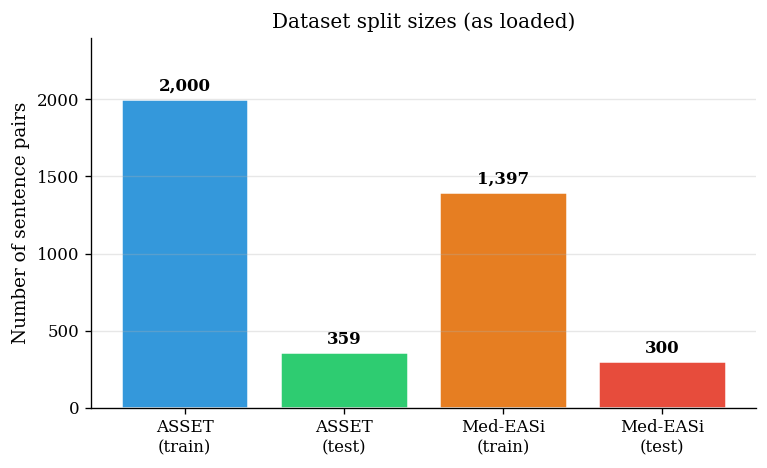

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_dataset_sizes.png


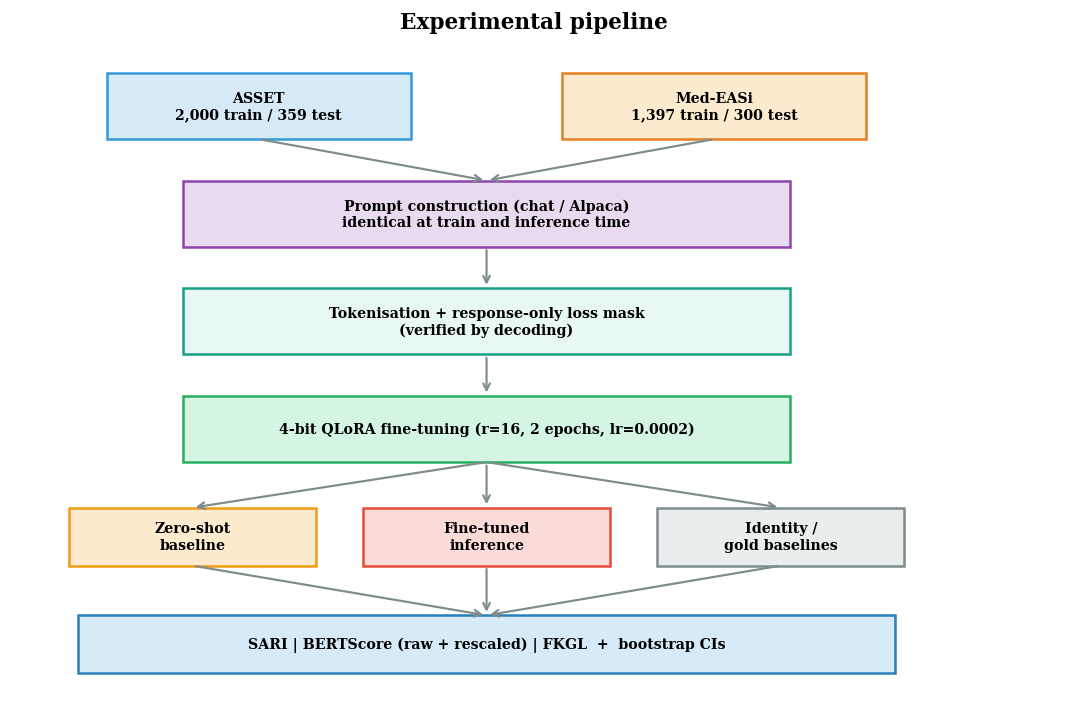

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_methodology_flowchart.png


In [36]:
# ============================================================
# SECTION 16b - FIG 1: DATASET SIZES  |  FIG 2: PIPELINE FLOWCHART
# ============================================================
# Sizes are read from DATASET_STATS, so the figure cannot disagree with what was trained
# on (V1 hardcoded 1,596 for a split that actually holds 1,397).

fig, ax = plt.subplots(figsize=(6.5, 4))
labels, sizes, colours = [], [], []
for ds_name, colour_pair in [("asset", ("#3498db", "#2ecc71")),
                             ("medeasi", ("#e67e22", "#e74c3c"))]:
    st = DATASET_STATS[ds_name]
    nice = "ASSET" if ds_name == "asset" else "Med-EASi"
    labels += [f"{nice}\n(train)", f"{nice}\n(test)"]
    sizes += [st["train_size"], st["test_size"]]
    colours += list(colour_pair)

bars = ax.bar(labels, sizes, color=colours, edgecolor="white", linewidth=1.5)
for b, s in zip(bars, sizes):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max(sizes) * 0.015, f"{s:,}",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of sentence pairs")
ax.set_title("Dataset split sizes (as loaded)")
ax.set_ylim(0, max(sizes) * 1.2)
ax.grid(axis="y", alpha=0.3)
_despine(ax)
plt.tight_layout()
savefig("fig_dataset_sizes.png")


fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 8)
ax.axis("off")


def draw_box(x, y, w, h, text, fc, ec):
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, linewidth=1.5,
                               edgecolor=ec, facecolor=fc, zorder=3))
    ax.text(x, y, text, ha="center", va="center", fontsize=8.5, fontweight="bold", zorder=4)


a_st, m_st = DATASET_STATS["asset"], DATASET_STATS["medeasi"]
draw_box(2.6, 7.1, 3.2, 0.8, f"ASSET\n{a_st['train_size']:,} train / {a_st['test_size']} test",
         "#d6eaf8", "#3498db")
draw_box(7.4, 7.1, 3.2, 0.8, f"Med-EASi\n{m_st['train_size']:,} train / {m_st['test_size']} test",
         "#fdebd0", "#e67e22")
draw_box(5.0, 5.8, 6.4, 0.8, "Prompt construction (chat / Alpaca)\nidentical at train and inference time",
         "#e8daef", "#8e44ad")
draw_box(5.0, 4.5, 6.4, 0.8, "Tokenisation + response-only loss mask\n(verified by decoding)",
         "#e8f8f5", "#16a085")
draw_box(5.0, 3.2, 6.4, 0.8, f"4-bit QLoRA fine-tuning (r={LORA_R}, "
                             f"{NUM_EPOCHS} epochs, lr={LR:g})", "#d5f5e3", "#27ae60")
draw_box(1.9, 1.9, 2.6, 0.7, "Zero-shot\nbaseline", "#fdebd0", "#f39c12")
draw_box(5.0, 1.9, 2.6, 0.7, "Fine-tuned\ninference", "#fadbd8", "#e74c3c")
draw_box(8.1, 1.9, 2.6, 0.7, "Identity /\ngold baselines", "#eaeded", "#7f8c8d")
draw_box(5.0, 0.6, 8.6, 0.7, "SARI | BERTScore (raw + rescaled) | FKGL  +  bootstrap CIs",
         "#d6eaf8", "#2980b9")

for x0, y0, x1, y1 in [(2.6, 6.7, 5.0, 6.2), (7.4, 6.7, 5.0, 6.2),
                       (5.0, 5.4, 5.0, 4.9), (5.0, 4.1, 5.0, 3.6),
                       (5.0, 2.8, 1.9, 2.25), (5.0, 2.8, 5.0, 2.25), (5.0, 2.8, 8.1, 2.25),
                       (1.9, 1.55, 5.0, 0.95), (5.0, 1.55, 5.0, 0.95), (8.1, 1.55, 5.0, 0.95)]:
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="#7f8c8d", lw=1.3))

ax.set_title("Experimental pipeline", fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
savefig("fig_methodology_flowchart.png")

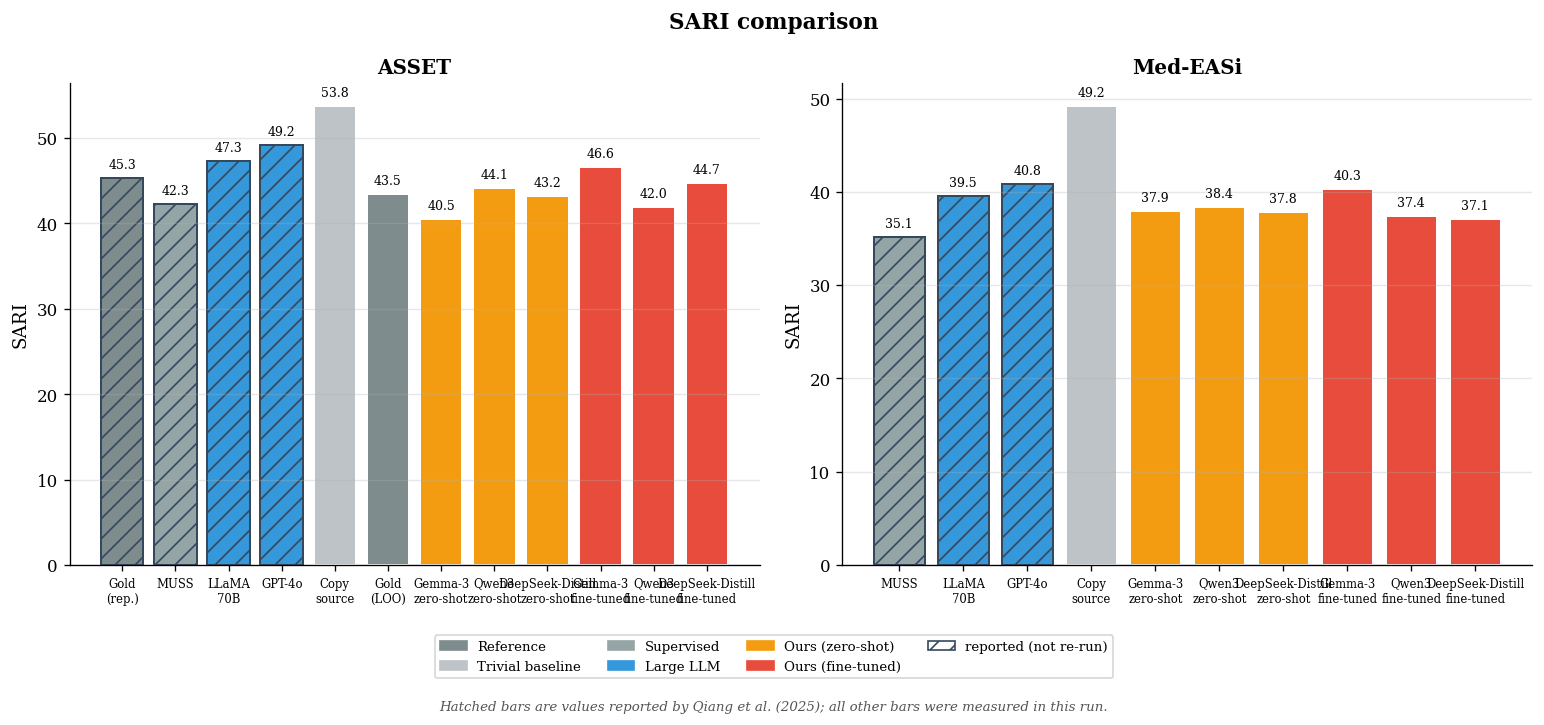

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_sari_comparison.png


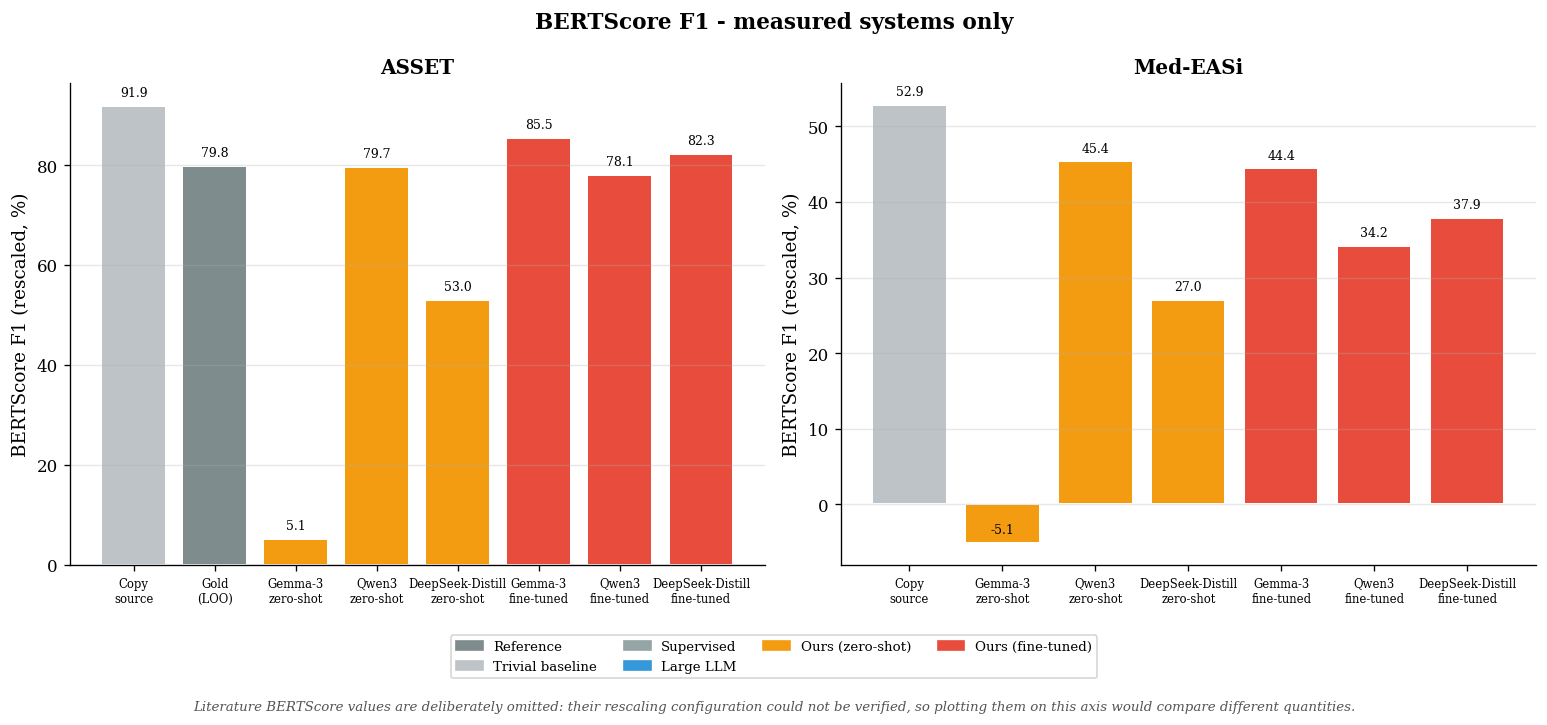

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_bertscore_comparison.png


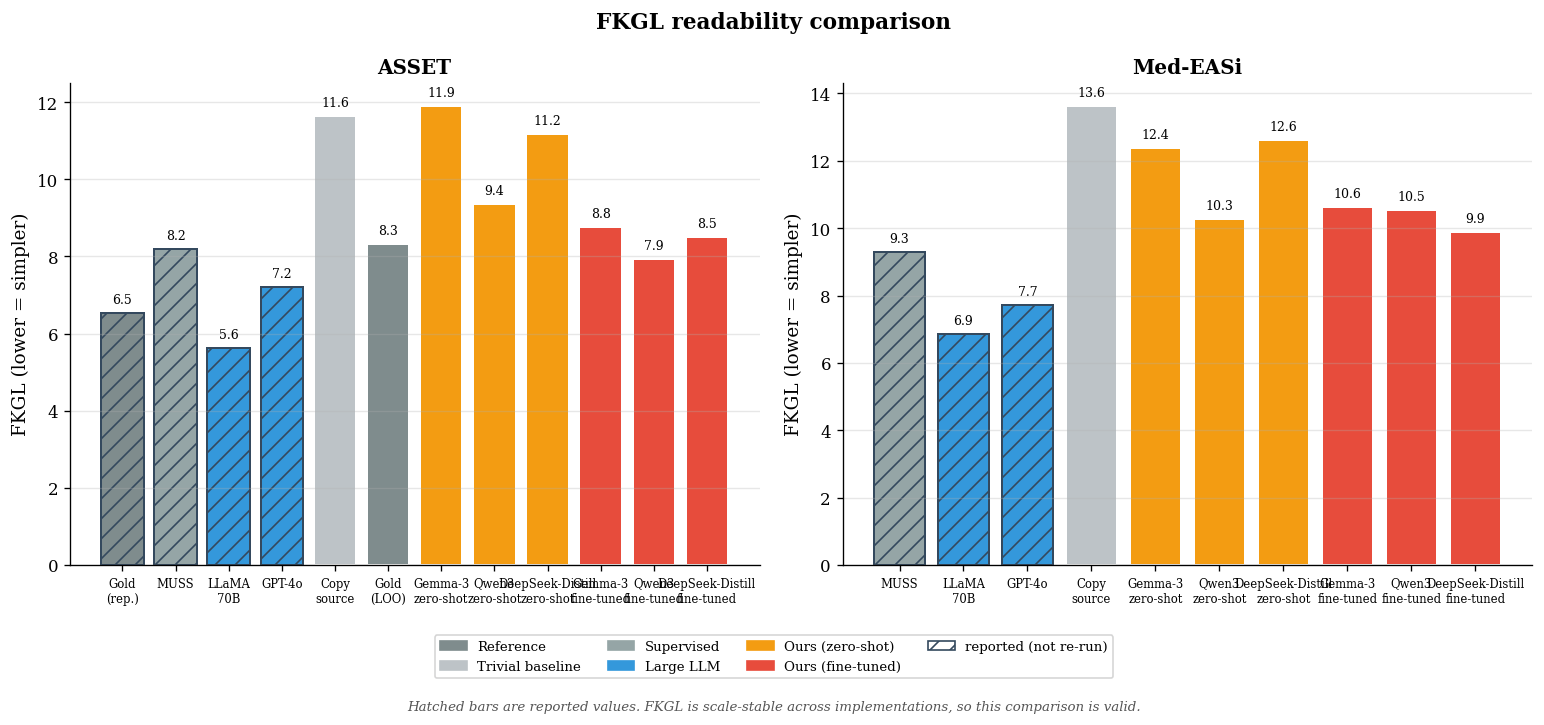

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_fkgl_comparison.png


In [37]:
# ============================================================
# SECTION 16c - FIG 3-5: METRIC COMPARISONS
# ============================================================

def metric_figure(metric_col, ylabel, title, fname, include_literature, note=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    for ax, ds_name in zip(axes, DATASET_NAMES):
        entries = []
        if include_literature:
            for b in LITERATURE_BASELINES[ds_name]:
                entries.append((b["display"], b[metric_col], b["group"], True))

        sub = metrics_df[metrics_df["dataset"] == ds_name]
        col = {"sari": "sari", "fkgl": "fkgl",
               "bertscore": "bertscore_rescaled" if RESCALING_AVAILABLE else "bertscore_raw"}[metric_col]
        order = ["identity"] + (["gold_loo"] if GOLD_AVAILABLE[ds_name] else []) \
                + [f"zeroshot_{m}" for m in MODEL_NAMES] + [f"ft_{m}" for m in MODEL_NAMES]
        group_of = {"identity": "Trivial baseline", "gold_loo": "Reference"}
        for m in MODEL_NAMES:
            group_of[f"zeroshot_{m}"] = "Ours (zero-shot)"
            group_of[f"ft_{m}"] = "Ours (fine-tuned)"

        for system in order:
            r = sub[sub["system"] == system]
            if r.empty:
                continue
            entries.append((r.iloc[0]["display"], float(r.iloc[0][col]), group_of[system], False))

        labels = [SHORT_LABEL.get(d, d) for d, _, _, _ in entries]
        values = [v for _, v, _, _ in entries]
        colours = [GROUP_COLOURS.get(g, "#bdc3c7") for _, _, g, _ in entries]
        hatches = ["//" if rep else "" for _, _, _, rep in entries]

        bars = ax.bar(labels, values, color=colours, edgecolor="white", linewidth=1.2)
        for b, h in zip(bars, hatches):
            if h:
                b.set_hatch(h)
                b.set_edgecolor("#34495e")
        span = max(values) - min(0, min(values))
        for b, v in zip(bars, values):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + span * 0.015,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)

        ax.set_title("ASSET" if ds_name == "asset" else "Med-EASi", fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)
        _despine(ax)
        plt.setp(ax.get_xticklabels(), fontsize=7, rotation=0)

    handles = [mpatches.Patch(color=v, label=k) for k, v in GROUP_COLOURS.items()]
    if include_literature:
        handles.append(mpatches.Patch(facecolor="white", edgecolor="#34495e", hatch="//",
                                      label="reported (not re-run)"))
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.10))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    if note:
        fig.text(0.5, -0.14, note, ha="center", fontsize=8, style="italic", color="#555")
    plt.tight_layout()
    savefig(fname)


metric_figure("sari", "SARI", "SARI comparison", "fig_sari_comparison.png",
              include_literature=True,
              note="Hatched bars are values reported by Qiang et al. (2025); all other bars were "
                   "measured in this run.")

metric_figure("bertscore",
              f"BERTScore F1 ({'rescaled' if RESCALING_AVAILABLE else 'raw'}, %)",
              "BERTScore F1 - measured systems only", "fig_bertscore_comparison.png",
              include_literature=False,
              note="Literature BERTScore values are deliberately omitted: their rescaling "
                   "configuration could not be verified, so plotting them on this axis would "
                   "compare different quantities.")

metric_figure("fkgl", "FKGL (lower = simpler)", "FKGL readability comparison",
              "fig_fkgl_comparison.png", include_literature=True,
              note="Hatched bars are reported values. FKGL is scale-stable across "
                   "implementations, so this comparison is valid.")

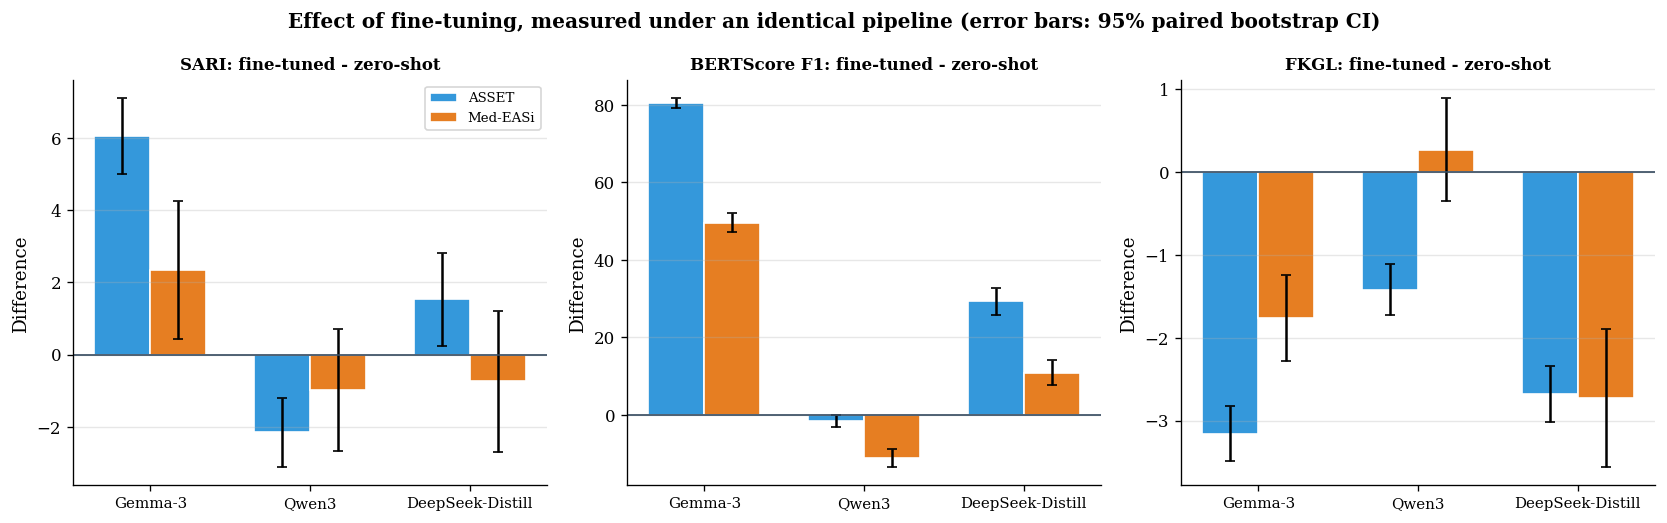

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_finetuning_effect.png


In [38]:
# ============================================================
# SECTION 16d - FIG 6: FINE-TUNING EFFECT (the controlled comparison)
# ============================================================

if not sig_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    for ax, metric, nice in zip(axes,
                                ["sari",
                                 "bertscore_rescaled" if RESCALING_AVAILABLE else "bertscore_raw",
                                 "fkgl"],
                                ["SARI", "BERTScore F1", "FKGL"]):
        sub = sig_df[sig_df["metric"] == metric]
        if sub.empty:
            ax.axis("off")
            continue
        x = np.arange(len(MODEL_NAMES))
        w = 0.35
        for offset, ds_name, colour in [(-w / 2, "asset", "#3498db"), (w / 2, "medeasi", "#e67e22")]:
            vals, errs = [], []
            for m in MODEL_NAMES:
                r = sub[(sub["dataset"] == ds_name) & (sub["model"] == MODEL_DISPLAY[m])]
                if r.empty:
                    vals.append(0.0)
                    errs.append(0.0)
                    continue
                r = r.iloc[0]
                lo, hi = [float(v) for v in r["ci95_of_difference"].strip("[]").split(",")]
                vals.append(r["difference"])
                errs.append(max(hi - r["difference"], r["difference"] - lo))
            ax.bar(x + offset, vals, w, yerr=errs, capsize=3, color=colour,
                   edgecolor="white", label="ASSET" if ds_name == "asset" else "Med-EASi")
        ax.axhline(0, color="#34495e", lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_DISPLAY[m].split()[0] for m in MODEL_NAMES], fontsize=9)
        ax.set_title(f"{nice}: fine-tuned - zero-shot", fontweight="bold", fontsize=10)
        ax.set_ylabel("Difference")
        ax.grid(axis="y", alpha=0.3)
        _despine(ax)
    axes[0].legend(fontsize=8)
    fig.suptitle("Effect of fine-tuning, measured under an identical pipeline "
                 "(error bars: 95% paired bootstrap CI)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    savefig("fig_finetuning_effect.png")
else:
    print("Skipped: no zero-shot predictions available.")

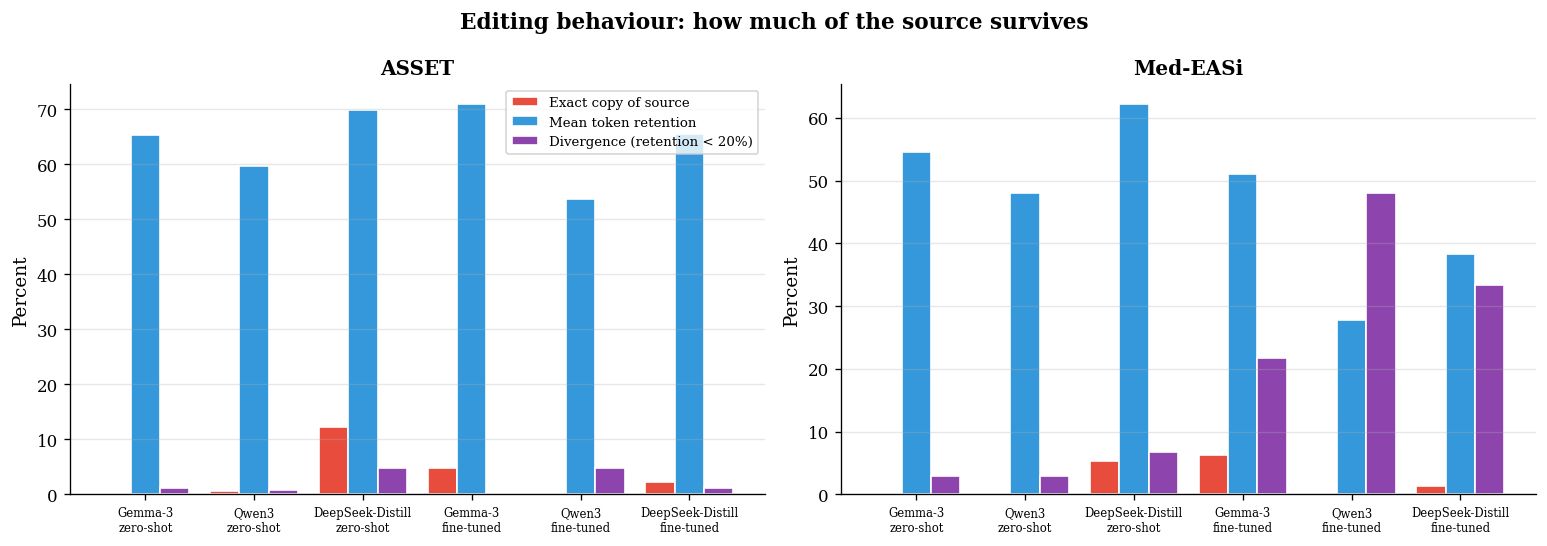

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_editing_behaviour.png


In [39]:
# ============================================================
# SECTION 16e - FIG 7: EDITING BEHAVIOUR
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, ds_name in zip(axes, DATASET_NAMES):
    sub = behaviour_df[(behaviour_df["dataset"] == ds_name) &
                       (behaviour_df["system"].str.startswith(("ft_", "zeroshot_")))]
    labels = [SHORT_LABEL.get(d, d) for d in sub["display"]]
    x = np.arange(len(sub))
    w = 0.27
    ax.bar(x - w, sub["exact_copy_rate_pct"], w, label="Exact copy of source",
           color="#e74c3c", edgecolor="white")
    ax.bar(x, sub["mean_token_retention_pct"], w, label="Mean token retention",
           color="#3498db", edgecolor="white")
    ax.bar(x + w, sub["divergence_rate_pct"], w, label="Divergence (retention < 20%)",
           color="#8e44ad", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel("Percent")
    ax.set_title("ASSET" if ds_name == "asset" else "Med-EASi", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    _despine(ax)
axes[0].legend(fontsize=8)
fig.suptitle("Editing behaviour: how much of the source survives", fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("fig_editing_behaviour.png")

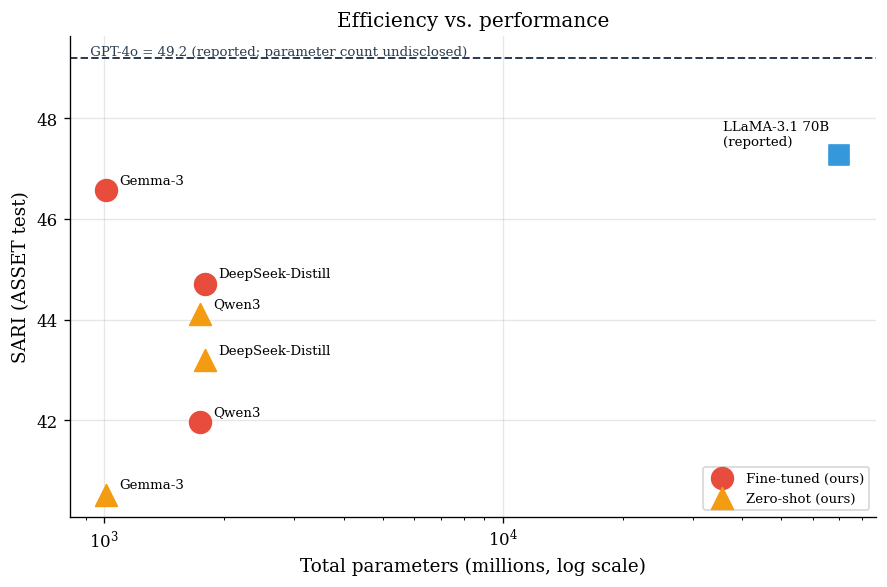

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_efficiency_tradeoff.png


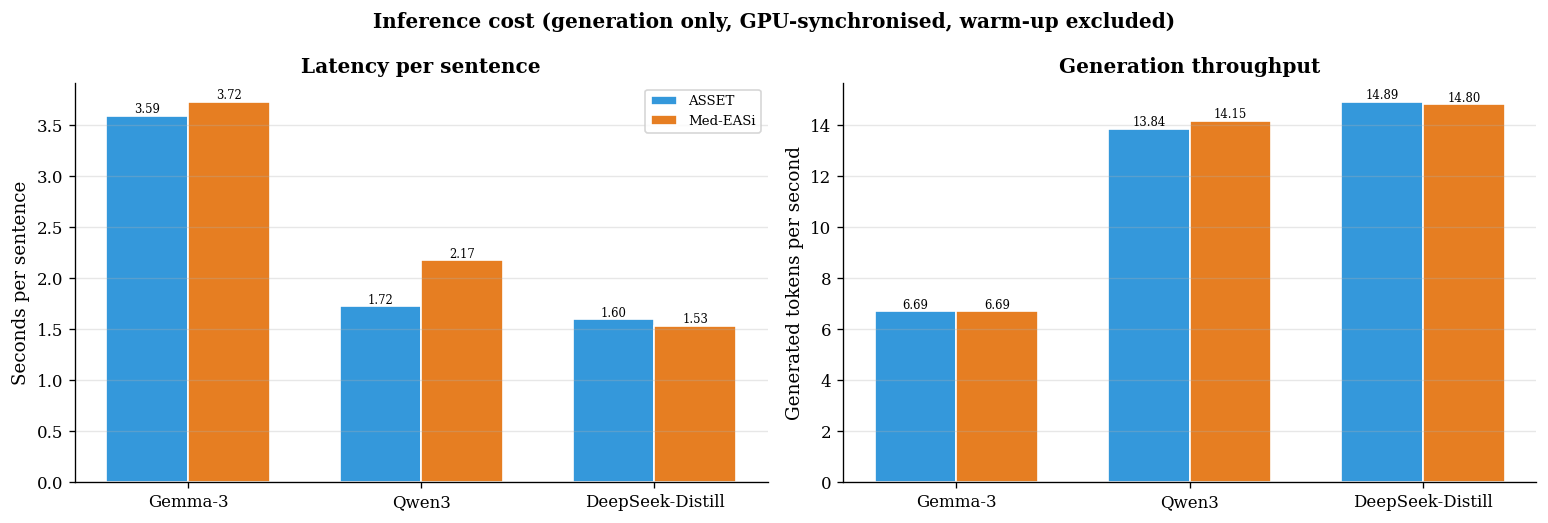

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_latency_comparison.png


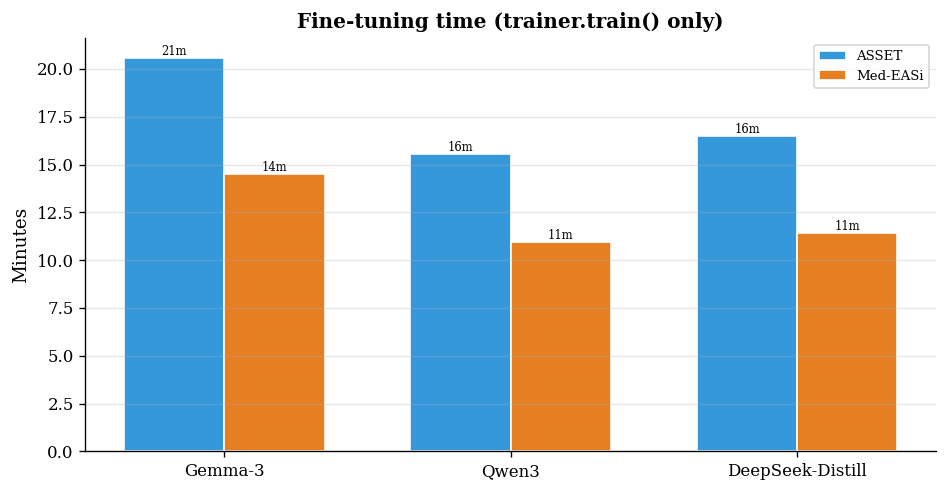

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_training_time_comparison.png


In [40]:
# ============================================================
# SECTION 16f - FIG 8-10: EFFICIENCY
# ============================================================

# --- Parameters vs SARI (ASSET). GPT-4o is shown as a reference line, not a point:
#     its parameter count has never been published, so V1's 1.8e6 M x-coordinate was
#     an invented number inside a published figure.
fig, ax = plt.subplots(figsize=(7.5, 5))
asset_metrics = metrics_df[metrics_df["dataset"] == "asset"]

for label, prefix, colour, marker in [("Fine-tuned (ours)", "ft_", "#e74c3c", "o"),
                                      ("Zero-shot (ours)", "zeroshot_", "#f39c12", "^")]:
    xs, ys, names = [], [], []
    for m in MODEL_NAMES:
        r = asset_metrics[asset_metrics["system"] == f"{prefix}{m}"]
        ts = ALL_TRAIN_STATS.get(f"{m}_asset", {})
        if r.empty or not ts.get("total_params"):
            continue
        xs.append(ts["total_params"] / 1e6)
        ys.append(float(r.iloc[0]["sari"]))
        names.append(MODEL_DISPLAY[m].split()[0])
    ax.scatter(xs, ys, s=170, color=colour, marker=marker, zorder=5, label=label)
    for x, y, n in zip(xs, ys, names):
        ax.annotate(n, (x, y), textcoords="offset points", xytext=(8, 4), fontsize=8)

llama = next(b for b in LITERATURE_BASELINES["asset"] if b["display"] == "LLaMA-3.1 70B")
ax.scatter([70000], [llama["sari"]], s=150, marker="s", color="#3498db", zorder=4)
ax.annotate("LLaMA-3.1 70B\n(reported)", (70000, llama["sari"]),
            textcoords="offset points", xytext=(-70, 6), fontsize=8)

gpt4o = next(b for b in LITERATURE_BASELINES["asset"] if b["display"] == "GPT-4o")
ax.axhline(gpt4o["sari"], color="#2c3e50", ls="--", lw=1.2)
ax.text(0.02, gpt4o["sari"], f" GPT-4o = {gpt4o['sari']} (reported; parameter count undisclosed)",
        transform=ax.get_yaxis_transform(), va="bottom", fontsize=8, color="#2c3e50")

ax.set_xscale("log")
ax.set_xlabel("Total parameters (millions, log scale)")
ax.set_ylabel("SARI (ASSET test)")
ax.set_title("Efficiency vs. performance")
ax.grid(alpha=0.3)
_despine(ax)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
savefig("fig_efficiency_tradeoff.png")


# --- Latency: per sentence and per generated token ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(MODEL_NAMES))
w = 0.35
for ax, (col, ylabel, title) in zip(axes, [
        ("ft_latency_s", "Seconds per sentence", "Latency per sentence"),
        ("ft_tokens_per_s", "Generated tokens per second", "Generation throughput")]):
    for offset, ds_name, colour in [(-w / 2, "ASSET", "#3498db"), (w / 2, "MEDEASI", "#e67e22")]:
        vals = []
        for m in MODEL_NAMES:
            r = eff_df[(eff_df["model"] == MODEL_DISPLAY[m]) & (eff_df["dataset"] == ds_name)]
            vals.append(float(r.iloc[0][col]) if not r.empty and pd.notna(r.iloc[0][col]) else 0.0)
        bars = ax.bar(x + offset, vals, w, color=colour, edgecolor="white",
                      label="ASSET" if ds_name == "ASSET" else "Med-EASi")
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.2f}",
                    ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY[m].split()[0] for m in MODEL_NAMES])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    _despine(ax)
axes[0].legend(fontsize=8)
fig.suptitle("Inference cost (generation only, GPU-synchronised, warm-up excluded)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
savefig("fig_latency_comparison.png")


# --- Pure training time ---
fig, ax = plt.subplots(figsize=(8, 4.2))
for offset, ds_name, colour in [(-w / 2, "asset", "#3498db"), (w / 2, "medeasi", "#e67e22")]:
    vals = [ALL_TRAIN_STATS.get(f"{m}_{ds_name}", {}).get("pure_train_time_min", 0) or 0
            for m in MODEL_NAMES]
    bars = ax.bar(x + offset, vals, w, color=colour, edgecolor="white",
                  label="ASSET" if ds_name == "asset" else "Med-EASi")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.0f}m",
                ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY[m].split()[0] for m in MODEL_NAMES])
ax.set_ylabel("Minutes")
ax.set_title("Fine-tuning time (trainer.train() only)", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
_despine(ax)
plt.tight_layout()
savefig("fig_training_time_comparison.png")

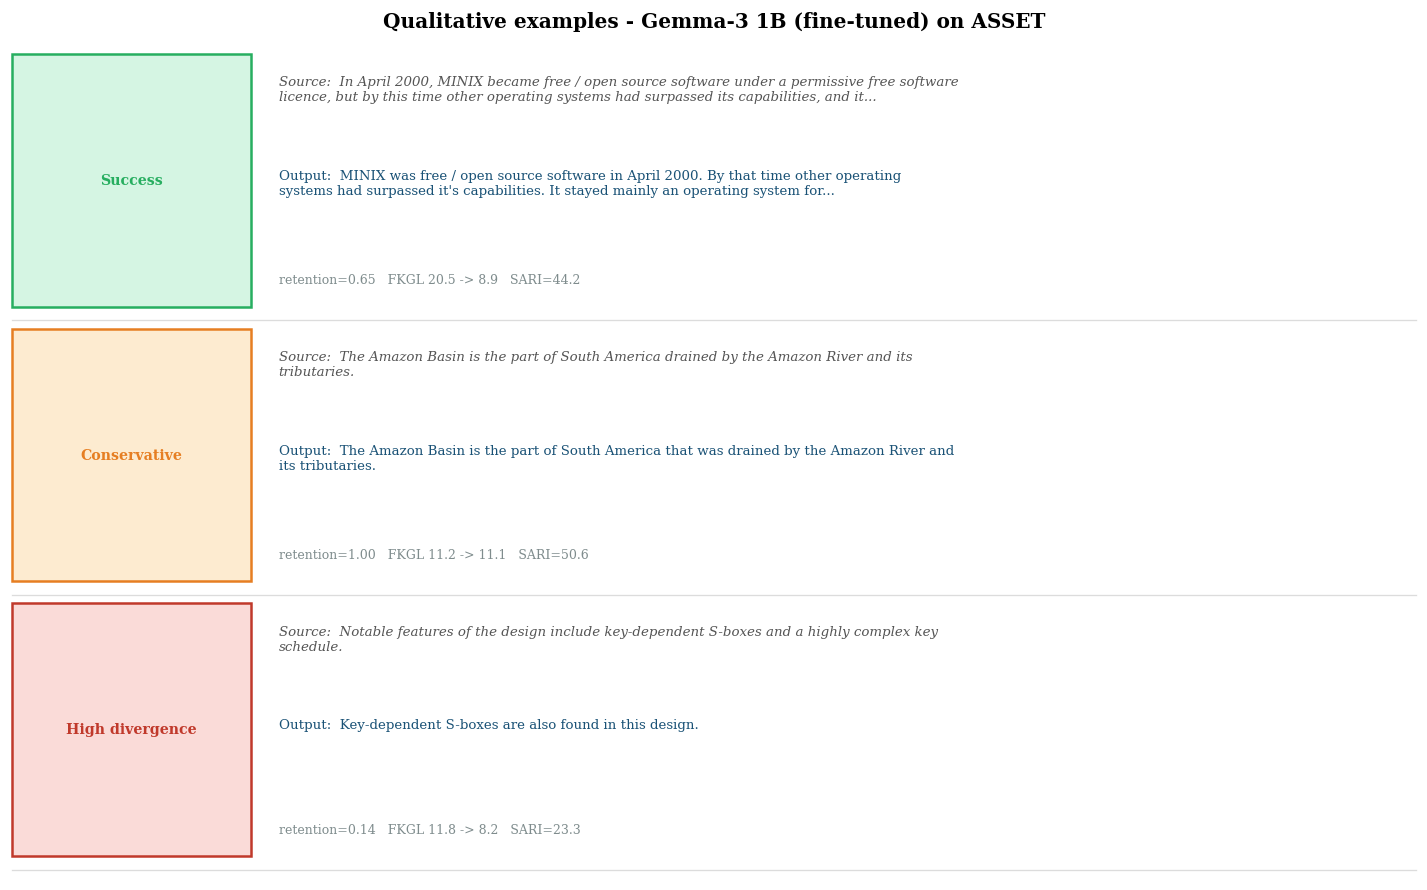

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_qualitative_examples_asset.png


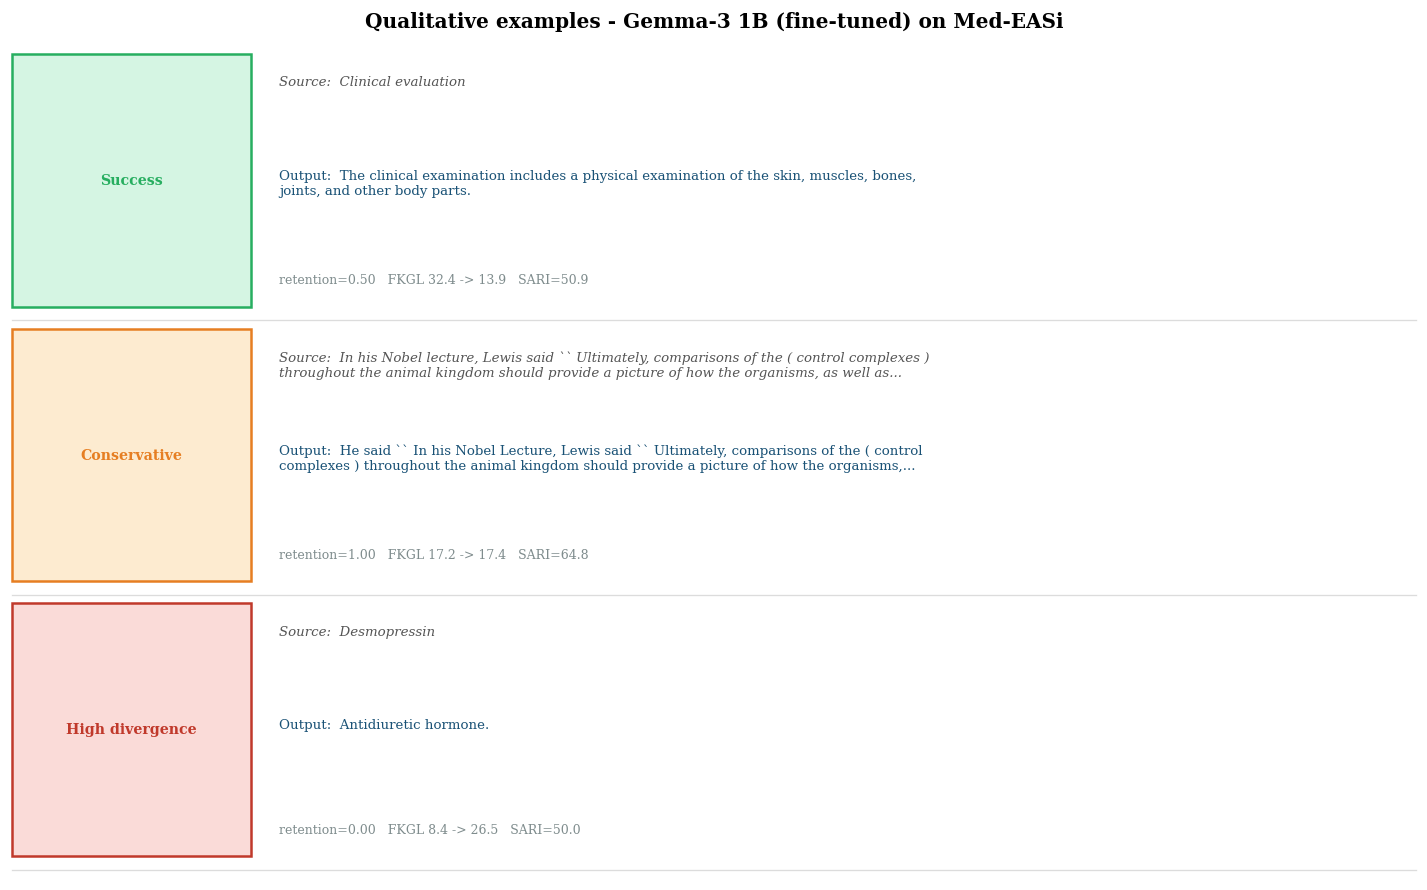

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/figures/fig_qualitative_examples_medeasi.png


In [41]:
# ============================================================
# SECTION 16g - FIG 11: QUALITATIVE EXAMPLES
# ============================================================
# Categories come from the corrected selectors in Section 13, and the divergence case is
# shown alongside the flattering ones rather than being filtered out.

CATEGORY_STYLE = {
    "Success (large readability gain)": ("#d5f5e3", "#27ae60"),
    "Conservative (minimal edit)": ("#fdebd0", "#e67e22"),
    "High divergence (information loss risk)": ("#fadbd8", "#c0392b"),
}


def wrap(text, width=88):
    words, lines, cur = str(text).split(), [], ""
    for word in words:
        if len(cur) + len(word) + 1 > width:
            lines.append(cur)
            cur = word
        else:
            cur = f"{cur} {word}".strip()
    if cur:
        lines.append(cur)
    return "\n".join(lines[:2]) + ("..." if len(lines) > 2 else "")


for ds_name in DATASET_NAMES:
    picks = []
    for cat in CATEGORY_STYLE:
        sub = qual_df[(qual_df["dataset"] == ds_name) & (qual_df["category"] == cat)]
        if not sub.empty:
            picks.append((cat, sub.iloc[0]))
    if not picks:
        continue

    fig, ax = plt.subplots(figsize=(12, 2.5 * len(picks)))
    ax.axis("off")
    y = 1.0
    step = 1.0 / len(picks)

    for cat, e in picks:
        fc, ec = CATEGORY_STYLE[cat]
        ax.add_patch(plt.Rectangle((0.0, y - step * 0.92), 0.17, step * 0.92,
                                   transform=ax.transAxes, linewidth=1.5,
                                   edgecolor=ec, facecolor=fc, clip_on=False))
        ax.text(0.085, y - step * 0.46, cat.split(" (")[0], transform=ax.transAxes,
                ha="center", va="center", fontsize=8.5, fontweight="bold", color=ec)
        ax.text(0.19, y - step * 0.08, f"Source:  {wrap(e['source'])}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                style="italic", color="#555")
        ax.text(0.19, y - step * 0.42, f"Output:  {wrap(e['prediction'])}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#1a5276")
        ax.text(0.19, y - step * 0.80,
                f"retention={e['token_retention']:.2f}   "
                f"FKGL {e['fkgl_source']:.1f} -> {e['fkgl_prediction']:.1f}   "
                f"SARI={e['sari']:.1f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=7.5, color="#7f8c8d")
        ax.plot([0, 1], [y - step * 0.97] * 2, color="#dcdcdc", lw=0.8,
                transform=ax.transAxes, clip_on=False)
        y -= step

    nice = "ASSET" if ds_name == "asset" else "Med-EASi"
    ax.set_title(f"Qualitative examples - {SYSTEM_DISPLAY[BEST_MODEL[ds_name]]} on {nice}",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    savefig(f"fig_qualitative_examples_{ds_name}.png")

## Section 17 — Configs, requirements, and reproducibility verification

Everything the paper cites is written here from the objects that produced it, and the
checklist reads the same path constants the rest of the notebook wrote to — so a
`[MISSING]` here is a real failure, not the path mismatch V1 reported.

In [42]:
# ============================================================
# SECTION 17a - SAVE CONFIGS (all values read from the run, none hardcoded)
# ============================================================

EXPERIMENT_CONFIG = {
    "title": "Scaling Down Simplicity: Evaluating Lightweight Language Models for "
             "Sentence Simplification",
    "notebook_version": "v2",
    "seed": SEED,
    "smoke_test": SMOKE_TEST,
    "datasets": {
        ds: {
            "hf_id": DATASET_STATS[ds]["hf_id"],
            "hf_config": DATASET_STATS[ds]["hf_config"],
            "train_split": DATASET_STATS[ds]["train_split"],
            "test_split": DATASET_STATS[ds]["test_split"],
            "train_size": DATASET_STATS[ds]["train_size"],
            "test_size": DATASET_STATS[ds]["test_size"],
            "n_evaluated": len(EVAL_DATA[ds]["sources"]),
            "references_per_test_source_max": DATASET_STATS[ds]["references_per_test_source_max"],
        }
        for ds in DATASET_NAMES
    },
    "models": {
        m: {
            "hf_model": MODEL_CONFIGS[m]["hf_model"],
            "loaded_checkpoint": (MODEL_CONFIGS[m]["unsloth_model"] if UNSLOTH_AVAILABLE
                                  else MODEL_CONFIGS[m]["hf_model"]),
            "template": MODEL_CONFIGS[m]["template"],
            "eos_token": ALL_TRAIN_STATS.get(f"{m}_asset", {}).get("eos_token"),
            "total_params": ALL_TRAIN_STATS.get(f"{m}_asset", {}).get("total_params"),
            "trainable_params": ALL_TRAIN_STATS.get(f"{m}_asset", {}).get("trainable_params"),
            "trainable_pct": ALL_TRAIN_STATS.get(f"{m}_asset", {}).get("trainable_pct"),
        }
        for m in MODEL_NAMES
    },
    "systems_evaluated": {ds: SYSTEMS[ds] for ds in DATASET_NAMES},
    "metrics": {
        "sari": "HuggingFace evaluate 'sari', all available references",
        "bertscore_raw": f"bert-score {bert_score.__version__}, {BERTSCORE_MODEL}, "
                         f"layer {BERTSCORE_LAYERS}, multi-reference (max), NO baseline rescaling",
        "bertscore_rescaled": (f"same, rescale_with_baseline=True" if RESCALING_AVAILABLE
                               else "unavailable in this environment"),
        "bertscore_singleref_raw": "raw, first reference only - kept for continuity with V1",
        "fkgl": f"textstat {textstat.__version__} flesch_kincaid_grade, mean over sentences",
    },
    "literature_baselines": LITERATURE_CITATION,
    "framework": "Unsloth + HF Trainer" if UNSLOTH_AVAILABLE else "HF PEFT + HF Trainer",
    "environment": ENVIRONMENT,
}

TRAINING_CONFIG = {
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "target_modules": TARGET_MODULES,
    "max_seq_length": MAX_SEQ_LEN,
    "num_epochs": NUM_EPOCHS,
    "max_steps": MAX_TRAIN_STEPS,
    "learning_rate": LR,
    "per_device_train_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
    "optimizer": OPTIMIZER,
    "lr_scheduler": LR_SCHEDULER,
    "warmup_ratio": WARMUP_RATIO,
    "quantization": "4-bit NF4 (bitsandbytes), double quantisation",
    "response_only_loss": True,
    "response_only_verified": all(v.get("masking_verified", False)
                                  for v in ALL_TRAIN_STATS.values()),
    "asset_train_reference_strategy": ASSET_TRAIN_REF_STRATEGY,
    "asset_train_reference_index": ASSET_TRAIN_REF_INDEX,
    "enable_thinking": ENABLE_THINKING,
    "add_special_tokens": ADD_SPECIAL_TOKENS,
    "inference": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": DO_SAMPLE,
        "decoding": "greedy",
        "repetition_penalty": REPETITION_PENALTY,
        "use_cache": True,
        "batch_size": 1,
    },
}

save_json(EXPERIMENT_CONFIG, F_EXPERIMENT_CFG)
save_json(TRAINING_CONFIG, F_TRAINING_CFG)

# Recorded so the reproducibility statement can say exactly how the run was checkpointed
# and whether any part of it was resumed - a reviewer asking "was this one clean run?"
# gets a documented answer instead of an assurance.
save_json({
    "checkpoint_save_steps": CHECKPOINT_SAVE_STEPS,
    "checkpoint_keep": CHECKPOINT_KEEP,
    "partial_flush_every": PARTIAL_FLUSH_EVERY,
    "atomic_writes": True,
    "bertscore_rescale_derived": BERTSCORE_RESCALE_DERIVED,
    "bertscore_rescale_check": BERTSCORE_RESCALE_CHECK,
    "adapter_reuse_report": ADAPTER_REUSE_REPORT,
    "retrained_this_run": sorted(RETRAINED_KEYS),
    "resumed_inference": {k: v.get("n_resumed_from_previous_session", 0)
                          for k, v in ALL_INFER_STATS.items()
                          if v.get("n_resumed_from_previous_session")},
}, os.path.join(CONFIG_DIR, "run_provenance.json"))
print(f"saved -> {os.path.join(CONFIG_DIR, 'run_provenance.json')}")

REQUIREMENTS = f"""# Generated from the environment that produced these results
# {ENVIRONMENT['timestamp_utc']} | python {ENVIRONMENT['python']} | GPU: {ENVIRONMENT['gpu']}
torch=={ENVIRONMENT['torch']}
transformers=={ENVIRONMENT['transformers']}
datasets=={ENVIRONMENT['datasets']}
peft=={ENVIRONMENT['peft']}
bitsandbytes
accelerate
sentencepiece
protobuf
evaluate=={ENVIRONMENT['evaluate']}
bert-score=={ENVIRONMENT['bert_score']}
textstat=={ENVIRONMENT['textstat']}
sacrebleu
sacremoses
pandas=={ENVIRONMENT['pandas']}
numpy=={ENVIRONMENT['numpy']}
matplotlib=={ENVIRONMENT['matplotlib']}
"""
if UNSLOTH_AVAILABLE:
    REQUIREMENTS += f"unsloth=={ENVIRONMENT['unsloth']}\n"

save_text(REQUIREMENTS, F_REQUIREMENTS)

print(f"saved -> {F_EXPERIMENT_CFG}")
print(f"saved -> {F_TRAINING_CFG}")
print(f"saved -> {F_REQUIREMENTS}")

saved -> /content/drive/MyDrive/sentence_simplification_fix_final/configs/run_provenance.json
saved -> /content/drive/MyDrive/sentence_simplification_fix_final/configs/experiment_config.json
saved -> /content/drive/MyDrive/sentence_simplification_fix_final/configs/training_config.json
saved -> /content/drive/MyDrive/sentence_simplification_fix_final/requirements.txt


In [43]:
# ============================================================
# SECTION 17b - OUTPUT VERIFICATION
# ============================================================

expected = OrderedDict()

expected["Adapters"] = [os.path.join(MODELS_DIR, f"{m}_{d}", fn)
                        for m in MODEL_NAMES for d in DATASET_NAMES
                        for fn in ("adapter_config.json", "adapter_model.safetensors",
                                   "training_stats.json")]
expected["Predictions"] = (
    [os.path.join(PRED_DIR, f"{d}_predictions.csv") for d in DATASET_NAMES] +
    [prediction_path(f"ft_{m}", d) for m in MODEL_NAMES for d in DATASET_NAMES] +
    ([prediction_path(f"zeroshot_{m}", d) for m in MODEL_NAMES for d in DATASET_NAMES]
     if RUN_ZEROSHOT_BASELINE else [])
)
expected["Metrics"] = [
    os.path.join(METRIC_DIR, "metrics_all_systems.csv"),
    os.path.join(METRIC_DIR, "bootstrap_confidence_intervals.csv"),
    os.path.join(METRIC_DIR, "editing_behaviour.csv"),
    os.path.join(METRIC_DIR, "efficiency_metrics.csv"),
    os.path.join(METRIC_DIR, "qualitative_examples.csv"),
] + [os.path.join(METRIC_DIR, f"per_sentence_scores_{d}.csv") for d in DATASET_NAMES]
if RUN_ZEROSHOT_BASELINE:
    expected["Metrics"].append(os.path.join(METRIC_DIR, "significance_ft_vs_zeroshot.csv"))

expected["Tables"] = ([os.path.join(TABLE_DIR, f"table_{d}.csv") for d in DATASET_NAMES] +
                      [os.path.join(TABLE_DIR, f"table_{d}.tex") for d in DATASET_NAMES] +
                      [os.path.join(TABLE_DIR, "table_efficiency.tex"),
                       os.path.join(TABLE_DIR, "table_editing_behaviour.tex")])

expected["Figures"] = [os.path.join(FIG_DIR, n) for n in [
    "fig_dataset_sizes.png", "fig_methodology_flowchart.png", "fig_sari_comparison.png",
    "fig_bertscore_comparison.png", "fig_fkgl_comparison.png", "fig_editing_behaviour.png",
    "fig_efficiency_tradeoff.png", "fig_latency_comparison.png",
    "fig_training_time_comparison.png",
]] + [os.path.join(FIG_DIR, f"fig_qualitative_examples_{d}.png") for d in DATASET_NAMES]
if RUN_ZEROSHOT_BASELINE and not sig_df.empty:
    expected["Figures"].append(os.path.join(FIG_DIR, "fig_finetuning_effect.png"))

expected["Configs"] = [F_ENVIRONMENT, F_EXPERIMENT_CFG, F_TRAINING_CFG,
                       F_DATASET_STATS, F_TRAIN_STATS, F_INFER_STATS, F_REQUIREMENTS,
                       os.path.join(CONFIG_DIR, "run_provenance.json")]
expected["Metrics"].append(os.path.join(METRIC_DIR, "sari_sanity_probes.csv"))
if not leakage_df.empty:
    expected["Metrics"].append(os.path.join(METRIC_DIR, "leakage_sensitivity.csv"))
expected["Metrics"].append(os.path.join(METRIC_DIR, "decoding_artefacts.csv"))

missing_total = 0
for section, files in expected.items():
    print(f"\n[{section}]")
    for path in files:
        ok = os.path.exists(path)
        missing_total += (not ok)
        print(f"  {'[OK]     ' if ok else '[MISSING]'} {os.path.relpath(path, BASE_OUTPUT)}")

# --- Pipeline integrity -----------------------------------------------------------
# These are defects: something in the pipeline did not do its job, and every one of them
# is fixable. They gate the verdict. Properties of the RESULTS are reported separately
# below - a result that is inconvenient is not a bug, and must never be silenced by
# adjusting the check that reports it.
print("\n[Pipeline integrity]")
checks = []

for ds_name in DATASET_NAMES:
    n = len(EVAL_DATA[ds_name]["sources"])
    for system in SYSTEMS[ds_name]:
        checks.append((f"{ds_name}/{system}: prediction count == {n}",
                       len(PREDICTIONS[ds_name][system]) == n))

checks.append(("response-only masking verified on every training run",
               all(v.get("masking_verified", False) for v in ALL_TRAIN_STATS.values())))
checks.append(("dataset sizes in config match the loaded splits",
               all(EXPERIMENT_CONFIG["datasets"][d]["train_size"] == len(RAW_SPLITS[d]["train"])
                   for d in DATASET_NAMES)))
checks.append(("BERTScore baseline rescaling available", RESCALING_AVAILABLE))

# The check that would have caught the smoke-test adapters.
checks.append(("every adapter trained on the full configured split",
               all(v.get("train_examples") == expected_train_examples(k.rsplit("_", 1)[-1])
                   for k, v in ALL_TRAIN_STATS.items())))
checks.append(("no adapter carries a smoke-test flag",
               not any(v.get("smoke_test", False) for v in ALL_TRAIN_STATS.values())))
checks.append(("no training run diverged (loss stayed finite)",
               all(v.get("loss_is_finite") is not False for v in ALL_TRAIN_STATS.values())))
checks.append(("this run is not a smoke test", not SMOKE_TEST))
checks.append((f"no training run was deferred to a later session "
               f"({len(DEFERRED_TRAINING)} pending)", not DEFERRED_TRAINING))
checks.append((f"no fine-tuned system is waiting for its adapter "
               f"({len(SKIPPED_INFERENCE)} pending)", not SKIPPED_INFERENCE))

# Fine-tuned predictions must come from the adapter that is on disk right now.
_sig_ok = True
for m in MODEL_NAMES:
    for d in DATASET_NAMES:
        meta_p = _meta_path(f"ft_{m}", d)
        if not os.path.exists(meta_p):
            _sig_ok = False
            continue
        try:
            with open(meta_p, encoding="utf-8") as f:
                meta = json.load(f)
        except Exception:
            _sig_ok = False
            continue
        if (meta.get("adapter_signature") != _adapter_signature(f"ft_{m}", d)
                or meta.get("decoding_signature") != _decoding_signature()):
            _sig_ok = False
checks.append(("every fine-tuned prediction set matches the adapter now on disk", _sig_ok))

# Crash safety: no unfinished work must be left lying around claiming to be finished.
_leftover = sorted(glob.glob(os.path.join(PARTIAL_DIR, "*_partial.csv")))
checks.append((f"no unfinished inference left over ({len(_leftover)} partial file(s))",
               not _leftover))
_leftover_ckpt = sorted(glob.glob(os.path.join(MODELS_DIR, "*", "checkpoint-*")))
checks.append((f"no training checkpoints left over ({len(_leftover_ckpt)} found)",
               not _leftover_ckpt))
checks.append(("baseline-rescaled BERTScore is exact",
               (not RESCALING_AVAILABLE) or (not BERTSCORE_RESCALE_DERIVED)
               or BERTSCORE_RESCALE_CHECK.get("max_abs_diff", 1.0) < 1e-6))
checks.append(("every system has a recorded inference timing",
               all(f"{s}_{d}" in ALL_INFER_STATS
                   for d in DATASET_NAMES for s in SYSTEMS_EXPECTED_FOR_TIMING)))

for label, ok in checks:
    print(f"  {'[PASS]' if ok else '[FAIL]'} {label}")

# --- Findings ---------------------------------------------------------------------
# True statements about the results. None of them is a program error; all of them belong
# in the paper. They are printed, never counted as failures.
print("\n[Findings - report these, do not suppress them]")
findings = []

_leak = {d: DATASET_STATS[d]["train_test_source_overlap"] for d in DATASET_NAMES}
for d, n_leak in _leak.items():
    if n_leak:
        findings.append(
            f"{d}: {n_leak} test source(s) also appear in train "
            f"({100.0 * n_leak / len(RAW_SPLITS[d]['test']):.1f}% of the test split). "
            f"Report as a limitation or exclude them and say so.")

for d in DATASET_NAMES:
    ident = float(metrics_df[(metrics_df.dataset == d)
                             & (metrics_df.system == "identity")].sari.iloc[0])
    for m in MODEL_NAMES:
        r = metrics_df[(metrics_df.dataset == d) & (metrics_df.system == f"ft_{m}")]
        if not r.empty and float(r.sari.iloc[0]) <= ident:
            findings.append(
                f"{d}/{MODEL_DISPLAY[m]}: SARI {float(r.sari.iloc[0]):.2f} does not beat the "
                f"copy-source baseline ({ident:.2f}). Either the model is not simplifying, "
                f"or SARI is not measuring what the paper claims - Section 10c distinguishes "
                f"the two.")

for _k, _v in ALL_TRAIN_STATS.items():
    if _v.get("loss_decreased") is False:
        findings.append(
            f"{_k}: training loss did not fall ({_v.get('loss_first_logged')} -> "
            f"{_v.get('loss_last_logged')}). The adapter probably learned nothing - "
            f"check the learning rate before reporting its scores.")

if "artefact_df" in dir():
    for _, r in artefact_df[artefact_df["decoding_artefact"]].iterrows():
        findings.append(f"{r['dataset']}/{r['display']}: decoding artefact - {r['reason']}.")

for m in MODEL_NAMES:
    for d in DATASET_NAMES:
        row = sig_df[(sig_df.dataset == d) & (sig_df.model == MODEL_DISPLAY[m])
                     ] if not sig_df.empty else sig_df
        if not sig_df.empty and not row.empty and (row["difference"].abs() < 1e-9).all():
            findings.append(
                f"{d}/{MODEL_DISPLAY[m]}: fine-tuned and zero-shot outputs are IDENTICAL on "
                f"every metric. The adapter is having no effect - check that it trained and "
                f"that load_adapter_for_inference actually attached it.")

if findings:
    for f_ in findings:
        print(f"  [NOTE] {f_}")
else:
    print("  none")

failed = missing_total + sum(1 for _, ok in checks if not ok)
if DEFERRED_TRAINING or SKIPPED_INFERENCE:
    print("\n" + "=" * 78)
    print("THIS SESSION IS NOT THE END OF THE RUN.")
    print("Restart the runtime (Runtime > Restart session) and Run all again. Everything")
    print("already finished is detected and reused; only what is listed above is done.")
    print("=" * 78)

print("\n" + "=" * 78)
if failed == 0:
    print("ALL OUTPUTS VERIFIED - every number in the paper is regenerable from this run.")
    if findings:
        print(f"{len(findings)} finding(s) above are properties of the results, not defects.")
        print("They must be addressed in the paper's text, not in the code.")
else:
    print(f"{failed} PIPELINE DEFECT(S) - do not use these numbers until they are resolved.")
if SMOKE_TEST:
    print("\n!! SMOKE_TEST was True: these numbers are a pipeline test, not results.")
print("=" * 78)


[Adapters]
  [OK]      models/gemma3_asset/adapter_config.json
  [OK]      models/gemma3_asset/adapter_model.safetensors
  [OK]      models/gemma3_asset/training_stats.json
  [OK]      models/gemma3_medeasi/adapter_config.json
  [OK]      models/gemma3_medeasi/adapter_model.safetensors
  [OK]      models/gemma3_medeasi/training_stats.json
  [OK]      models/qwen3_asset/adapter_config.json
  [OK]      models/qwen3_asset/adapter_model.safetensors
  [OK]      models/qwen3_asset/training_stats.json
  [OK]      models/qwen3_medeasi/adapter_config.json
  [OK]      models/qwen3_medeasi/adapter_model.safetensors
  [OK]      models/qwen3_medeasi/training_stats.json
  [OK]      models/deepseek_asset/adapter_config.json
  [OK]      models/deepseek_asset/adapter_model.safetensors
  [OK]      models/deepseek_asset/training_stats.json
  [OK]      models/deepseek_medeasi/adapter_config.json
  [OK]      models/deepseek_medeasi/adapter_model.safetensors
  [OK]      models/deepseek_medeasi/training_sta

## Summary

### What this notebook guarantees

`Restart runtime` → `Run all` regenerates every table, figure and number from the
datasets and checkpoints. There is no hidden state, no hardcoded result, and no path that
is written under one name and read under another. Section 17 fails loudly if any of that
stops being true.

### Output layout

```
BASE_OUTPUT/
├── models/<model>_<dataset>/    LoRA adapter, tokenizer, training_stats.json
├── predictions/                 per-system raw CSVs + consolidated per-dataset CSVs
├── metrics/                     metrics_all_systems, per-sentence scores, bootstrap CIs,
│                                significance tests, editing behaviour, efficiency,
│                                qualitative examples
├── tables/                      paper tables as CSV and LaTeX
├── figures/                     11 publication figures at 300 dpi
├── configs/                     environment, experiment, training, dataset stats,
│                                training stats, inference stats
└── requirements.txt             pinned to the environment that produced the results
```

### Claims this run can and cannot support

**Supported.** SARI and FKGL comparisons against the literature (both metrics are
implementation-stable); fine-tuned versus zero-shot at matched settings, with paired
bootstrap tests; conservative editing behaviour, as a corpus statistic rather than an
anecdote; parameter, memory, latency and throughput costs, each measured separately.

**Not supported without the stated caveat.** BERTScore against the literature — report
our rescaled column, label theirs `reported`, and do not compute a difference between
them. Anything about GPT-4o's parameter count. Clinical safety: `divergence_rate_pct`
shows how often outputs retain almost nothing of their source, so conservatism must be
described as reduced opportunity for drift, not as a safety property.

### Before writing the results into the paper

1. Confirm `SMOKE_TEST = False` and that Section 17 printed `ALL OUTPUTS VERIFIED`.
2. Take every number from `tables/` and `metrics/` — do not retype them.
3. Update the Med-EASi training size from the run (the official train split), the
   `1.0–1.3 %` trainable-parameter figures, and the efficiency table.
4. State in the methodology that ASSET fine-tuning uses one reference per source, that
   ASSET gold is scored leave-one-out while systems see all references, and that Med-EASi
   pairs are partly paragraph-aligned.